Converting SU_WRB1_PH to categorical...
Train Performance: RMSE = 0.1323, R2 = 0.9999
Test Performance: RMSE = 0.1925, R2 = 0.9998


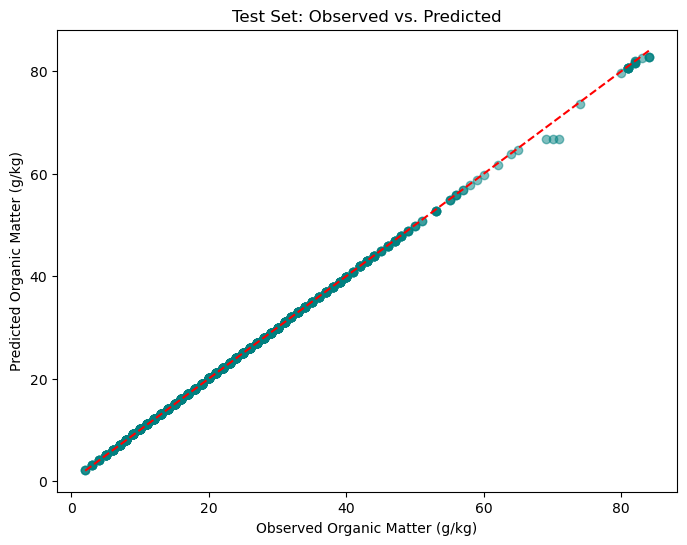

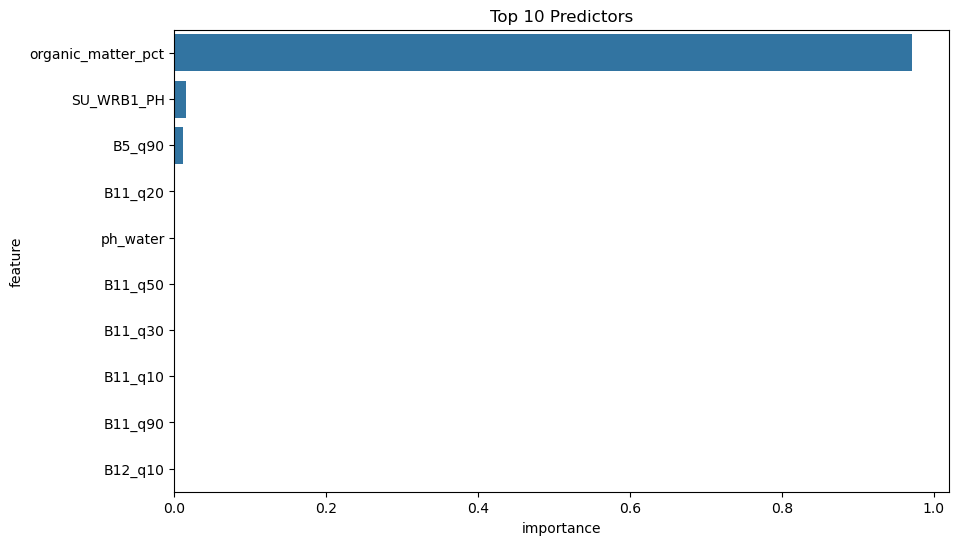

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_test.csv')
# df = df[df['organic_matter_g_kg'] < 35].copy()  # Filter out non-positive values
# df['SU_WRB1_PH'] = df['SU_WRB1_PH'].astype(str).str[:2].str.upper()
# 
# print(f"Unique Soil Groups identified: {df['SU_WRB1_PH'].unique()}")
# 2. Preprocessing
# Drop uuid and separate Target from Predictors
X = df.drop(columns=['uuid', 'organic_matter_g_kg'])
y = df['organic_matter_g_kg']
if 'SU_WRB1_PH' in X.columns:
    print("Converting SU_WRB1_PH to categorical...")
    
    X['SU_WRB1_PH'] = X['SU_WRB1_PH'].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Model Training
model = xgb.XGBRegressor(objective='reg:squarederror', 
                         n_estimators=100, 
                         learning_rate=0.05,
                         max_depth=6,
                         enable_categorical=True,
                         tree_method='hist')
model.fit(X_train, y_train)

# 4. Evaluation
def evaluate(model, X, y, label):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    print(f"{label} Performance: RMSE = {rmse:.4f}, R2 = {r2:.4f}")
    return preds

train_preds = evaluate(model, X_train, y_train, "Train")
test_preds = evaluate(model, X_test, y_test, "Test")

# 5. Observed vs Predicted Trace
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Observed Organic Matter (g/kg)')
plt.ylabel('Predicted Organic Matter (g/kg)')
plt.title('Test Set: Observed vs. Predicted')
plt.show()

# 6. Hyperparameter Exploration & Validation Curves
param_range_depth = [3, 5, 7, 9]
param_range_lr = [0.01, 0.05, 0.1, 0.2]

def plot_val_curve(param_name, param_range):
    train_scores, test_scores = validation_curve(
        xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True, tree_method='hist'), 
        X_train, y_train, param_name=param_name, 
        param_range=param_range, cv=5, scoring="r2", n_jobs=-1
    )
    
    plt.figure(figsize=(8, 5))
    plt.plot(param_range, np.mean(train_scores, axis=1), label="Training Score", marker='o')
    plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-Validation Score", marker='o')
    plt.title(f"Validation Curve: {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plotting curves for Depth and Learning Rate
# plot_val_curve("max_depth", param_range_depth)
# plot_val_curve("learning_rate", param_range_lr)
# plot_val_curve("n_estimators", [100, 200, 300, 500])

import seaborn as sns

# Get feature importance
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10))
plt.title("Top 10 Predictors")
plt.show()


TRAINING MODEL FOR: total_silt_pct
Test Performance for total_silt_pct: RMSE = 9.2063, R2 = 0.3850


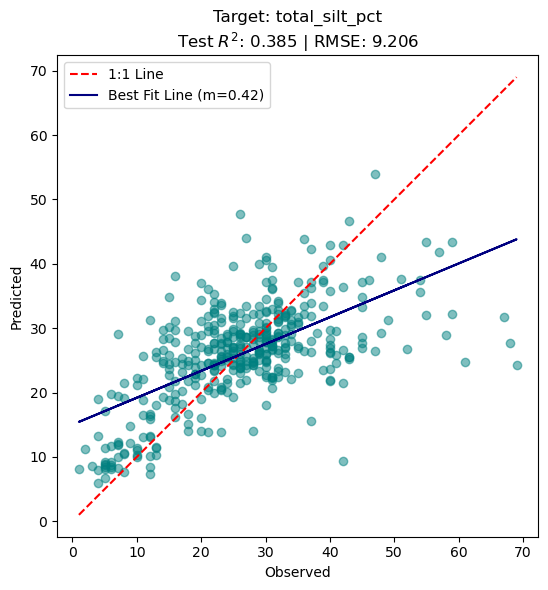

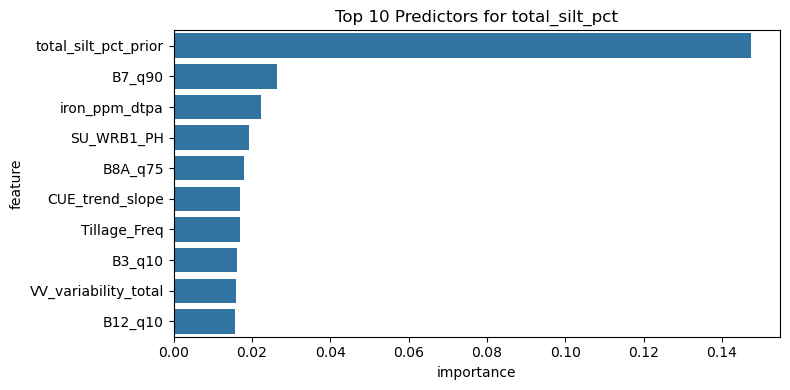


TRAINING MODEL FOR: fine_silt_pct
Test Performance for fine_silt_pct: RMSE = 8.8091, R2 = 0.3825


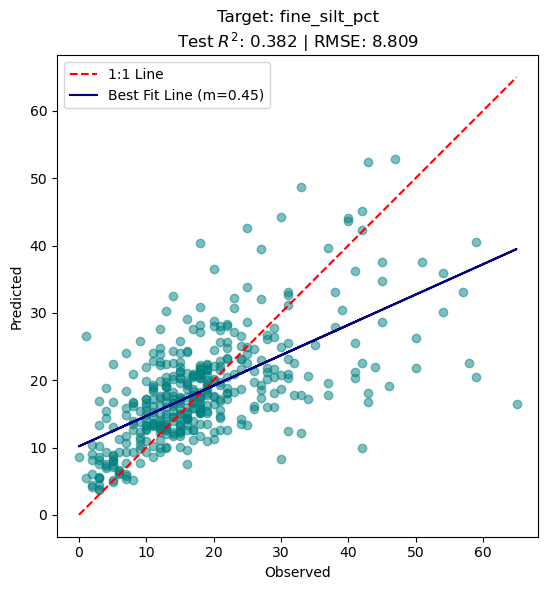

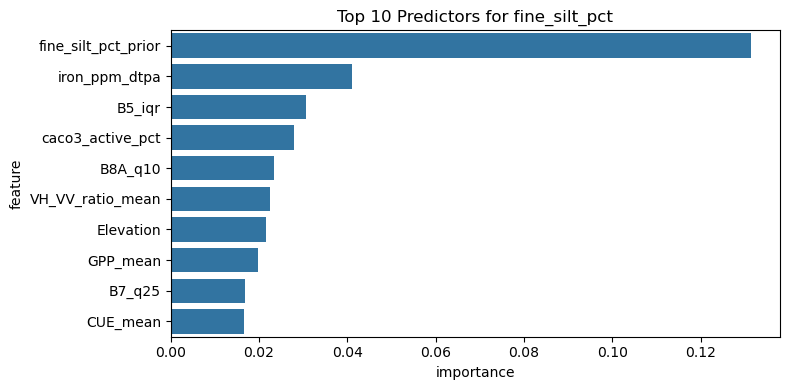


TRAINING MODEL FOR: coarse_silt_pct
Test Performance for coarse_silt_pct: RMSE = 3.0644, R2 = 0.5355


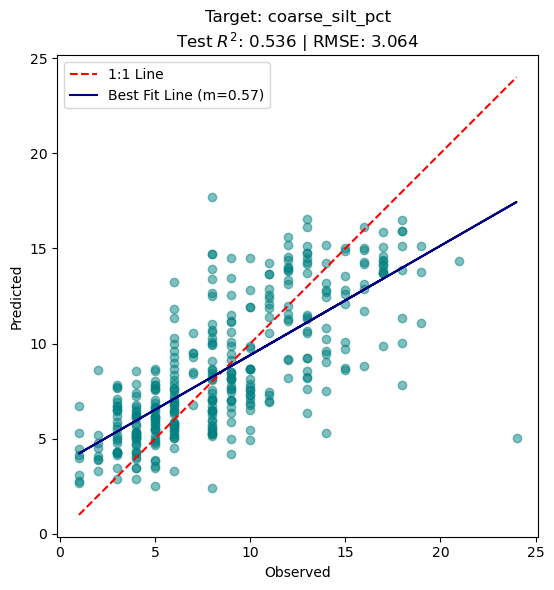

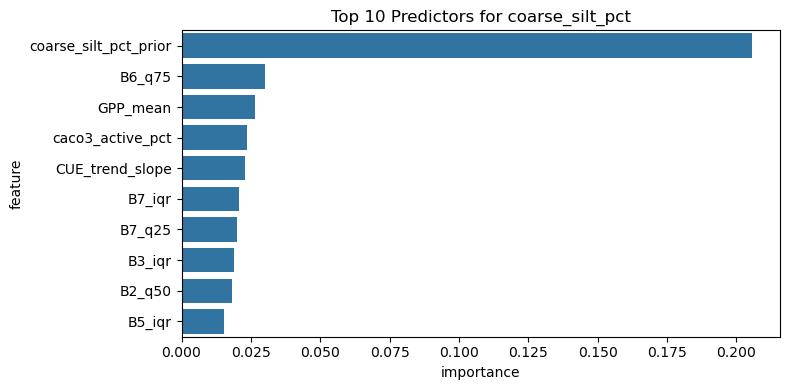


TRAINING MODEL FOR: coarse_element_pct
Test Performance for coarse_element_pct: RMSE = 3.8042, R2 = 0.3233


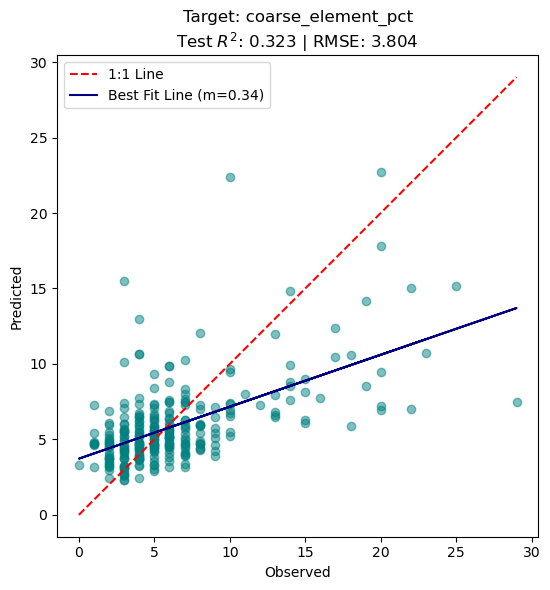

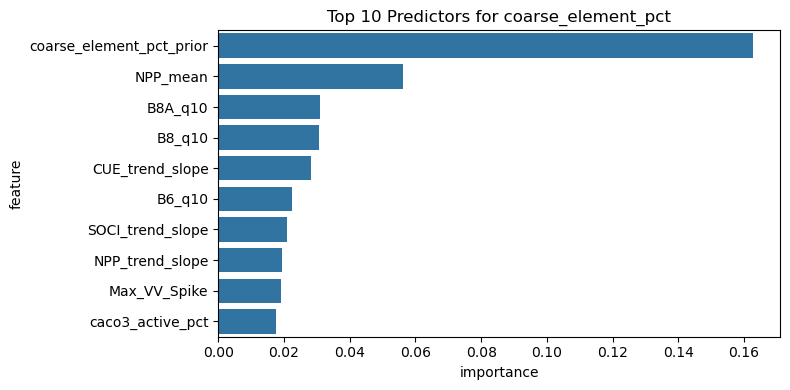


TRAINING MODEL FOR: sand_pct
Test Performance for sand_pct: RMSE = 14.1724, R2 = 0.6682


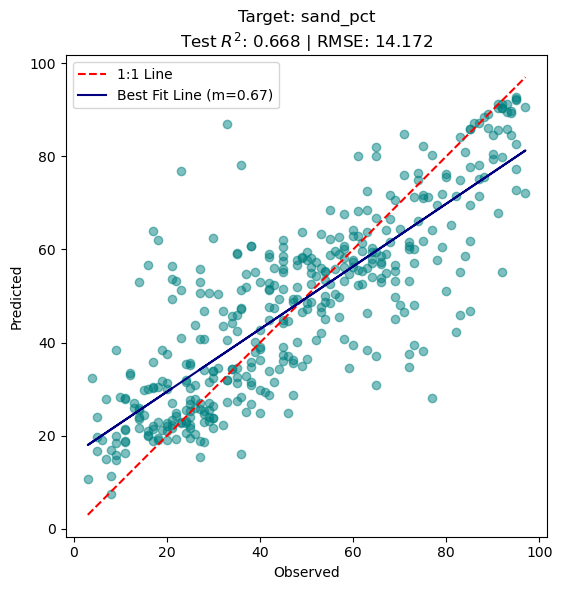

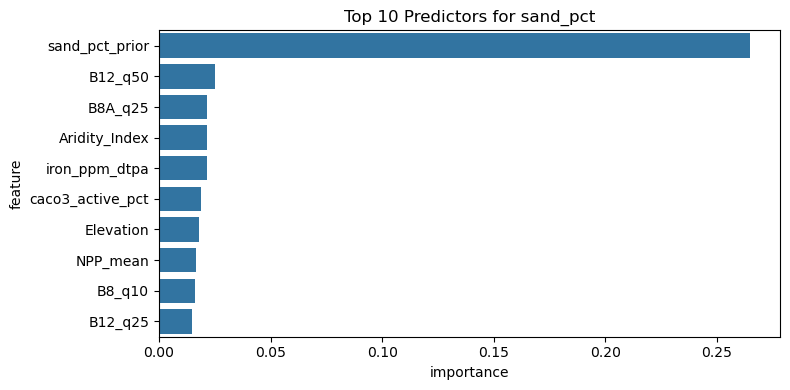


TRAINING MODEL FOR: clay_pct
Test Performance for clay_pct: RMSE = 10.6547, R2 = 0.6248


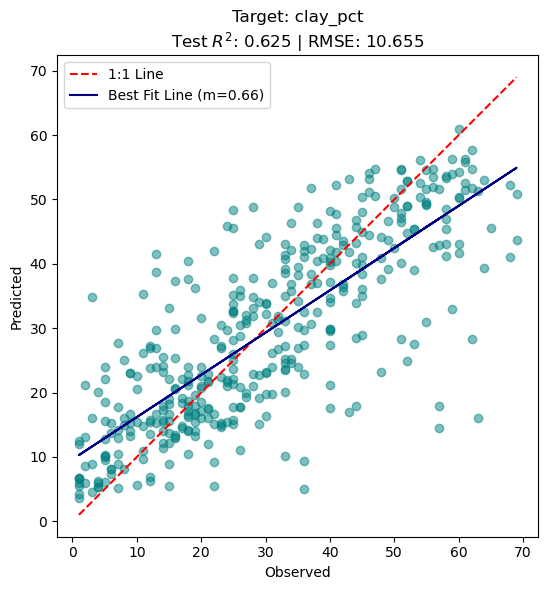

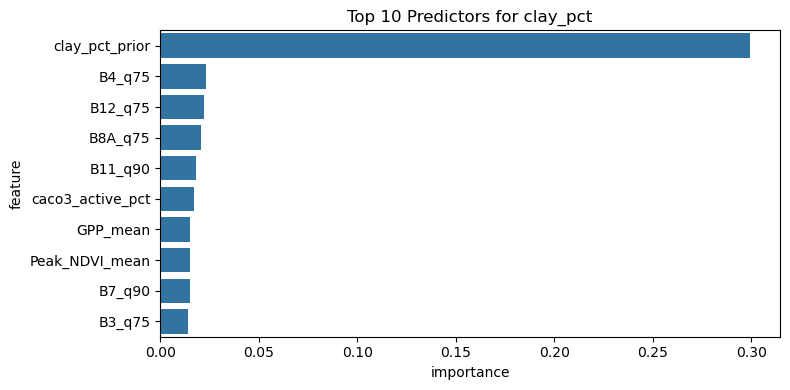


TRAINING MODEL FOR: c_e_c_meq_100g
Test Performance for c_e_c_meq_100g: RMSE = 11.5448, R2 = 0.6145


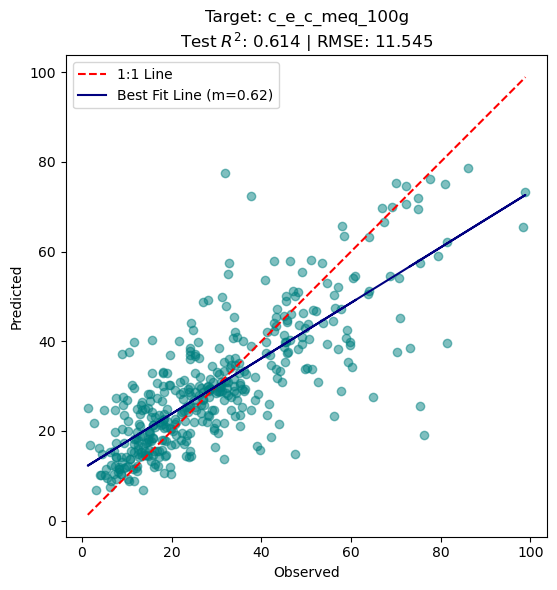

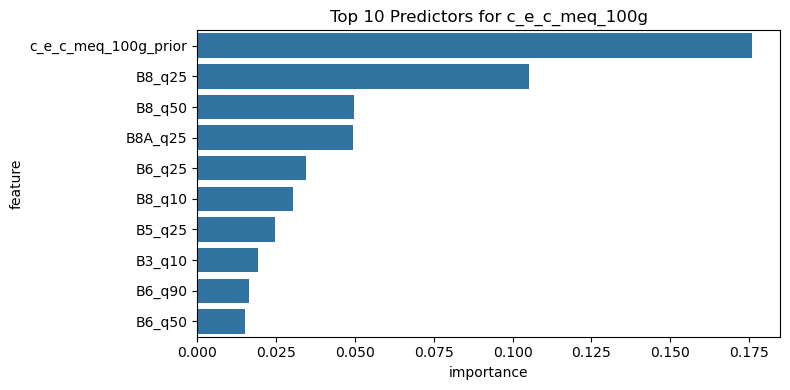


TRAINING MODEL FOR: ce_ext1_5_ms_cm
Test Performance for ce_ext1_5_ms_cm: RMSE = 0.2642, R2 = 0.2618


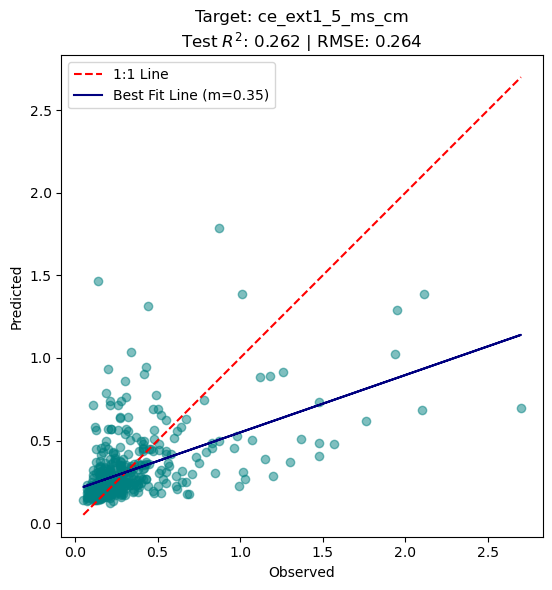

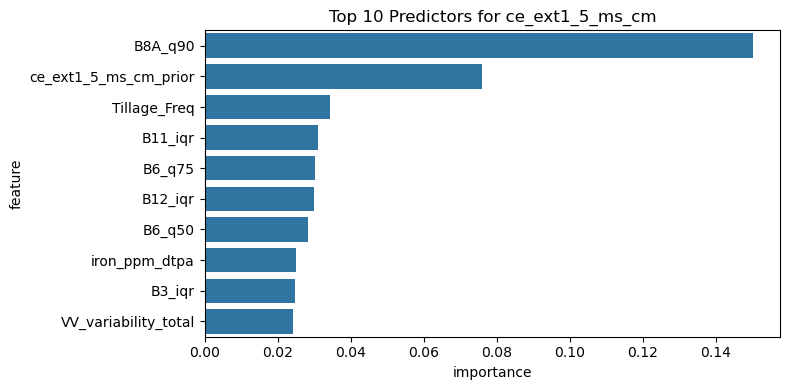


TRAINING MODEL FOR: na2o_ppm
Test Performance for na2o_ppm: RMSE = 166.1557, R2 = 0.4430


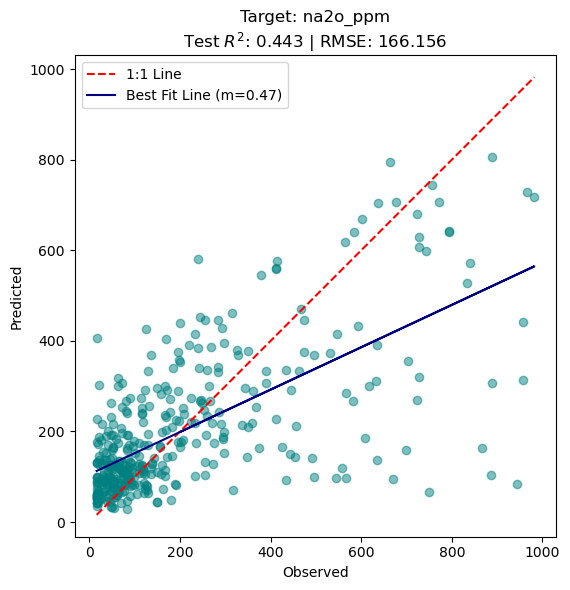

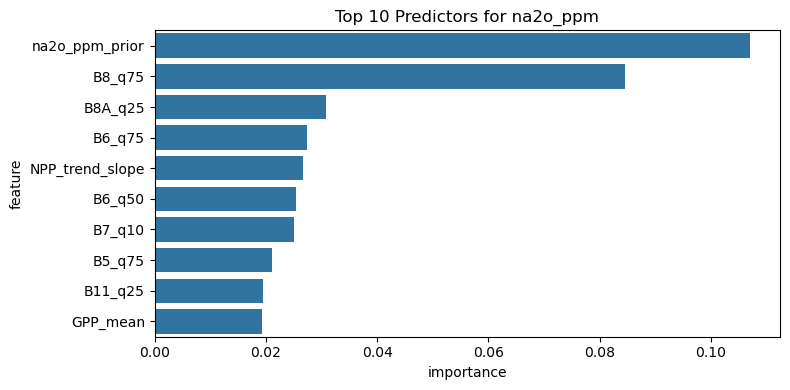


TRAINING MODEL FOR: cl_ppm
Test Performance for cl_ppm: RMSE = 135.2445, R2 = 0.2109


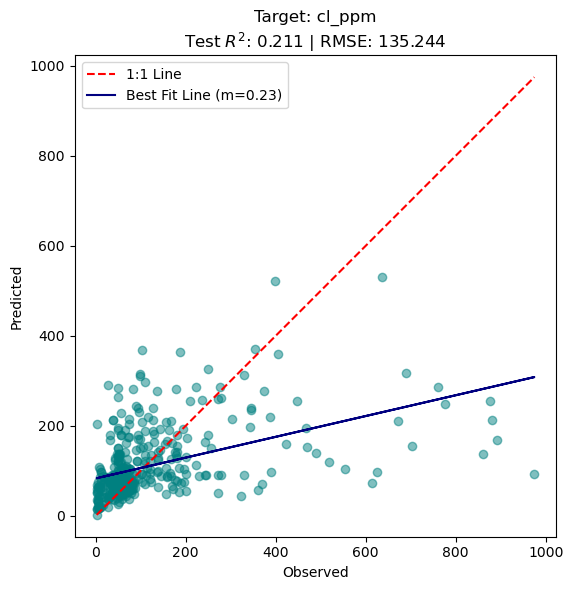

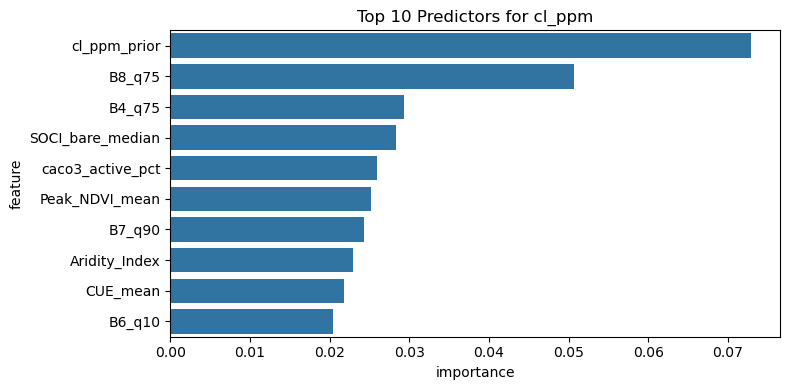


TRAINING MODEL FOR: na_meq_100g
Test Performance for na_meq_100g: RMSE = 0.6811, R2 = 0.0943


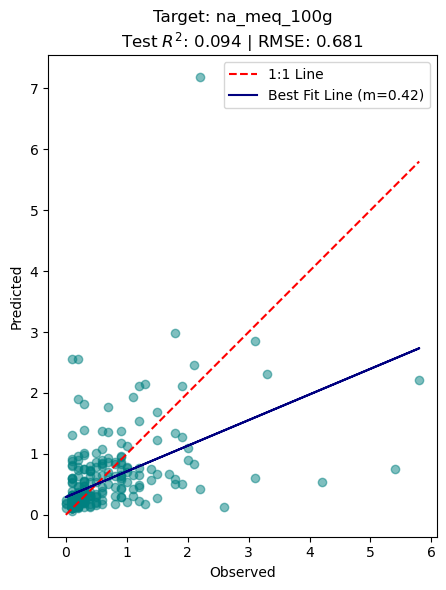

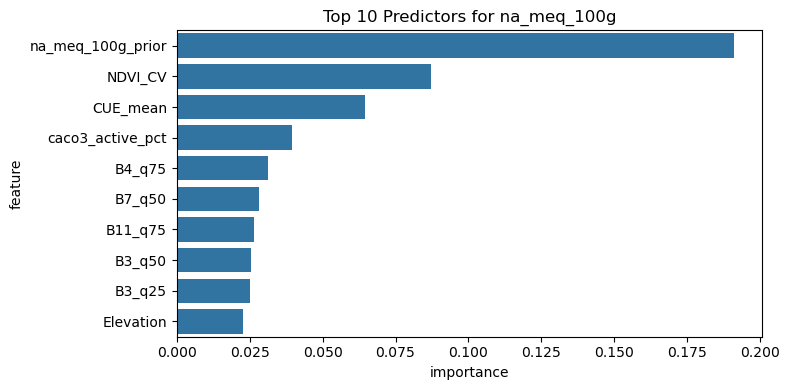


TRAINING MODEL FOR: c_n_ratio
Test Performance for c_n_ratio: RMSE = 2.6768, R2 = 0.1540


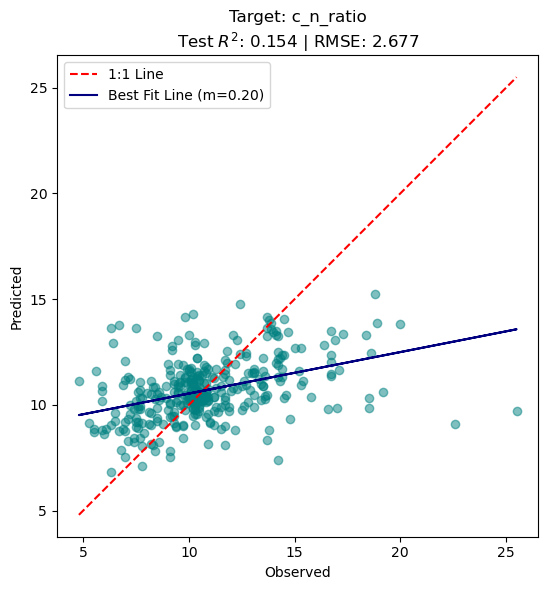

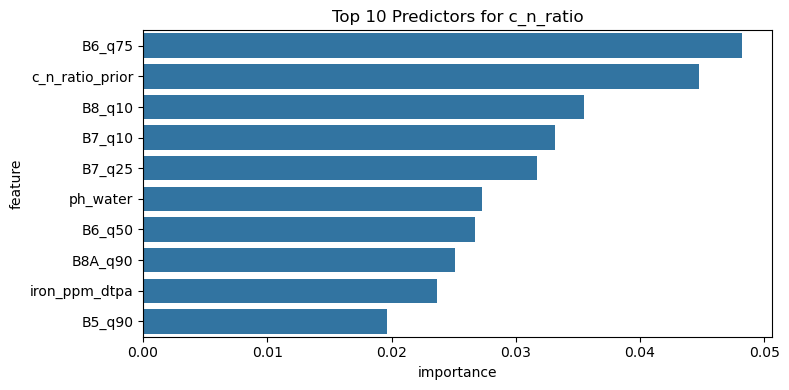


TRAINING MODEL FOR: exchangeable_k2o_ppm
Test Performance for exchangeable_k2o_ppm: RMSE = 164.4730, R2 = 0.2276


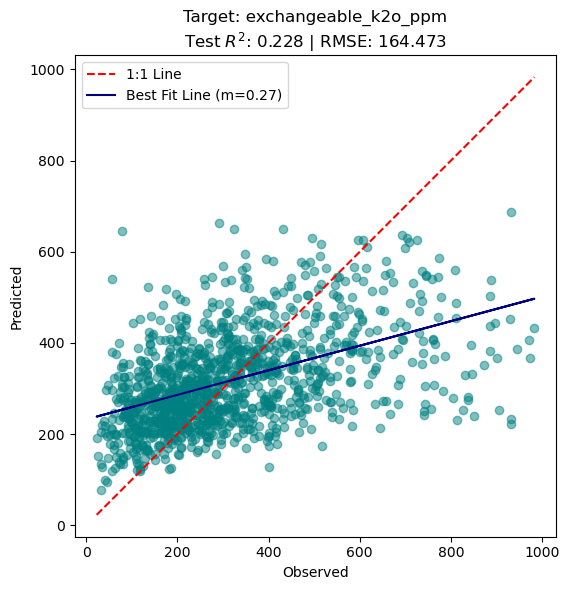

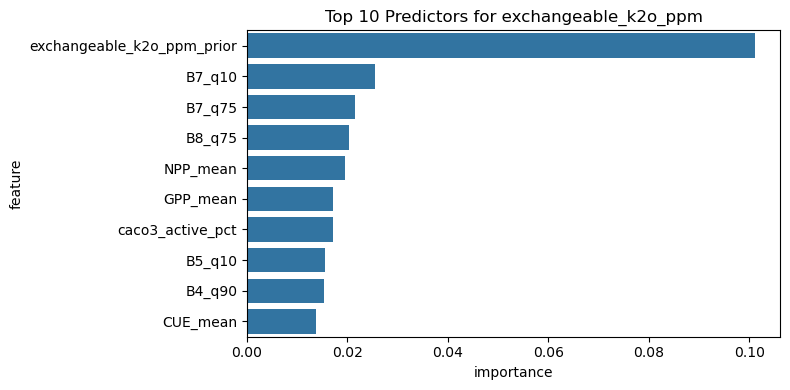


TRAINING MODEL FOR: p2o5_ehangable_olsen_ppm
Test Performance for p2o5_ehangable_olsen_ppm: RMSE = 48.0337, R2 = 0.3505


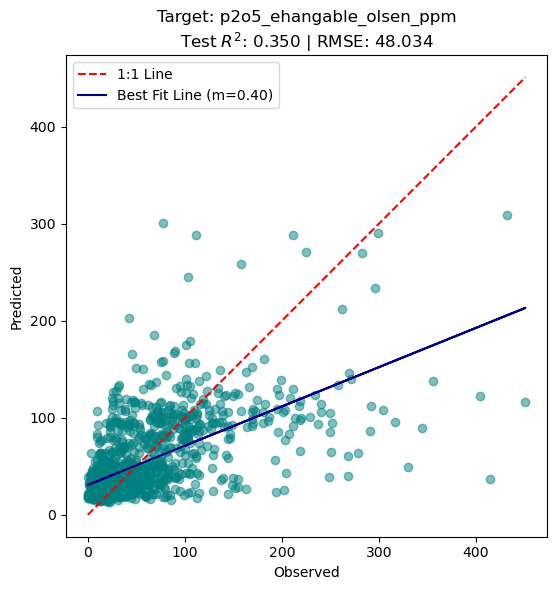

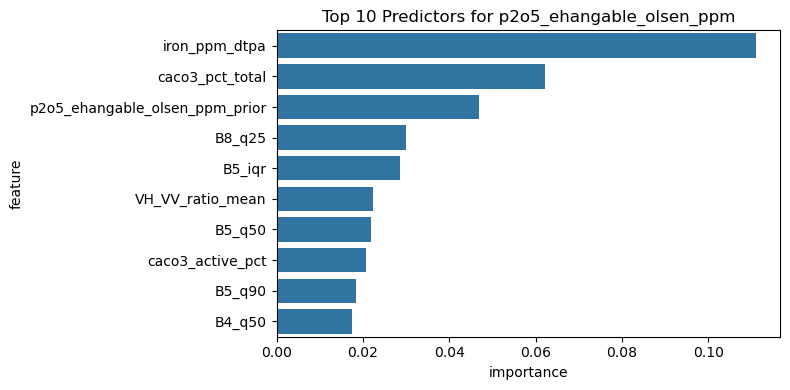


TRAINING MODEL FOR: mgo_ppm
Test Performance for mgo_ppm: RMSE = 225.0528, R2 = 0.3120


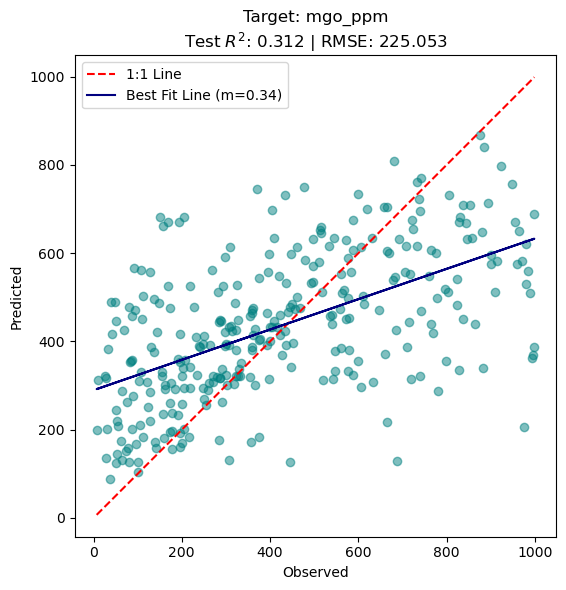

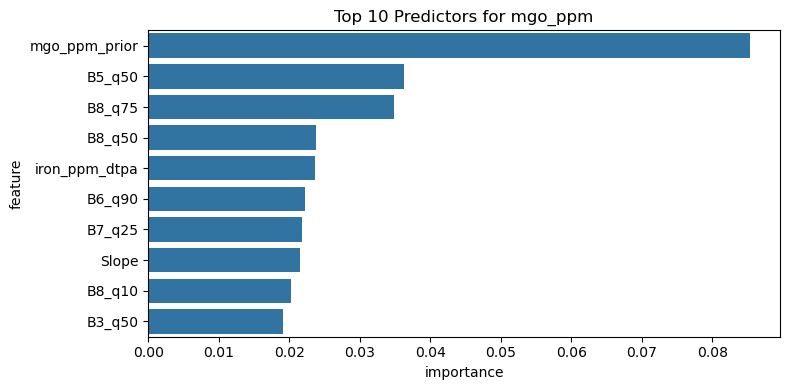


TRAINING MODEL FOR: cao_ppm
Test Performance for cao_ppm: RMSE = 176.3215, R2 = 0.4103


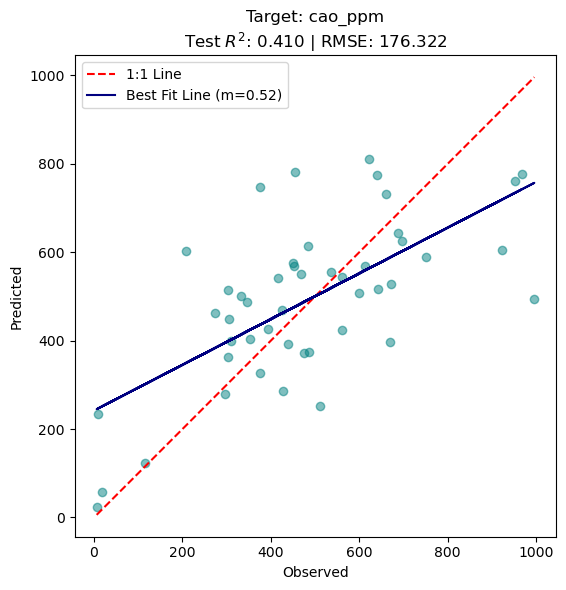

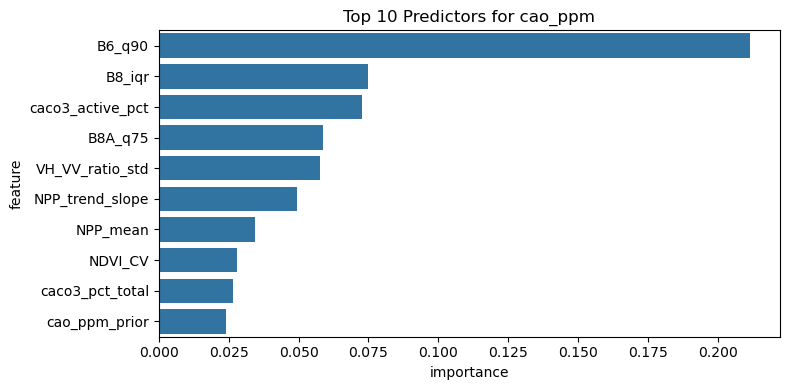


TRAINING MODEL FOR: mn_ppm_dtpa
Test Performance for mn_ppm_dtpa: RMSE = 16.0082, R2 = 0.4824


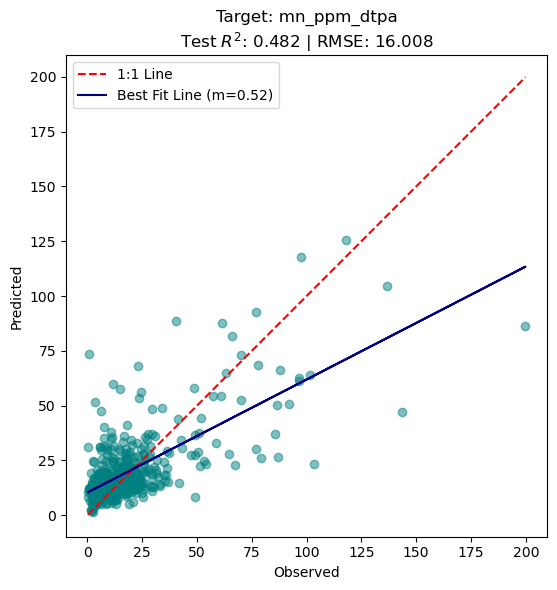

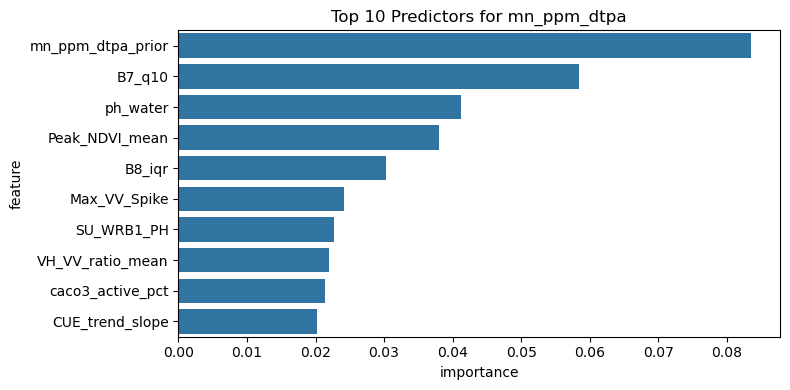


TRAINING MODEL FOR: cu_ppm_dtpa
Test Performance for cu_ppm_dtpa: RMSE = 0.9306, R2 = 0.1639


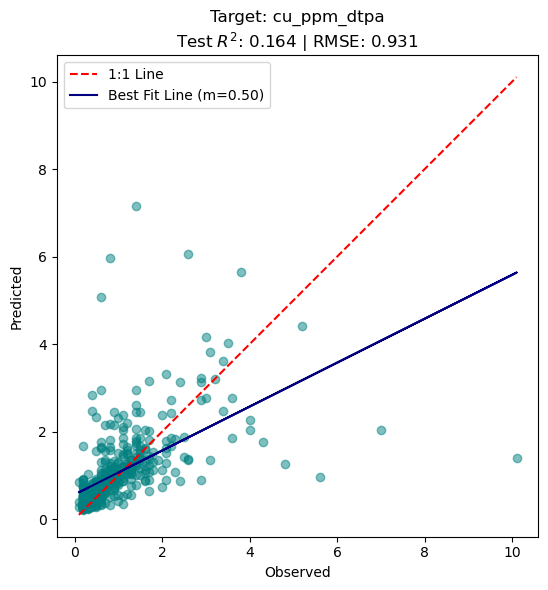

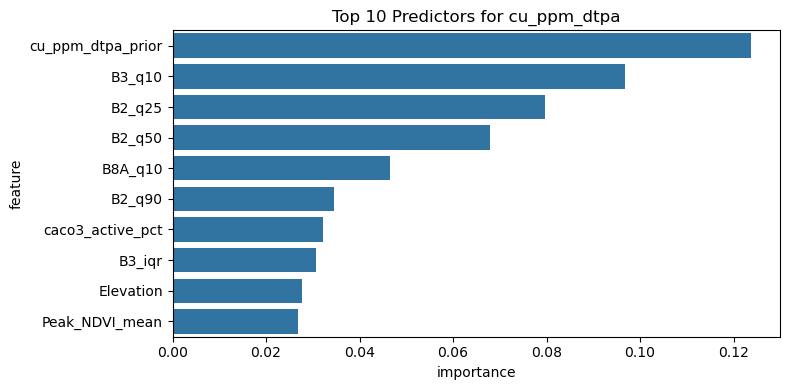


TRAINING MODEL FOR: zn_ppm_dtpa
Test Performance for zn_ppm_dtpa: RMSE = 1.0265, R2 = 0.3571


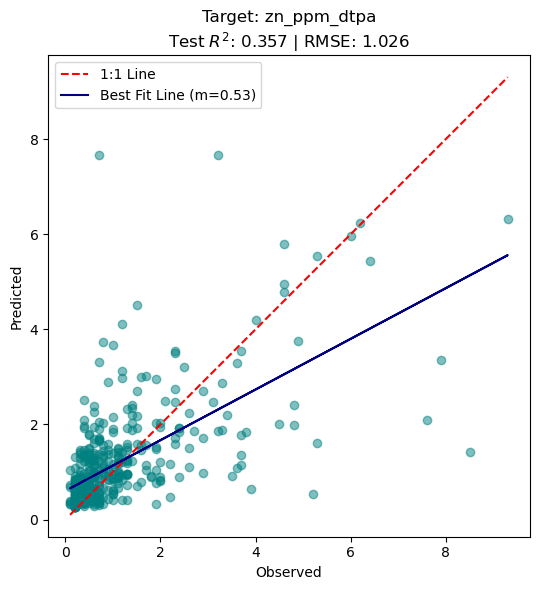

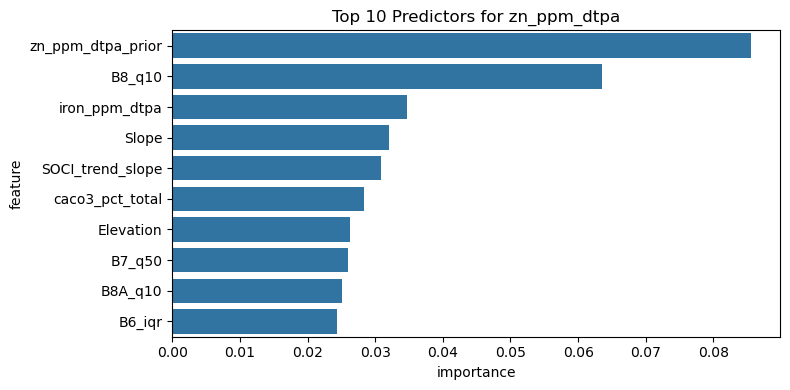


TRAINING MODEL FOR: b_ppm_hot_water
Test Performance for b_ppm_hot_water: RMSE = 0.6028, R2 = -0.1728


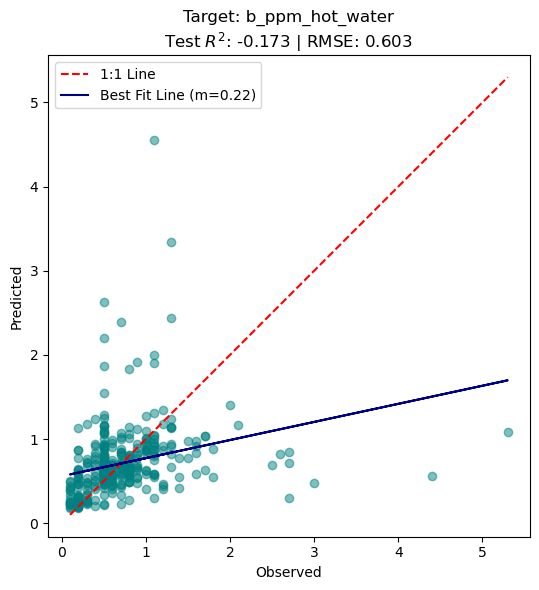

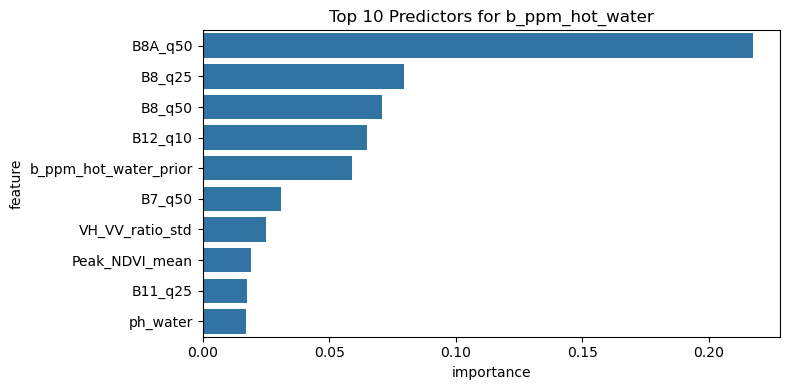


TRAINING MODEL FOR: organic_matter_g_kg
Test Performance for organic_matter_g_kg: RMSE = 8.6261, R2 = 0.3718


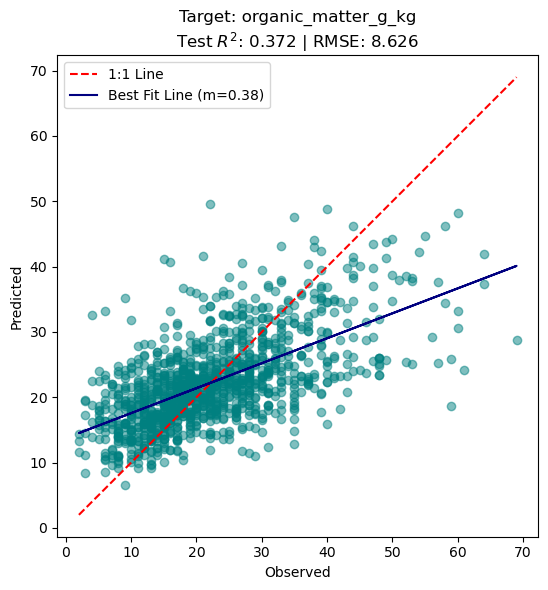

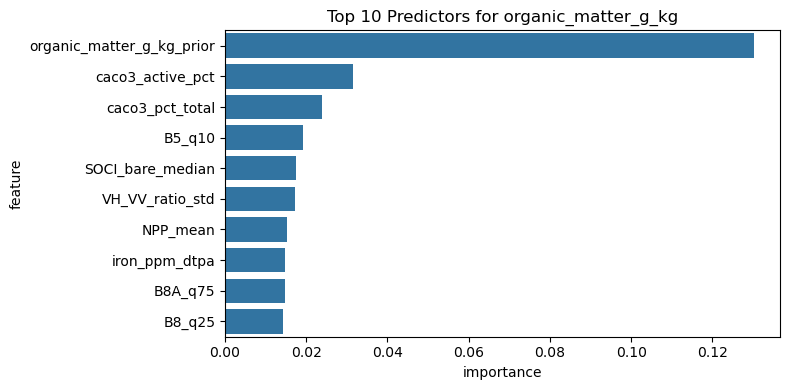


Final Model Summary:
                  target   R2   RMSE
                sand_pct 0.67  14.17
                clay_pct 0.62  10.65
                ph_water   --     --
          total_silt_pct 0.39   9.21
           fine_silt_pct 0.38   8.81
         coarse_silt_pct 0.54   3.06
        caco3_active_pct   --     --
         caco3_pct_total   --     --
          c_e_c_meq_100g 0.61  11.54
               c_n_ratio 0.15   2.68
         ce_ext1_5_ms_cm 0.26   0.26
    exchangeable_k2o_ppm 0.23 164.47
p2o5_ehangable_olsen_ppm 0.35  48.03
     organic_matter_g_kg 0.37   8.63


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors

# 1. Load Data
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_and_covariates.csv')
df = df[df['ph_water'] > 6].copy()
# List of all targets to loop over
target_cols = [
    'total_silt_pct', 'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 
    'sand_pct', 'clay_pct', 
    # 'caco3_active_pct', 
    # 'caco3_pct_total',
    # 'ph_water', 
    # 'iron_ppm_dtpa',
    'c_e_c_meq_100g', 'ce_ext1_5_ms_cm', 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 
    'c_n_ratio', 'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 
    'mgo_ppm', 'cao_ppm', 'mn_ppm_dtpa', 'cu_ppm_dtpa',   
    'zn_ppm_dtpa', 'b_ppm_hot_water', 'organic_matter_g_kg'
]
results = []

# Loop through each target
for target in target_cols:
    if target not in df.columns:
        print(f"Skipping {target}: Not found in dataframe.")
        continue
    
    print(f"\n{'='*40}")
    print(f"TRAINING MODEL FOR: {target}")
    print(f"{'='*40}")

    # 2. Preprocessing for the specific target
    # Remove rows where the current target is NaN
    temp_df = df.dropna(subset=[target]).copy()
    # Drop uuid and ALL other potential targets from X to avoid data leakage
    # We only want the environmental/spectral predictors in X
    X = temp_df.drop(columns=['uuid', 'organic_matter_pct', 'lon', 'lat', 'date', 'depth_from_cm', 'depth_to_cm',
                            #   'SU_WRB1_PH', 
                            #   'Aridity_Index', 'Elevation', 'Slope', 'TWI'
                              ] + target_cols, errors='ignore')
    # X = X.drop(columns=[col for col in X.columns if col.startswith("B")], errors='ignore')
    y = temp_df[target]

    # Build a KNN-based spatial prior for the current target only
    prior_col = f"{target}_prior"
    global_median = pd.to_numeric(temp_df[target], errors='coerce').median()
    X[prior_col] = global_median

    if {'lat', 'lon'}.issubset(temp_df.columns):
        coords = temp_df[['lat', 'lon']]
        valid_coord_mask = coords.notna().all(axis=1)
        n_valid = int(valid_coord_mask.sum())

        if n_valid > 1:
            k = min(10, n_valid - 1)
            nn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
            nn.fit(coords.loc[valid_coord_mask])
            neighbor_idx = nn.kneighbors(coords.loc[valid_coord_mask], return_distance=False)[:, 1:]
            valid_indices = temp_df.index[valid_coord_mask]
            vals = pd.to_numeric(temp_df.loc[valid_indices, target], errors='coerce').to_numpy()
            prior_values = [np.nanmedian(vals[idxs]) for idxs in neighbor_idx]
            X.loc[valid_indices, prior_col] = prior_values
            X[prior_col] = X[prior_col].fillna(global_median)

    # Handle the categorical soil type if it exists in X
    if 'SU_WRB1_PH' in X.columns:
        X['SU_WRB1_PH'] = X['SU_WRB1_PH'].astype('category')

    # 3. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 4. Model Training
    model = xgb.XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=100, 
        learning_rate=0.05,
        max_depth=6,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train, y_train)

    # 5. Evaluation
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"Test Performance for {target}: RMSE = {rmse:.4f}, R2 = {r2:.4f}")
    results.append({'target': target, 'R2': r2, 'RMSE': rmse})

    # 6. Visualization: Observed vs Predicted
    # plt.figure(figsize=(6, 5))
    # plt.scatter(y_test, preds, alpha=0.5, color='teal')
    # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    # plt.title(f'Target: {target}\nTest R2: {r2:.3f}')
    # plt.xlabel('Observed')
    # plt.ylabel('Predicted')
    # plt.tight_layout()
    # plt.show()

    # m = slope, b = intercept
    m, b = np.polyfit(y_test, preds, 1)

    # 6. Visualization: Observed vs Predicted
    plt.figure(figsize=(6, 6))  # Square figure helps with 1:1 aspect
    plt.scatter(y_test, preds, alpha=0.5, color='teal')

    # Add the 1:1 Identity Line (Ideal)
    mn, mx = y_test.min(), y_test.max()
    plt.plot([mn, mx], [mn, mx], 'r--', label='1:1 Line')

    # Add the Regression Line (Actual Trend)
    plt.plot(y_test, m * y_test + b, color='navy', label=f'Best Fit Line (m={m:.2f})')

    # Update Title with RMSE and set Labels
    plt.title(f'Target: {target}\nTest $R^2$: {r2:.3f} | RMSE: {rmse:.3f}')
    plt.xlabel('Observed')
    plt.ylabel('Predicted')

    # 3. Force 1:1 Aspect Ratio
    plt.gca().set_aspect('equal', adjustable='box')

    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7. Feature Importance
    importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x='importance', y='feature', data=importances.head(10))
    plt.title(f"Top 10 Predictors for {target}")
    plt.tight_layout()
    plt.show()

# 1. Define the specific targets you want to display
display_targets = [
    'sand_pct', 'clay_pct', 'ph_water', 'total_silt_pct', 'fine_silt_pct', 'coarse_silt_pct', 
    'caco3_active_pct', 'caco3_pct_total', 'c_e_c_meq_100g', 'c_n_ratio', 'ce_ext1_5_ms_cm',
    'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 'organic_matter_g_kg'
]

# 2. Create a template DataFrame with all desired targets
template_df = pd.DataFrame({'target': display_targets})

# 3. Create the summary DataFrame from the actual results list
summary_df_full = pd.DataFrame(results)

# 4. Merge the template with the results
# 'left' join keeps everything in display_targets
summary_df = pd.merge(template_df, summary_df_full, on='target', how='left')

# 5. Replace NaN values with '--' for display
# We convert to string first so that '--' can coexist with numeric values
summary_df = summary_df.round(2).astype(str).replace('nan', '--')

print("\nFinal Model Summary:")
print(summary_df.to_string(index=False))

# Optional: Save to CSV (using a version that keeps NAs if you need to do math later)
# summary_df.to_csv('soil_model_comparison.csv', index=False)

In [1]:
import pandas as pd
df_ts = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_Veg_TS_with_indices.csv')
df_static= pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')

--- Training on device: cuda ---
Total samples (no outlier filtering): 4206
Pre-processing sequences with one-hot categorical inputs... please wait a moment.
Finished pre-processing 4083 samples.
Target distribution summary:
Train: n=2612, mean=22.6704, variance=163.9331
Validation: n=654, mean=23.4465, variance=193.7578
Test: n=817, mean=22.5006, variance=156.8889


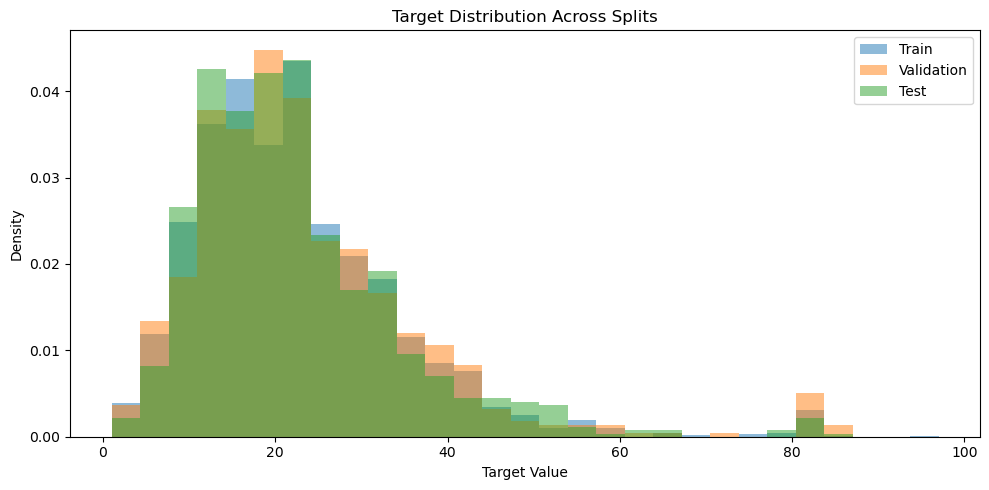

Baseline (predict train mean) on Validation: RMSE = 13.9413, R2 = -0.0031


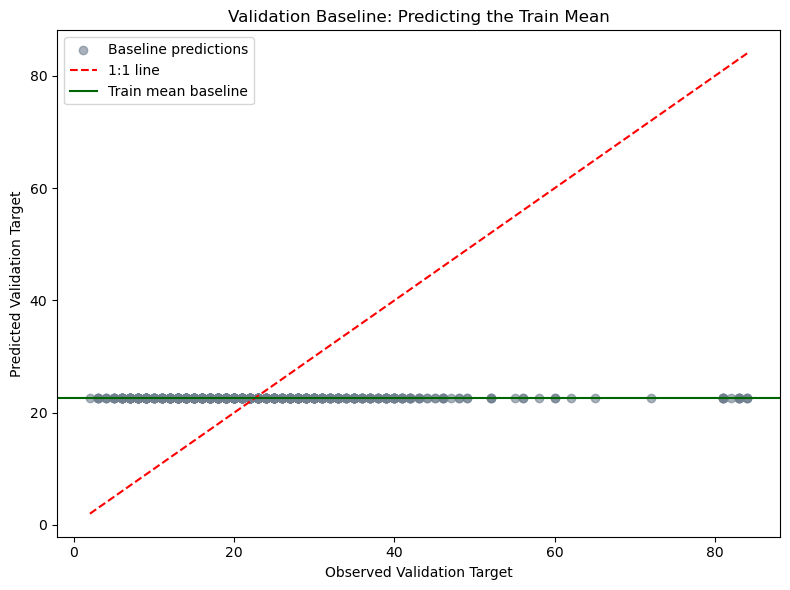

Epoch 000 | Train Loss: 14.1602 | Train(eval): 8.6736 | Val Loss: 9.2610
Epoch 010 | Train Loss: 7.3805 | Train(eval): 7.1050 | Val Loss: 7.6261
Epoch 020 | Train Loss: 6.5855 | Train(eval): 6.2853 | Val Loss: 6.8678
Epoch 030 | Train Loss: 6.2477 | Train(eval): 5.7418 | Val Loss: 6.6366
Epoch 040 | Train Loss: 5.8044 | Train(eval): 5.3121 | Val Loss: 6.7773
Epoch 050 | Train Loss: 5.5647 | Train(eval): 5.0533 | Val Loss: 7.0323
--- Early Stopping at Epoch 59! ---
Restored best model with Validation Loss: 6.5737
Semivariogram fitted in UTM EPSG:32629: range = 70732972716.93 m


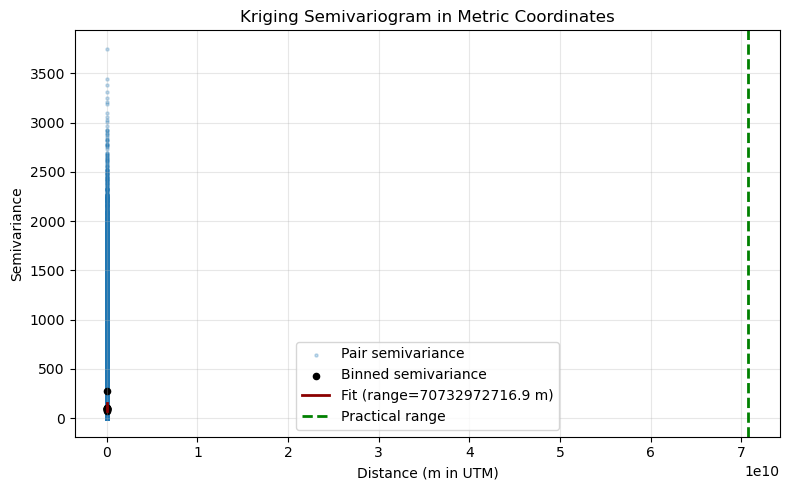

Spatial residual correction learned on validation set:
  Radius (practical range): 70732972716.93 m
  Fallback k when outside radius: 653
  Validation bias before correction: -0.4660
  Validation bias after correction:  -0.0000


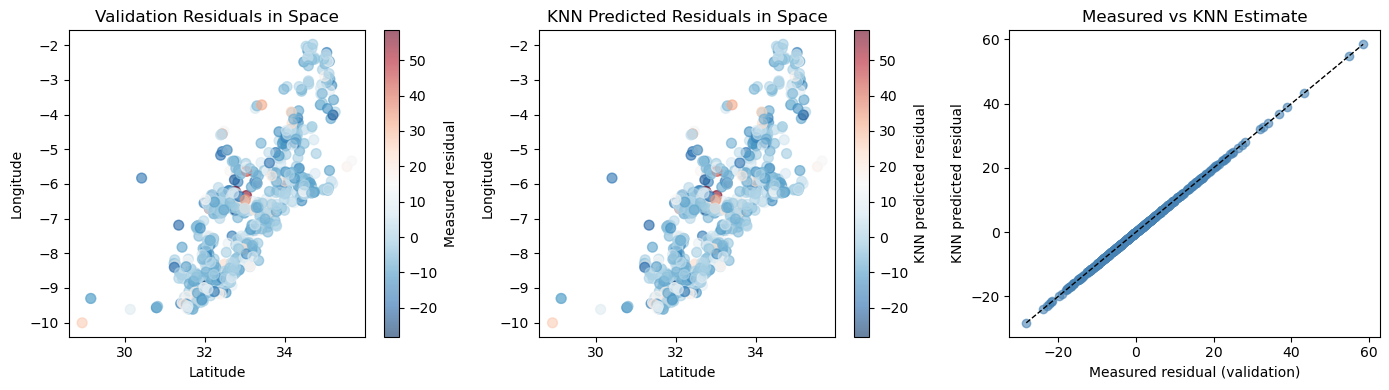

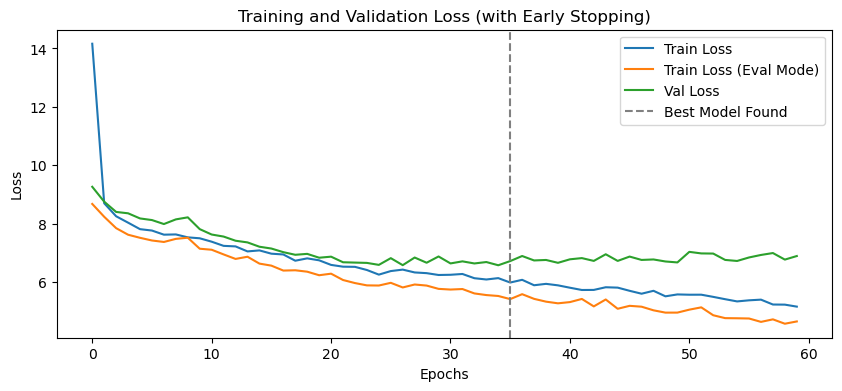

Test metrics: raw vs spatial residual-corrected
  Raw      -> RMSE: 9.9227, R2: 0.3724, Bias: -0.2654
  Corrected-> RMSE: 9.6875, R2: 0.4018, Bias: 0.1059
  Test fallback k outside radius: 653


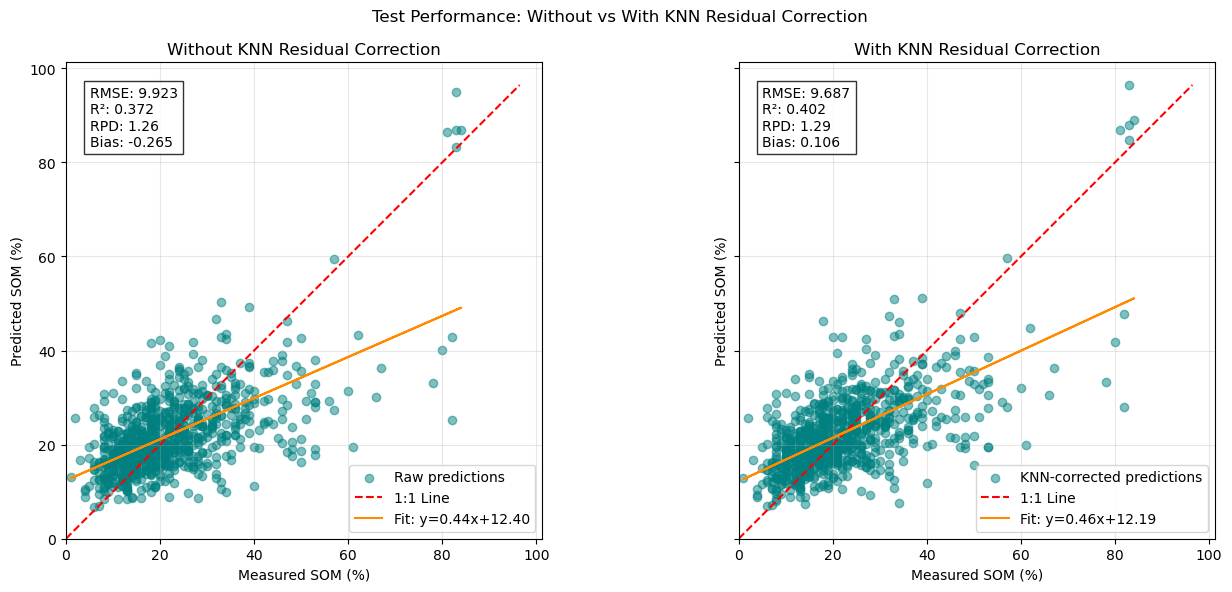

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from pyproj import CRS, Transformer
from scipy.optimize import curve_fit
from scipy.spatial.distance import cdist, pdist
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import copy

# ==========================================
# 1. DATASET CLASS (One-hot encoding for SU_WRB1_PH)
# ==========================================
class SoilFusionDataset(Dataset):
    def __init__(self, static_df, ts_df, target_col='organic_matter_g_kg', seq_len=103):
        self.seq_len = seq_len

        # 1. Cleaning
        static_df = static_df.replace([np.inf, -np.inf], np.nan).copy()
        ts_df = ts_df.replace([np.inf, -np.inf], np.nan).copy()

        # 2. Match UUIDs and keep deterministic order from static_df
        static_df = static_df.drop_duplicates(subset=['uuid'])
        common_uuids_set = set(static_df['uuid']).intersection(set(ts_df['uuid']))
        common_uuids = [uid for uid in static_df['uuid'] if uid in common_uuids_set]

        static_df = static_df[static_df['uuid'].isin(common_uuids)].set_index('uuid').loc[common_uuids]
        ts_df = ts_df[ts_df['uuid'].isin(common_uuids)].copy()

        # 3. Feature definitions
        self.cat_col = 'SU_WRB1_PH'
        self.static_num_feats = [
            'caco3_pct_total', 'caco3_active_pct', 'ph_water', 'iron_ppm_dtpa',
            'Elevation', 'Slope', 'TWI', 'Aridity_Index',
            'B11_q10', 'B11_q25', 'B11_q50', 'B11_q75', 'B11_q90',
            'B12_q10', 'B12_q25', 'B12_q50', 'B12_q75', 'B12_q90',
            'B2_q10', 'B2_q25', 'B2_q50', 'B2_q75', 'B2_q90',
            'B3_q10', 'B3_q25', 'B3_q50', 'B3_q75', 'B3_q90',
            'B4_q10', 'B4_q25', 'B4_q50', 'B4_q75', 'B4_q90',
            'B5_q10', 'B5_q25', 'B5_q50', 'B5_q75', 'B5_q90',
            'B6_q10', 'B6_q25', 'B6_q50', 'B6_q75', 'B6_q90',
            'B7_q10', 'B7_q25', 'B7_q50', 'B7_q75', 'B7_q90',
            'B8_q10', 'B8_q25', 'B8_q50', 'B8_q75', 'B8_q90',
            'B8A_q10', 'B8A_q25', 'B8A_q50', 'B8A_q75', 'B8A_q90',
            'B11_iqr', 'B12_iqr', 'B2_iqr', 'B3_iqr', 'B4_iqr',
            'B5_iqr', 'B6_iqr', 'B7_iqr', 'B8_iqr', 'B8A_iqr'
        ]

        self.ts_feats = ['GPP_monthly', 'VH', 'VV', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'NDVI', 'SOCI', 'NBR2', 'VH/VV']

        # 4. Scale numeric features only
        static_scaler = StandardScaler()
        ts_scaler = StandardScaler()

        static_num_scaled = static_scaler.fit_transform(static_df[self.static_num_feats].fillna(0))
        ts_df[self.ts_feats] = ts_scaler.fit_transform(ts_df[self.ts_feats].fillna(0))

        # 5. Categorical encoding for one-hot representation
        soil_series = static_df[self.cat_col].fillna('UNK').astype(str)
        soil_categories = pd.Categorical(soil_series)
        soil_codes = soil_categories.codes.astype(np.int64)

        self.soil_classes = list(soil_categories.categories)
        self.num_soil_classes = len(self.soil_classes)
        self.static_num_dim = len(self.static_num_feats)
        self.ts_dim = len(self.ts_feats)

        one_hot = np.eye(self.num_soil_classes, dtype=np.float32)[soil_codes]

        # 6. Pre-group TS once for speed
        print('Pre-processing sequences with one-hot categorical inputs... please wait a moment.')
        self.data = []
        self.uuids = common_uuids  # Store UUIDs for later spatial correction
        grouped = ts_df.sort_values('observation_date').groupby('uuid')

        for i, uid in enumerate(common_uuids):
            s_num_val = torch.tensor(static_num_scaled[i], dtype=torch.float32)
            s_cat_val = torch.tensor(one_hot[i], dtype=torch.float32)

            group = grouped.get_group(uid)[self.ts_feats].values
            if len(group) > self.seq_len:
                group = group[-self.seq_len:]
            else:
                pad = np.zeros((self.seq_len - len(group), len(self.ts_feats)))
                group = np.vstack([pad, group])

            t_val = torch.tensor(group, dtype=torch.float32)
            y_val = torch.tensor(static_df.loc[uid, target_col], dtype=torch.float32).view(1)

            self.data.append((s_cat_val, s_num_val, t_val, y_val))

        print(f'Finished pre-processing {len(self.data)} samples.')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class MultimodalSoilNet(nn.Module):
    def __init__(self, static_num_dim, ts_dim, num_soil_classes, hidden_dim=128, lstm_layers=1):
        super(MultimodalSoilNet, self).__init__()

        # --- TS Branch ---
        ts_channels = max(32, min(64, ts_dim * 2))
        self.ts_cnn = nn.Sequential(
            nn.Conv1d(ts_dim, ts_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(ts_channels)
        )

        self.lstm = nn.LSTM(
            ts_channels, hidden_dim, num_layers=lstm_layers,
            batch_first=True, bidirectional=True, dropout=0.0 if lstm_layers == 1 else 0.2
        )

        self.residual_proj = nn.Linear(ts_channels, hidden_dim * 2)

        # --- Static Branch ---
        # Input = numerical static features + one-hot categorical vector.
        static_in_dim = static_num_dim + num_soil_classes
        self.static_branch = nn.Sequential(
            nn.Linear(static_in_dim, max(64, static_in_dim // 2)),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(max(64, static_in_dim // 2), max(32, static_in_dim // 4)),
            nn.ReLU()
        )

        # --- Regression Head ---
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2 + max(32, static_in_dim // 4), max(64, hidden_dim)),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(max(64, hidden_dim), max(32, hidden_dim // 2)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(32, hidden_dim // 2), 1)
        )

    def forward(self, static_cat_oh, static_num_x, ts_x):
        # 1. Fuse one-hot category with static numeric features
        static_in = torch.cat((static_num_x, static_cat_oh), dim=1)

        # 2. Process TS
        identity = ts_x.transpose(1, 2)
        ts_feat = self.ts_cnn(identity)
        ts_feat = ts_feat.transpose(1, 2)

        res_shortcut = ts_feat.mean(dim=1)
        res_shortcut = self.residual_proj(res_shortcut)

        _, (h_n, _) = self.lstm(ts_feat)
        ts_out = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        ts_out = ts_out + res_shortcut

        # 3. Static branch
        static_out = self.static_branch(static_in)

        # 4. Fusion and regression
        fused = torch.cat((ts_out, static_out), dim=1)
        return self.regressor(fused)


# ==========================================
# 3. TRAINING FUNCTION (GPU Enabled)
# ==========================================
def run_training(df_static, df_ts):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'--- Training on device: {device} ---')

    # Filter target (keep all, no outlier removal)
    target_col = 'organic_matter_g_kg' if 'organic_matter_g_kg' in df_static.columns else 'organic_matter_pct'
    df_static = df_static.dropna(subset=[target_col]).copy()
    print(f'Total samples (no outlier filtering): {len(df_static)}')

    dataset = SoilFusionDataset(df_static, df_ts, target_col=target_col, seq_len=103)

    batch_size = 32 if dataset.static_num_dim >= 48 else 64

    # 64% train, 16% validation, 20% test
    all_idx = list(range(len(dataset)))
    train_val_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=42)

    def _extract_targets(indices):
        return np.array([dataset[i][3].item() for i in indices], dtype=float)

    train_targets = _extract_targets(train_idx)
    val_targets = _extract_targets(val_idx)
    test_targets = _extract_targets(test_idx)

    def _print_target_stats(name, values):
        print(f'{name}: n={len(values)}, mean={values.mean():.4f}, variance={values.var(ddof=0):.4f}')

    print('Target distribution summary:')
    _print_target_stats('Train', train_targets)
    _print_target_stats('Validation', val_targets)
    _print_target_stats('Test', test_targets)

    plt.figure(figsize=(10, 5))
    bins = np.linspace(np.min(np.concatenate([train_targets, val_targets, test_targets])), np.max(np.concatenate([train_targets, val_targets, test_targets])), 30)
    plt.hist(train_targets, bins=bins, alpha=0.5, density=True, label='Train')
    plt.hist(val_targets, bins=bins, alpha=0.5, density=True, label='Validation')
    plt.hist(test_targets, bins=bins, alpha=0.5, density=True, label='Test')
    plt.title('Target Distribution Across Splits')
    plt.xlabel('Target Value')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Simple baseline on validation: predict the train mean everywhere
    train_mean_baseline = float(train_targets.mean())
    val_baseline_preds = np.full_like(val_targets, train_mean_baseline, dtype=float)
    baseline_rmse = np.sqrt(mean_squared_error(val_targets, val_baseline_preds))
    baseline_r2 = r2_score(val_targets, val_baseline_preds)
    print(f'Baseline (predict train mean) on Validation: RMSE = {baseline_rmse:.4f}, R2 = {baseline_r2:.4f}')

    plt.figure(figsize=(8, 6))
    plt.scatter(val_targets, val_baseline_preds, alpha=0.6, color='slategray', label='Baseline predictions')
    plt.plot([val_targets.min(), val_targets.max()], [val_targets.min(), val_targets.max()], 'r--', label='1:1 line')
    plt.axhline(train_mean_baseline, color='darkgreen', linestyle='-', label='Train mean baseline')
    plt.xlabel('Observed Validation Target')
    plt.ylabel('Predicted Validation Target')
    plt.title('Validation Baseline: Predicting the Train Mean')
    plt.legend()
    plt.tight_layout()
    plt.show()

    train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=batch_size)
    test_loader = DataLoader(torch.utils.data.Subset(dataset, test_idx), batch_size=batch_size)

    model = MultimodalSoilNet(
        static_num_dim=dataset.static_num_dim,
        ts_dim=dataset.ts_dim,
        num_soil_classes=dataset.num_soil_classes,
        hidden_dim=128,
        lstm_layers=1
    ).to(device)

    criterion = nn.HuberLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

    history = {'train_loss': [], 'train_eval_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience = 25
    trigger_times = 0

    epochs = 200
    for epoch in range(epochs):
        # 1. Training
        model.train()
        running_train_loss = 0.0
        for s_cat_oh, s_x, t_x, y in train_loader:
            s_cat_oh = s_cat_oh.to(device)
            s_x, t_x, y = s_x.to(device), t_x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(s_cat_oh, s_x, t_x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # 2. Validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for s_cat_oh, s_x, t_x, y in val_loader:
                s_cat_oh = s_cat_oh.to(device)
                s_x, t_x, y = s_x.to(device), t_x.to(device), y.to(device)
                pred = model(s_cat_oh, s_x, t_x)
                val_loss = criterion(pred, y)
                running_val_loss += val_loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        # 3. Train-eval loss (same mode as validation)
        running_train_eval_loss = 0.0
        with torch.no_grad():
            for s_cat_oh, s_x, t_x, y in train_loader:
                s_cat_oh = s_cat_oh.to(device)
                s_x, t_x, y = s_x.to(device), t_x.to(device), y.to(device)
                pred = model(s_cat_oh, s_x, t_x)
                train_eval_loss = criterion(pred, y)
                running_train_eval_loss += train_eval_loss.item()

        avg_train_eval_loss = running_train_eval_loss / len(train_loader)

        history['train_loss'].append(avg_train_loss)
        history['train_eval_loss'].append(avg_train_eval_loss)
        history['val_loss'].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'--- Early Stopping at Epoch {epoch}! ---')
                break

        if epoch % 10 == 0:
            print(f'Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Train(eval): {avg_train_eval_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    model.load_state_dict(best_model_wts)
    print(f'Restored best model with Validation Loss: {best_val_loss:.4f}')

    # --- Learn spatial KNN residual correction on validation ---
    model.eval()
    val_true, val_pred_raw = [], []
    with torch.no_grad():
        for s_cat_oh, s_x, t_x, y in val_loader:
            s_cat_oh = s_cat_oh.to(device)
            s_x, t_x = s_x.to(device), t_x.to(device)
            preds = model(s_cat_oh, s_x, t_x)
            val_true.extend(y.numpy().flatten())
            val_pred_raw.extend(preds.cpu().numpy().flatten())

    val_true = np.array(val_true)
    val_pred_raw = np.array(val_pred_raw)
    val_residuals = val_true - val_pred_raw

    # Project geographic coordinates to metric UTM before distance calculations
    spatial_lookup = df_static[['uuid', 'lat', 'lon']].dropna().drop_duplicates('uuid').set_index('uuid')

    def _utm_crs_from_lon_lat(lon, lat):
        zone = int((lon + 180.0) // 6.0) + 1
        epsg = 32600 + zone if lat >= 0 else 32700 + zone
        return CRS.from_epsg(epsg)

    def _to_metric_utm(coords_latlon, utm_crs=None):
        coords_latlon = np.asarray(coords_latlon, dtype=float)
        center_lat = float(np.nanmean(coords_latlon[:, 0]))
        center_lon = float(np.nanmean(coords_latlon[:, 1]))
        if utm_crs is None:
            utm_crs = _utm_crs_from_lon_lat(center_lon, center_lat)
        transformer = Transformer.from_crs('EPSG:4326', utm_crs, always_xy=True)
        x_m, y_m = transformer.transform(coords_latlon[:, 1], coords_latlon[:, 0])
        return np.column_stack([x_m, y_m]), utm_crs

    def _coords_for_indices(indices):
        coords_ll = []
        keep_positions = []
        for position, dataset_index in enumerate(indices):
            uid = dataset.uuids[dataset_index]
            if uid in spatial_lookup.index:
                row = spatial_lookup.loc[uid]
                coords_ll.append([float(row['lat']), float(row['lon'])])
                keep_positions.append(position)
        return np.asarray(coords_ll, dtype=float), np.asarray(keep_positions, dtype=int)

    def _fit_semivariogram(coords_m, residuals):
        if len(coords_m) < 6:
            return None

        pair_dist = pdist(coords_m, metric='euclidean')
        pair_semivar = 0.5 * (pdist(residuals.reshape(-1, 1), metric='euclidean') ** 2)

        n_bins = min(12, max(6, len(coords_m) // 3))
        bin_means, bin_edges, _ = binned_statistic(pair_dist, pair_semivar, statistic='mean', bins=n_bins)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        valid_mask = np.isfinite(bin_means)
        if valid_mask.sum() < 4:
            return None

        nugget0 = max(0.0, float(np.nanmin(bin_means[valid_mask])))
        sill0 = float(np.nanmax(bin_means[valid_mask]))
        scale0 = float(max(np.nanmax(bin_centers[valid_mask]) / 3.0, 1.0))

        def exp_variogram(h, nugget, sill, scale):
            return nugget + (sill - nugget) * (1 - np.exp(-h / (scale + 1e-9)))

        try:
            popt, _ = curve_fit(
                exp_variogram,
                bin_centers[valid_mask],
                bin_means[valid_mask],
                p0=[nugget0, max(sill0, nugget0 + 1e-6), scale0],
                bounds=([0.0, 0.0, 1e-6], [np.inf, np.inf, np.inf]),
                maxfev=10000
            )
            nugget, sill, scale = popt
            practical_range = 3.0 * scale
            return {
                'nugget': nugget,
                'sill': sill,
                'scale': scale,
                'practical_range': practical_range,
                'bin_centers': bin_centers,
                'bin_means': bin_means,
                'pair_dist': pair_dist,
                'pair_semivar': pair_semivar
            }
        except Exception:
            return None

    def _predict_spatial_residuals(source_coords_m, source_residuals, query_coords_m, practical_range):
        if len(source_coords_m) == 0:
            return np.zeros(len(query_coords_m)), 1

        source_distances = cdist(source_coords_m, source_coords_m, metric='euclidean')
        neighbor_counts = (source_distances <= practical_range).sum(axis=1) - 1
        positive_counts = neighbor_counts[neighbor_counts > 0]
        if len(positive_counts) > 0:
            fallback_k = int(np.clip(np.median(positive_counts), 1, max(1, len(source_residuals) - 1)))
        else:
            fallback_k = 1

        query_distances = cdist(query_coords_m, source_coords_m, metric='euclidean')
        predicted_residuals = np.zeros(len(query_coords_m), dtype=float)

        for i, distance_row in enumerate(query_distances):
            within_range = distance_row <= practical_range
            if np.any(within_range):
                weights = 1.0 / np.maximum(distance_row[within_range], 1e-6)
                predicted_residuals[i] = np.average(source_residuals[within_range], weights=weights)
            else:
                neighbor_indices = np.argsort(distance_row)[:fallback_k]
                weights = 1.0 / np.maximum(distance_row[neighbor_indices], 1e-6)
                predicted_residuals[i] = np.average(source_residuals[neighbor_indices], weights=weights)

        return predicted_residuals, fallback_k

    val_coords_ll, val_keep_positions = _coords_for_indices(val_idx)
    if len(val_keep_positions) > 0 and len(val_keep_positions) != len(val_true):
        val_true = val_true[val_keep_positions]
        val_pred_raw = val_pred_raw[val_keep_positions]
        val_residuals = val_residuals[val_keep_positions]
        val_coords_ll = val_coords_ll[val_keep_positions]
    val_bias_before = float(np.mean(val_pred_raw - val_true))
    semivariogram_result = None

    if len(val_coords_ll) > 2 and not np.any(np.isnan(val_coords_ll)):
        val_coords_m, utm_crs = _to_metric_utm(val_coords_ll)
        semivariogram_result = _fit_semivariogram(val_coords_m, val_residuals)
        if semivariogram_result is not None:
            practical_range_m = semivariogram_result['practical_range']
            print(f'Semivariogram fitted in UTM {utm_crs.to_string()}: range = {practical_range_m:.2f} m')

            h_plot = np.linspace(0, np.max(semivariogram_result['pair_dist']), 100)
            gamma_plot = semivariogram_result['nugget'] + (semivariogram_result['sill'] - semivariogram_result['nugget']) * (1 - np.exp(-h_plot / (semivariogram_result['scale'] + 1e-9)))

            plt.figure(figsize=(8, 5))
            plt.scatter(semivariogram_result['pair_dist'], semivariogram_result['pair_semivar'], alpha=0.25, s=5, label='Pair semivariance')
            plt.scatter(semivariogram_result['bin_centers'], semivariogram_result['bin_means'], color='black', s=20, label='Binned semivariance')
            plt.plot(h_plot, gamma_plot, color='darkred', linewidth=2, label=f'Fit (range={practical_range_m:.1f} m)')
            plt.axvline(practical_range_m, color='green', linestyle='--', linewidth=2, label='Practical range')
            plt.xlabel('Distance (m in UTM)')
            plt.ylabel('Semivariance')
            plt.title('Kriging Semivariogram in Metric Coordinates')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

            val_residuals_pred, fallback_k = _predict_spatial_residuals(val_coords_m, val_residuals, val_coords_m, practical_range_m)
            val_pred_corrected = val_pred_raw + val_residuals_pred
            val_bias_after = float(np.mean(val_pred_corrected - val_true))
            print('Spatial residual correction learned on validation set:')
            print(f'  Radius (practical range): {practical_range_m:.2f} m')
            print(f'  Fallback k when outside radius: {fallback_k}')
            print(f'  Validation bias before correction: {val_bias_before:.4f}')
            print(f'  Validation bias after correction:  {val_bias_after:.4f}')
        else:
            practical_range_m = np.inf
            val_residuals_pred = np.full_like(val_residuals, float(np.mean(val_residuals)))
            val_pred_corrected = val_pred_raw + val_residuals_pred
            val_bias_after = float(np.mean(val_pred_corrected - val_true))
            print('Semivariogram fitting failed; falling back to global mean residual correction.')
            print(f'  Validation bias before correction: {val_bias_before:.4f}')
            print(f'  Validation bias after correction:  {val_bias_after:.4f}')
    else:
        val_coords_m = np.empty((0, 2))
        practical_range_m = np.inf
        val_residuals_pred = np.full_like(val_residuals, float(np.mean(val_residuals)))
        val_pred_corrected = val_pred_raw + val_residuals_pred
        val_bias_after = float(np.mean(val_pred_corrected - val_true))
        print('Insufficient validation coordinates for UTM semivariogram fitting; using global mean residual correction.')
        print(f'  Validation bias before correction: {val_bias_before:.4f}')
        print(f'  Validation bias after correction:  {val_bias_after:.4f}')

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 3, 1)
    scatter1 = plt.scatter(val_coords_ll[:, 0], val_coords_ll[:, 1], c=val_residuals, cmap='RdBu_r', s=50, alpha=0.6)
    plt.colorbar(scatter1, label='Measured residual')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('Validation Residuals in Space')
    
    plt.subplot(1, 3, 2)
    if len(val_coords_ll) > 0:
        scatter2 = plt.scatter(val_coords_ll[:, 0], val_coords_ll[:, 1], c=val_residuals_pred, cmap='RdBu_r', s=50, alpha=0.6)
        plt.colorbar(scatter2, label='KNN predicted residual')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('KNN Predicted Residuals in Space')
    
    plt.subplot(1, 3, 3)
    plt.scatter(val_residuals, val_residuals_pred, alpha=0.6, color='steelblue')
    lim = [min(val_residuals.min(), val_residuals_pred.min()), max(val_residuals.max(), val_residuals_pred.max())]
    plt.plot(lim, lim, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Measured residual (validation)')
    plt.ylabel('KNN predicted residual')
    plt.title('Measured vs KNN Estimate')
    
    plt.tight_layout()
    plt.show()

    # --- Plot 1: Loss Curves ---
    plt.figure(figsize=(10, 4))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['train_eval_loss'], label='Train Loss (Eval Mode)')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.axvline(x=max(0, len(history['train_loss']) - patience), color='grey', linestyle='--', label='Best Model Found')
    plt.title('Training and Validation Loss (with Early Stopping)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # --- Evaluation on test: apply spatial residual correction ---
    model.eval()
    y_true, y_pred_raw = [], []
    with torch.no_grad():
        for s_cat_oh, s_x, t_x, y in test_loader:
            s_cat_oh = s_cat_oh.to(device)
            s_x, t_x = s_x.to(device), t_x.to(device)
            preds = model(s_cat_oh, s_x, t_x)
            y_true.extend(y.cpu().numpy().flatten())
            y_pred_raw.extend(preds.cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_pred_raw = np.array(y_pred_raw)
    
    # Extract lat/lon for test samples and apply spatial correction using the validation residual field
    test_coords_ll, test_keep_positions = _coords_for_indices(test_idx)
    if len(test_keep_positions) > 0 and len(test_keep_positions) != len(y_true):
        y_true = y_true[test_keep_positions]
        y_pred_raw = y_pred_raw[test_keep_positions]
        test_coords_ll = test_coords_ll[test_keep_positions]
    if len(test_coords_ll) > 0 and semivariogram_result is not None and np.isfinite(practical_range_m):
        test_coords_m, _ = _to_metric_utm(test_coords_ll, utm_crs)
        test_residuals_pred, test_fallback_k = _predict_spatial_residuals(val_coords_m, val_residuals, test_coords_m, practical_range_m)
    else:
        test_residuals_pred = np.zeros_like(y_pred_raw)
        test_fallback_k = 1
    
    y_pred_corrected = y_pred_raw + test_residuals_pred

    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred_raw))
    r2_raw = r2_score(y_true, y_pred_raw)
    bias_raw = np.mean(y_pred_raw - y_true)
    rpd_raw = np.std(y_true) / rmse_raw

    rmse_corr = np.sqrt(mean_squared_error(y_true, y_pred_corrected))
    r2_corr = r2_score(y_true, y_pred_corrected)
    bias_corr = np.mean(y_pred_corrected - y_true)

    rpd_corr = np.std(y_true) / rmse_corr
    m_corr, c_corr = np.polyfit(y_true, y_pred_corrected, 1)

    print('Test metrics: raw vs spatial residual-corrected')
    print(f'  Raw      -> RMSE: {rmse_raw:.4f}, R2: {r2_raw:.4f}, Bias: {bias_raw:.4f}')
    print(f'  Corrected-> RMSE: {rmse_corr:.4f}, R2: {r2_corr:.4f}, Bias: {bias_corr:.4f}')
    if semivariogram_result is not None and np.isfinite(practical_range_m):
        print(f'  Test fallback k outside radius: {test_fallback_k}')

    # Side-by-side scatter plots: without and with KNN correction
    axis_max = max(np.max(y_true), np.max(y_pred_raw), np.max(y_pred_corrected))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Without KNN correction
    axes[0].scatter(y_true, y_pred_raw, alpha=0.5, color='teal', label='Raw predictions')
    axes[0].plot([0, axis_max], [0, axis_max], color='red', linestyle='--', label='1:1 Line')
    m_raw, c_raw = np.polyfit(y_true, y_pred_raw, 1)
    axes[0].plot(y_true, m_raw * y_true + c_raw, color='darkorange', label=f'Fit: y={m_raw:.2f}x+{c_raw:.2f}')
    axes[0].set_xlim(left=0)
    axes[0].set_ylim(bottom=0)
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].set_title('Without KNN Residual Correction')
    axes[0].set_xlabel('Measured SOM (%)')
    axes[0].set_ylabel('Predicted SOM (%)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='lower right')
    axes[0].text(0.05, 0.95, f'RMSE: {rmse_raw:.3f}\nR²: {r2_raw:.3f}\nRPD: {rpd_raw:.2f}\nBias: {bias_raw:.3f}',
                 transform=axes[0].transAxes, verticalalignment='top',
                 bbox=dict(facecolor='white', alpha=0.8))

    # With KNN correction
    axes[1].scatter(y_true, y_pred_corrected, alpha=0.5, color='teal', label='KNN-corrected predictions')
    axes[1].plot([0, axis_max], [0, axis_max], color='red', linestyle='--', label='1:1 Line')
    axes[1].plot(y_true, m_corr * y_true + c_corr, color='darkorange', label=f'Fit: y={m_corr:.2f}x+{c_corr:.2f}')
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=0)
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].set_title('With KNN Residual Correction')
    axes[1].set_xlabel('Measured SOM (%)')
    axes[1].set_ylabel('Predicted SOM (%)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='lower right')
    axes[1].text(0.05, 0.95, f'RMSE: {rmse_corr:.3f}\nR²: {r2_corr:.3f}\nRPD: {rpd_corr:.2f}\nBias: {bias_corr:.3f}',
                 transform=axes[1].transAxes, verticalalignment='top',
                 bbox=dict(facecolor='white', alpha=0.8))

    plt.suptitle('Test Performance: Without vs With KNN Residual Correction')
    plt.tight_layout()
    plt.show()

    return model

# To execute:
trained_model = run_training(df_static, df_ts)

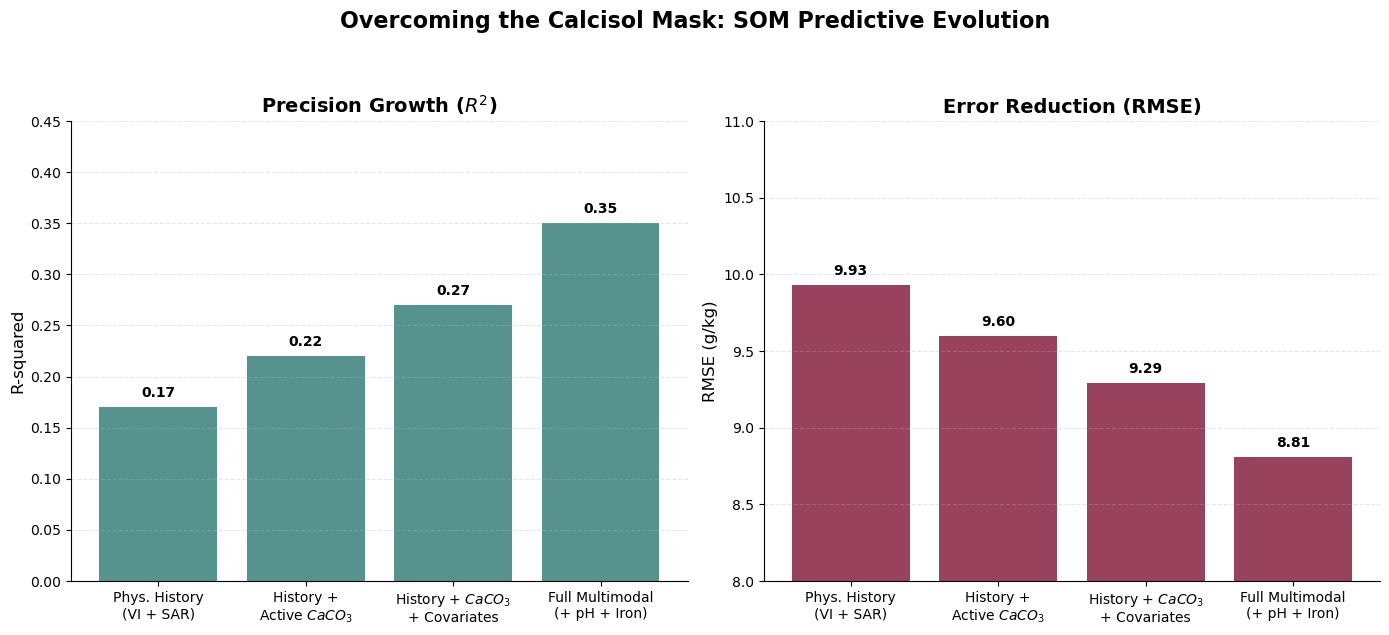

In [18]:
import matplotlib.pyplot as plt

# Data points provided for SOM evolution (organic_matter_g_kg)
models = [
    'Phys. History\n(VI + SAR)', 
    'History +\nActive $CaCO_3$', 
    'History + $CaCO_3$\n+ Covariates', 
    'Full Multimodal\n(+ pH + Iron)'
]

r2_values = [0.17, 0.22, 0.27, 0.35]
rmse_values = [9.93, 9.60, 9.29, 8.81]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R-squared Evolution
bars1 = ax1.bar(models, r2_values, color='#2c7873', alpha=0.8)
ax1.set_title('Precision Growth ($R^2$)', fontsize=14, fontweight='bold')
ax1.set_ylabel('R-squared', fontsize=12)
ax1.set_ylim(0, 0.45)

# Plot 2: RMSE Evolution
bars2 = ax2.bar(models, rmse_values, color='#801336', alpha=0.8)
ax2.set_title('Error Reduction (RMSE)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE (g/kg)', fontsize=12)
ax2.set_ylim(8, 11) # Zoomed in to show reduction clearly

# Adding data labels
for ax, bars in zip([ax1, ax2], [bars1, bars2]):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Overcoming the Calcisol Mask: SOM Predictive Evolution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

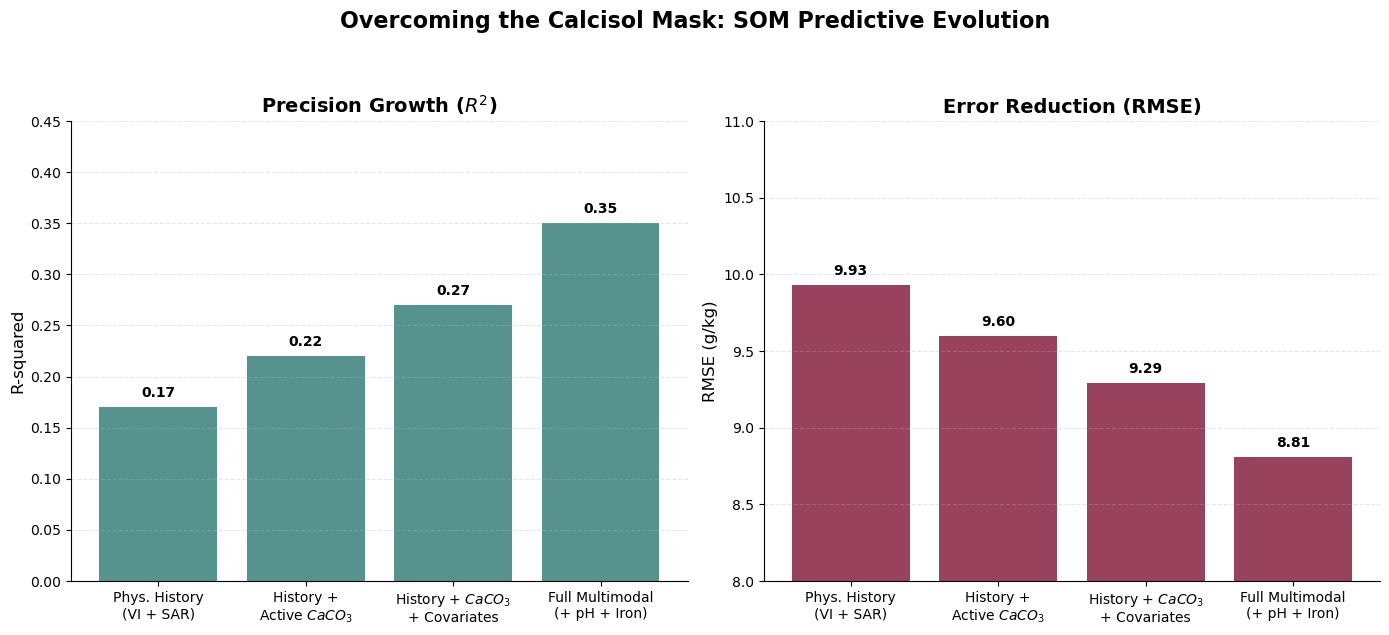

In [19]:
import matplotlib.pyplot as plt

# Metrics for organic_matter_g_kg performance evolution
models = [
    'Phys. History\n(VI + SAR)', 
    'History +\nActive $CaCO_3$', 
    'History + $CaCO_3$\n+ Covariates', 
    'Full Multimodal\n(+ pH + Iron)'
]

r2_values = [0.17, 0.22, 0.27, 0.35]
rmse_values = [9.93, 9.60, 9.29, 8.81]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R-squared Evolution
bars1 = ax1.bar(models, r2_values, color='#2c7873', alpha=0.8)
ax1.set_title('Precision Growth ($R^2$)', fontsize=14, fontweight='bold')
ax1.set_ylabel('R-squared', fontsize=12)
ax1.set_ylim(0, 0.45)

# Plot 2: RMSE Evolution
bars2 = ax2.bar(models, rmse_values, color='#801336', alpha=0.8)
ax2.set_title('Error Reduction (RMSE)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE (g/kg)', fontsize=12)
ax2.set_ylim(8, 11) 

for ax, bars in zip([ax1, ax2], [bars1, bars2]):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Overcoming the Calcisol Mask: SOM Predictive Evolution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

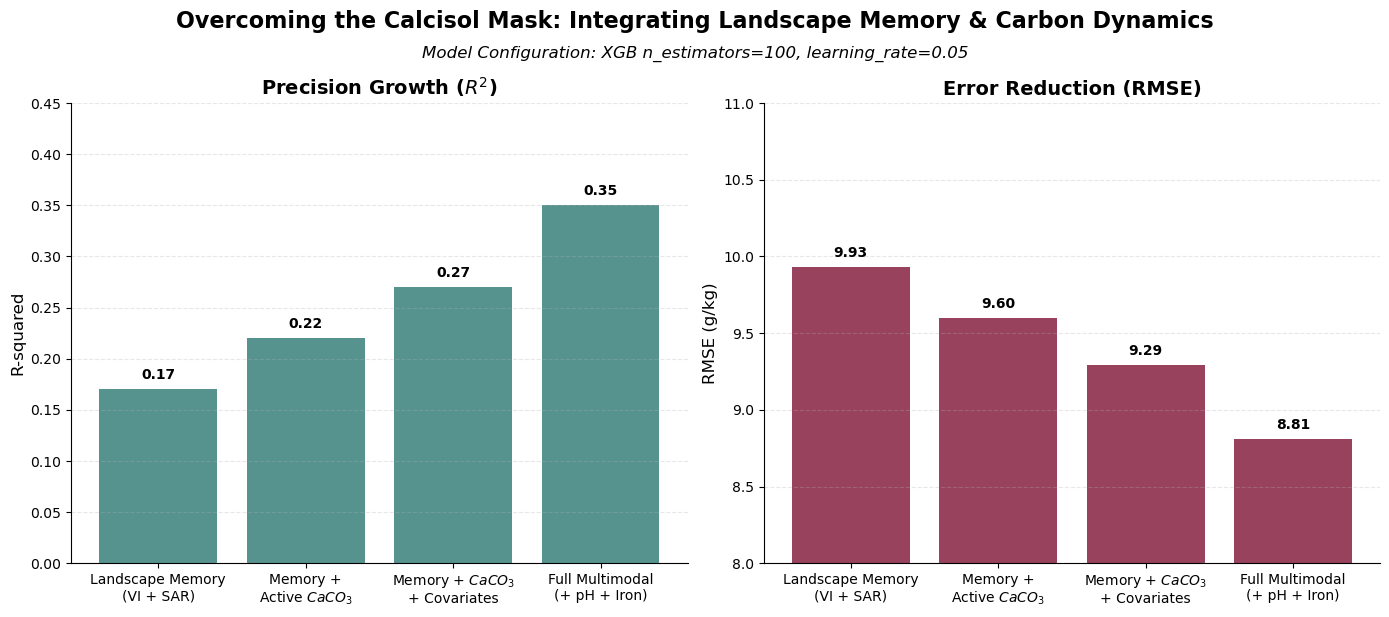

In [20]:
import matplotlib.pyplot as plt

# Metrics for organic_matter_g_kg provided by user
models = [
    'Landscape Memory\n(VI + SAR)', 
    'Memory +\nActive $CaCO_3$', 
    'Memory + $CaCO_3$\n+ Covariates', 
    'Full Multimodal\n(+ pH + Iron)'
]

r2_values = [0.17, 0.22, 0.27, 0.35]
rmse_values = [9.93, 9.60, 9.29, 8.81]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R-squared Evolution
bars1 = ax1.bar(models, r2_values, color='#2c7873', alpha=0.8)
ax1.set_title('Precision Growth ($R^2$)', fontsize=14, fontweight='bold')
ax1.set_ylabel('R-squared', fontsize=12)
ax1.set_ylim(0, 0.45)

# Plot 2: RMSE Evolution
bars2 = ax2.bar(models, rmse_values, color='#801336', alpha=0.8)
ax2.set_title('Error Reduction (RMSE)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RMSE (g/kg)', fontsize=12)
ax2.set_ylim(8, 11) 

# Adding data labels
for ax, bars in zip([ax1, ax2], [bars1, bars2]):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Title and Subtitle reflecting model parameters
plt.suptitle('Overcoming the Calcisol Mask: Integrating Landscape Memory & Carbon Dynamics', 
             fontsize=16, fontweight='bold', y=1.02)
plt.figtext(0.5, 0.94, 'Model Configuration: XGB n_estimators=100, learning_rate=0.05', 
            ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

Unique Soil Groups identified: ['Kastanozem' 'Luvisol' 'Planosol' 'Vertisol' 'Calcisol' 'Leptosol'
 'Regosol' 'Solonchak' 'Cambisol' 'Fluvisol' 'Phaeozem']


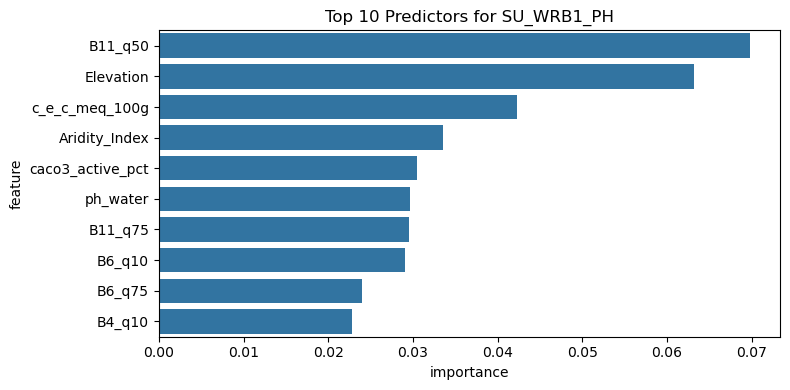

--- Train Performance ---
Accuracy: 1.0000
--- Test Performance ---
Accuracy: 0.7250

Classification Report (Test Set):
              precision    recall  f1-score   support

    Calcisol       0.79      0.80      0.79       466
    Cambisol       0.76      0.81      0.79        16
    Fluvisol       0.65      0.46      0.54        37
  Kastanozem       0.73      0.72      0.72       247
    Leptosol       0.64      0.78      0.70        55
     Luvisol       0.69      0.59      0.63       160
    Phaeozem       0.36      0.44      0.40         9
    Planosol       0.58      0.76      0.66        50
     Regosol       0.71      0.50      0.59        34
   Solonchak       0.69      0.64      0.67        14
    Vertisol       0.70      0.75      0.72       174

    accuracy                           0.73      1262
   macro avg       0.66      0.66      0.66      1262
weighted avg       0.73      0.73      0.72      1262



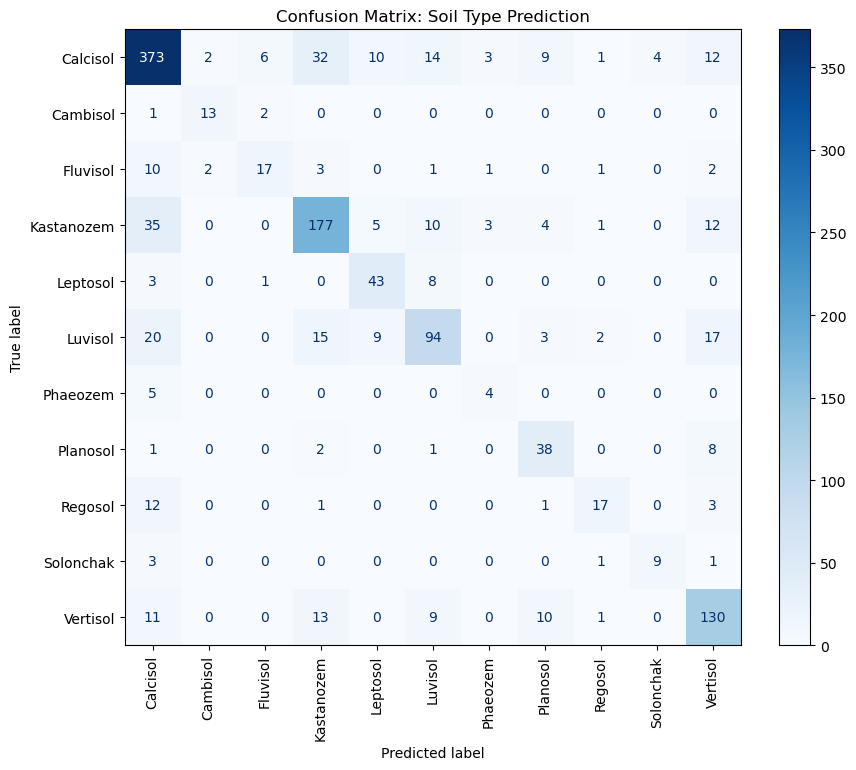

Calculating curve for max_depth...


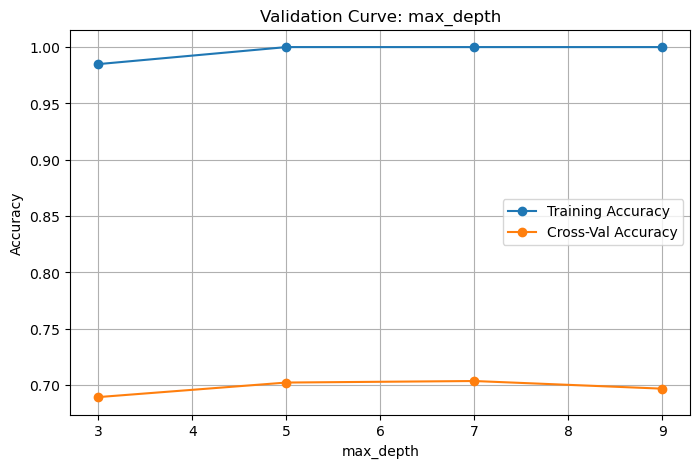

Calculating curve for learning_rate...


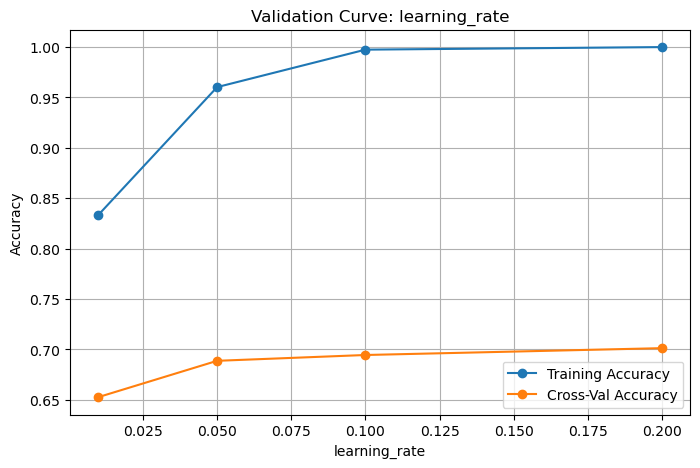

Calculating curve for n_estimators...


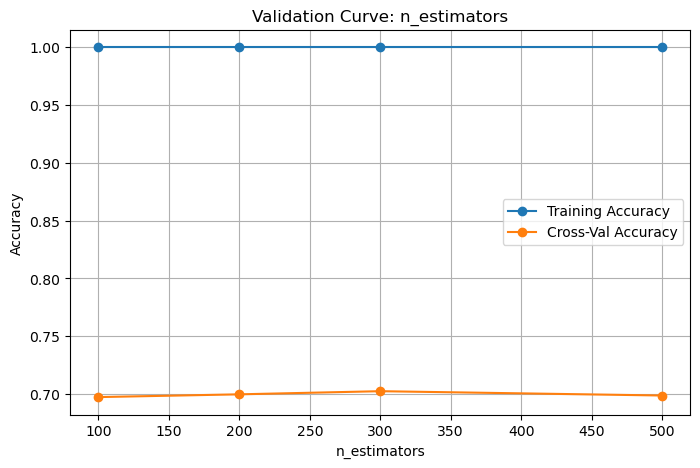

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# 1. Load Data
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features_classif.csv')

# 2. Preprocessing
# Target is now SU_WRB1_PH.
soil_map = {}
with open('../soil_groups.txt', 'r') as f:
    for line in f:
        if ':' in line:
            code, name = line.split(':')
            soil_map[code.strip().upper()] = name.strip()
target_col = 'SU_WRB1_PH'
df['SU_WRB1_PH'] = df['SU_WRB1_PH'].astype(str).str[:2].str.upper().map(soil_map)

print(f"Unique Soil Groups identified: {df['SU_WRB1_PH'].unique()}")
X = df.drop(columns=['uuid', target_col, 'organic_matter_g_kg'])
y_raw = df[target_col]

# Encode categorical labels to integers for XGBoost
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

weights = compute_sample_weight(class_weight='balanced', y=y_train)
# 3. Model Training (Classification)
# Using XGBClassifier instead of Regressor
model = xgb.XGBClassifier(
    objective='multi:softprob', 
    n_estimators=500, 
    learning_rate=0.2,
    max_depth=7,
    tree_method='hist',
    random_state=42
)
model.fit(X_train, y_train, sample_weight=weights)

# 7. Feature Importance
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x='importance', y='feature', data=importances.head(10))
plt.title(f"Top 10 Predictors for {target_col}")
plt.tight_layout()
plt.show()

# 4. Evaluation
def evaluate_classifier(model, X_set, y_set, label):
    preds = model.predict(X_set)
    acc = accuracy_score(y_set, preds)
    print(f"--- {label} Performance ---")
    print(f"Accuracy: {acc:.4f}")
    return preds

train_preds = evaluate_classifier(model, X_train, y_train, "Train")
test_preds = evaluate_classifier(model, X_test, y_test, "Test")

# Detailed Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_preds, target_names=class_names))

# 5. Confusion Matrix (Visual Trace of Performance)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=class_names, 
                                        xticks_rotation='vertical', ax=ax, cmap='Blues')
plt.title('Confusion Matrix: Soil Type Prediction')
plt.show()

# 6. Hyperparameter Exploration & Validation Curves
# Note: We use "accuracy" or "f1_weighted" for classification scoring
param_range_depth = [3, 5, 7, 9]
param_range_lr = [0.01, 0.05, 0.1, 0.2]

def plot_val_curve_clf(param_name, param_range):
    print(f"Calculating curve for {param_name}...")
    train_scores, test_scores = validation_curve(
        xgb.XGBClassifier(objective='multi:softprob', tree_method='hist'), 
        X_train, y_train, param_name=param_name, 
        param_range=param_range, cv=5, scoring="accuracy", n_jobs=-1
    )
    
    plt.figure(figsize=(8, 5))
    plt.plot(param_range, np.mean(train_scores, axis=1), label="Training Accuracy", marker='o')
    plt.plot(param_range, np.mean(test_scores, axis=1), label="Cross-Val Accuracy", marker='o')
    plt.title(f"Validation Curve: {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_val_curve_clf("max_depth", param_range_depth)
plot_val_curve_clf("learning_rate", param_range_lr)
plot_val_curve_clf("n_estimators", [100, 200, 300, 500])

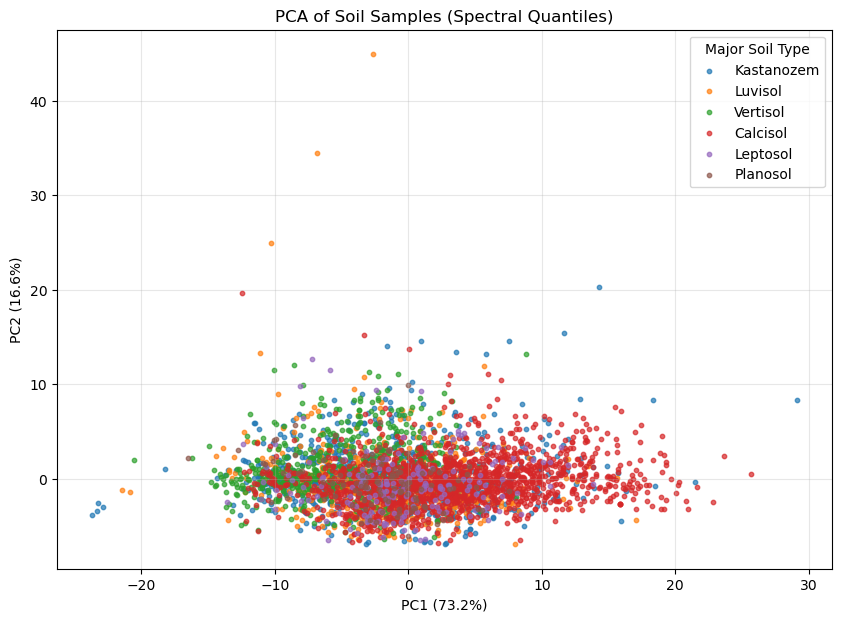

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')
df['SU_WRB1_PH'] = df['SU_WRB1_PH'].astype(str).str[:2].str.upper().map(soil_map)
df = df[df['SU_WRB1_PH'].isin(['Kastanozem', 'Luvisol', 'Planosol', 'Vertisol', 'Calcisol', 'Leptosol'])].copy()

df = df[df['ph_water'] > 6].copy()
# 1. Prepare Data
# Selecting spectral quantile columns and environmental variables
soil_attrs = [
    'sand_pct', 'clay_pct', 'total_silt_pct', 
    # 'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 
    'caco3_active_pct', 
    # 'caco3_pct_total', 'ph_water', 'c_e_c_meq_100g', 'ce_ext1_5_ms_cm', 
    # 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 'iron_ppm_dtpa',
    # 'c_n_ratio', 'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 
    # 'mgo_ppm', 'cao_ppm', 'mn_ppm_dtpa', 'cu_ppm_dtpa',   
    # 'zn_ppm_dtpa', 'b_ppm_hot_water', 'organic_matter_g_kg'
]
feature_cols = [c for c in df.columns if '_q' in c] + [c for c in df.columns if '_iqr' in c]#  + ['Aridity_Index', 'Elevation', 'Slope', 'TWI'] + soil_attrs
target_col = 'SU_WRB1_PH'

# Drop rows with missing values in these specific columns for PCA
pca_df = df[feature_cols + [target_col]].dropna()

X = pca_df[feature_cols]
y = pca_df[target_col]

# 2. Standardize (Crucial for PCA)
X_scaled = StandardScaler().fit_transform(X)

# 3. Run PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_ * 100

# 4. Visualization
plt.figure(figsize=(10, 7))
for label in y.unique():
    mask = (y == label)
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=label, alpha=0.7, s=10)

plt.xlabel(f'PC1 ({exp_var[0]:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]:.1f}%)')
plt.title('PCA of Soil Samples (Spectral Quantiles)')
plt.legend(title='Major Soil Type')
plt.grid(alpha=0.3)
plt.show()



One-Way ANOVA Results:
                    Property  F-Statistic        p-value Significant (0.05)
5                   ph_water     117.1514  3.468935e-115                Yes
6             c_e_c_meq_100g      73.4513   5.332444e-67                Yes
3           caco3_active_pct      38.3817   3.526272e-36                Yes
8       exchangeable_k2o_ppm      19.7480   1.810561e-19                Yes
9   p2o5_ehangable_olsen_ppm      18.3021   5.493526e-18                Yes
4            caco3_pct_total      17.7913   4.520029e-17                Yes
1                   clay_pct      16.9554   3.356903e-16                Yes
0                   sand_pct      14.1152   2.023963e-13                Yes
7            ce_ext1_5_ms_cm       8.7446   3.510547e-08                Yes
2             total_silt_pct       5.1759   1.052488e-04                Yes
10       organic_matter_g_kg       3.5346   3.436790e-03                Yes


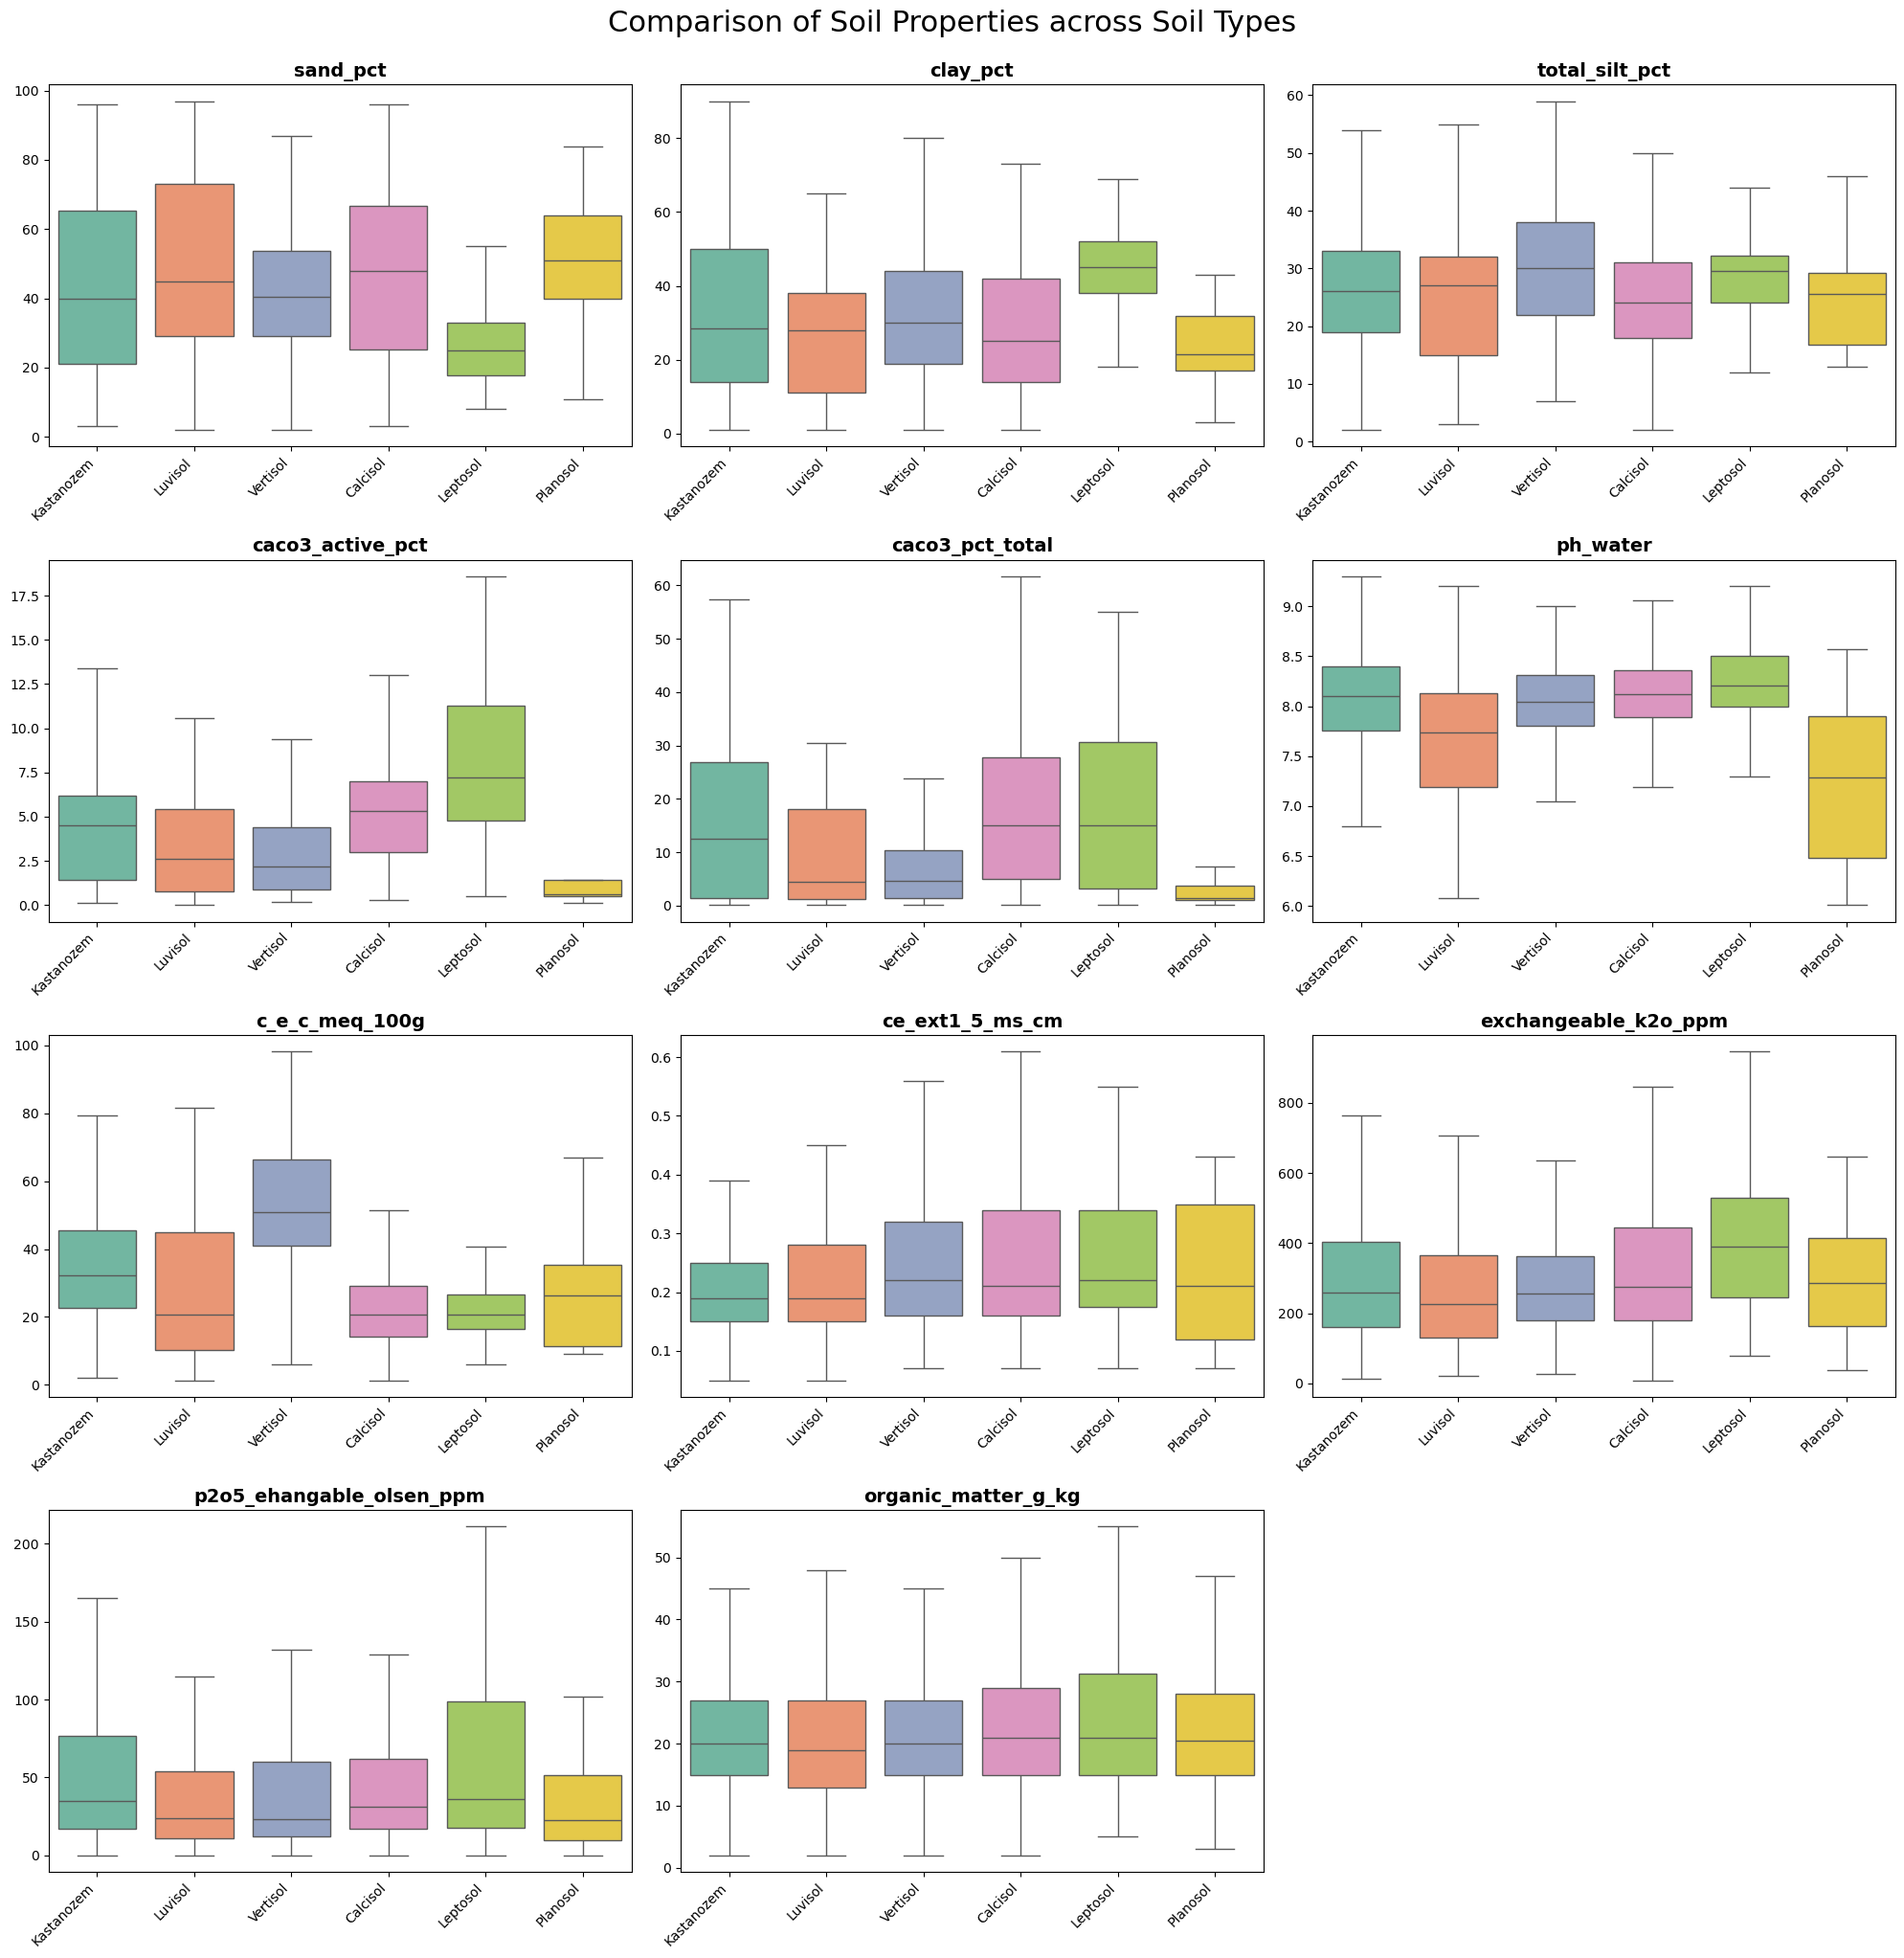

In [69]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Define the grouping column and target soil property columns
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')
df = df[df['ph_water'] > 6].copy()
df['SU_WRB1_PH'] = df['SU_WRB1_PH'].astype(str).str[:2].str.upper().map(soil_map)
df = df[df['SU_WRB1_PH'].isin(['Kastanozem', 'Luvisol', 'Planosol', 'Vertisol', 'Calcisol', 'Leptosol'])].copy()
group_col = 'SU_WRB1_PH'

# Filter out spectral/meta columns to focus only on physical/chemical properties
# We skip columns with '_q' (spectral) and basic metadata
exclude_cols = [c for c in df.columns if '_iqr' in c] + [c for c in df.columns if '_q' in c] + ['uuid', 'date', 'lon', 'lat', 'depth_from_cm', 'depth_to_cm', 'Aridity_Index', 'Elevation', 'Slope', 'TWI', group_col]
# soil_properties = [c for c in df.columns if c not in exclude_cols]
soil_properties = [
    'sand_pct', 'clay_pct', 'total_silt_pct', 
    # 'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 
    'caco3_active_pct', 'caco3_pct_total','ph_water', 'c_e_c_meq_100g', 'ce_ext1_5_ms_cm', 
    # 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 'iron_ppm_dtpa',
    # 'c_n_ratio', 
    'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 
    # 'mgo_ppm', 'cao_ppm', 'mn_ppm_dtpa', 'cu_ppm_dtpa',   
    # 'zn_ppm_dtpa', 'b_ppm_hot_water', 
    'organic_matter_g_kg'
]
# 2. Results storage
anova_results = []

for prop in soil_properties:
    # Ensure column is numeric
    if not pd.api.types.is_numeric_dtype(df[prop]):
        continue
        
    # Drop rows where property or soil type is missing
    clean_df = df[[prop, group_col]].dropna()
    
    # We need at least 2 soil types with data to run ANOVA
    if len(clean_df[group_col].unique()) < 2:
        continue
        
    # Group the property values by soil type
    groups = [group[prop].values for name, group in clean_df.groupby(group_col)]
    
    # Perform One-Way ANOVA
    try:
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({
            'Property': prop,
            'F-Statistic': round(f_stat, 4),
            'p-value': p_val,
            'Significant (0.05)': 'Yes' if p_val < 0.05 else 'No'
        })
    except:
        continue

# 3. Compile and sort results (most significant differences at the top)
anova_summary = pd.DataFrame(anova_results).sort_values('p-value')

# Display top 10 most differentiating soil properties
print("One-Way ANOVA Results:")
print(anova_summary)

# 2. Setup the grid (4 columns per row)
n_props = len(soil_properties)
cols = 3
rows = math.ceil(n_props / cols)

# 3. Create the multi-panel figure
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 4. Loop through properties and create boxplots
for i, prop in enumerate(soil_properties):
    sns.boxplot(ax=axes[i], x=group_col, y=prop, data=df, hue=group_col, palette='Set2', showfliers=False, legend=False)
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f'{prop}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
# 5. Clean up: Remove any unused empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Comparison of Soil Properties across Soil Types', fontsize=22, y=1.02)
plt.show()
# Optional: Save results to a CSV
# anova_summary.to_csv('soil_anova_results.csv', index=False)

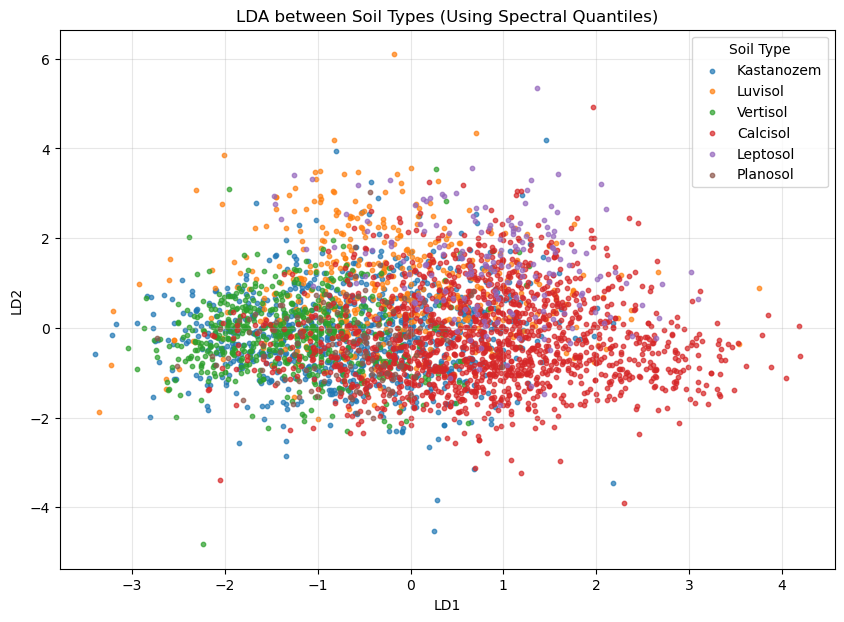

Top 10 features defining the soil type separation:
         Importance
B8A_q10    3.673422
B6_q10     2.760709
B5_q10     2.496230
B7_q50     2.366255
B5_q50     2.277607
B4_q10     2.260343
B4_q50     2.095511
B7_q25     2.078403
B7_q75     2.006537
B8_q10     1.382348


In [68]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Reuse the scaled data from the PCA step or prepare fresh
# (Using the same X_scaled and y from Cell 1)

# 2. Run LDA
lda = LinearDiscriminantAnalysis(n_components=5)
lda_results = lda.fit_transform(X_scaled, y)

# 3. Visualization
plt.figure(figsize=(10, 7))
for label in y.unique():
    mask = (y == label)
    plt.scatter(lda_results[mask, 0], lda_results[mask, 1], label=label, alpha=0.7, s=10)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA between Soil Types (Using Spectral Quantiles)')
plt.legend(title='Soil Type')
plt.grid(alpha=0.3)
plt.show()

# 4. Insights: Print top contributing features for LD1
coef_df = pd.DataFrame(abs(lda.coef_[0]), index=feature_cols, columns=['Importance'])
print("Top 10 features defining the soil type separation:")
print(coef_df.sort_values(by='Importance', ascending=False).head(10))

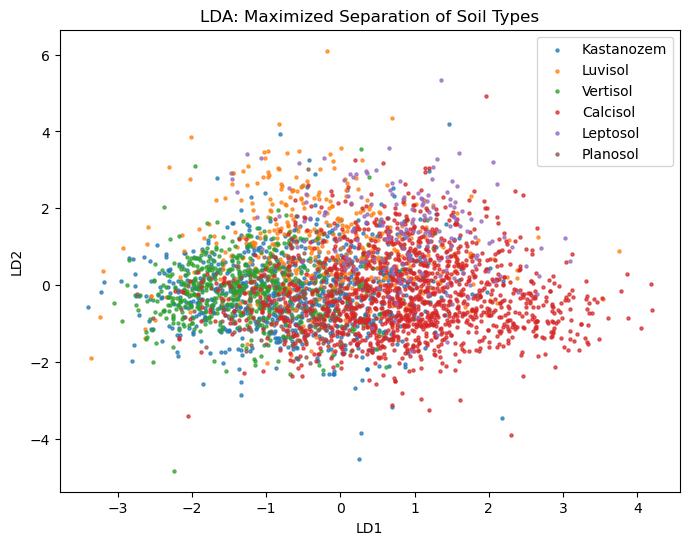

Top 10 Variables for Soil Differentiation:
           Weight
B8A_q10  3.673422
B6_q10   2.760709
B5_q10   2.496230
B7_q50   2.366255
B5_q50   2.277607
B4_q10   2.260343
B4_q50   2.095511
B7_q25   2.078403
B7_q75   2.006537
B8_q10   1.382348


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
lda_res = lda.fit_transform(X_scaled, pca_df[target_col])

plt.figure(figsize=(8, 6))
for label in pca_df[target_col].unique():
    mask = (pca_df[target_col] == label)
    plt.scatter(lda_res[mask, 0], lda_res[mask, 1], label=label, alpha=0.7, s=5)
plt.title('LDA: Maximized Separation of Soil Types')
plt.xlabel('LD1'); plt.ylabel('LD2'); plt.legend()
plt.show()

# Top features for separation
importance = pd.DataFrame(abs(lda.coef_[0]), index=feature_cols, columns=['Weight'])
print("Top 5 Variables for Soil Differentiation:")
print(importance.sort_values('Weight', ascending=False).head(10))

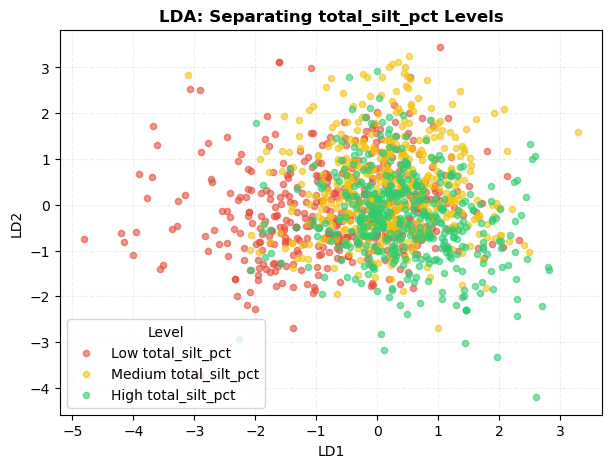

--- Top 5 Predictors for total_silt_pct ---
        Importance
B6_q50    3.203553
B7_q10    2.536389
B8_q50    2.503870
B7_q75    1.890912
B7_q25    1.785515




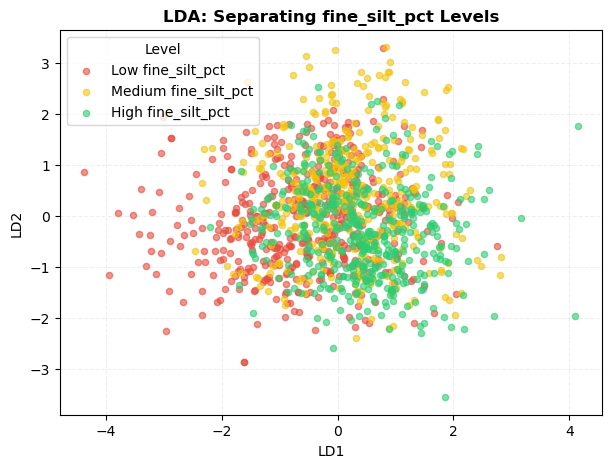

--- Top 5 Predictors for fine_silt_pct ---
        Importance
B6_q50    4.276740
B7_q25    3.375098
B7_q75    3.351403
B5_q50    3.326570
B6_q90    1.683042




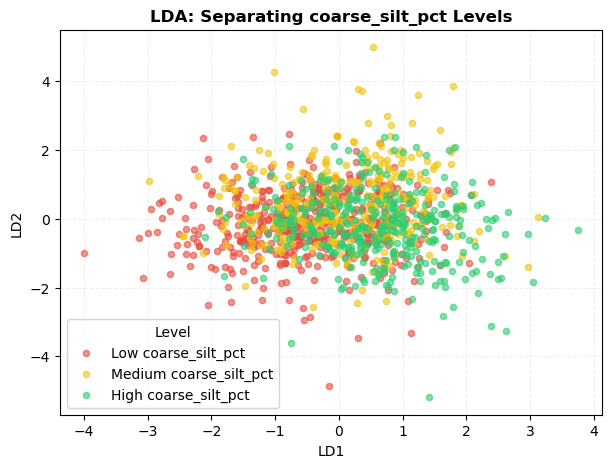

--- Top 5 Predictors for coarse_silt_pct ---
         Importance
B8_q50     3.378324
B7_q10     2.930066
B3_q50     2.886368
B8A_q50    2.701356
B8A_q10    2.676803




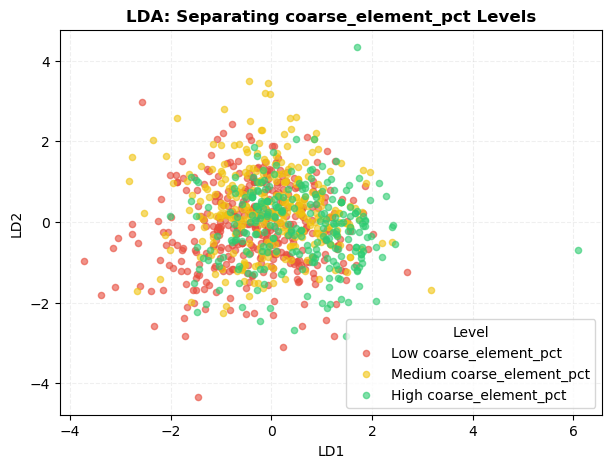

--- Top 5 Predictors for coarse_element_pct ---
         Importance
B7_q50     3.718983
B6_q50     2.957109
B8A_q50    2.305978
B5_q50     2.215721
B3_q50     2.190494




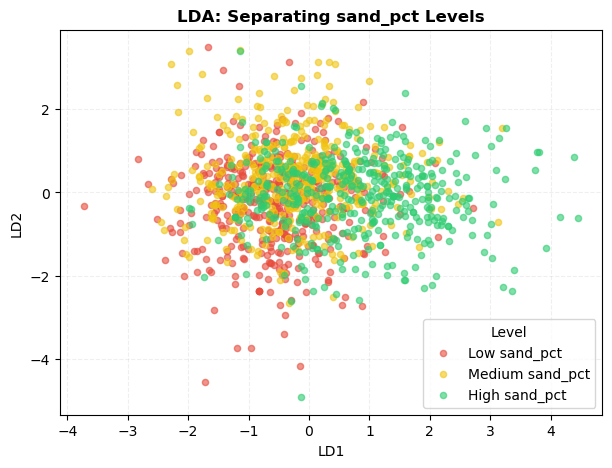

--- Top 5 Predictors for sand_pct ---
         Importance
B5_q50     4.134461
B7_q10     3.598188
B8_q50     3.116835
B3_q50     2.841414
B8A_q10    2.726045




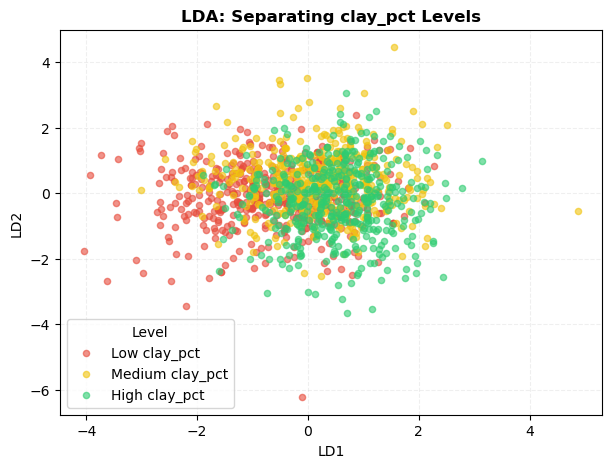

--- Top 5 Predictors for clay_pct ---
         Importance
B4_q50     2.748522
B8_q50     2.522993
B6_q90     2.476588
B8A_q50    2.334785
B5_q50     2.322087




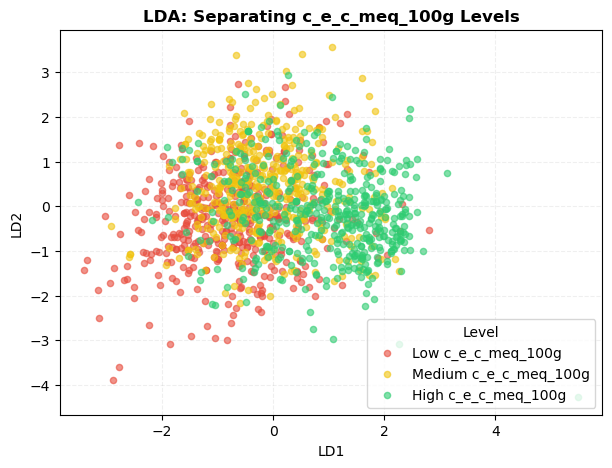

--- Top 5 Predictors for c_e_c_meq_100g ---
        Importance
B6_q50    4.461474
B7_q25    3.092061
B7_q75    3.003473
B6_q10    2.675975
B5_q10    2.599366




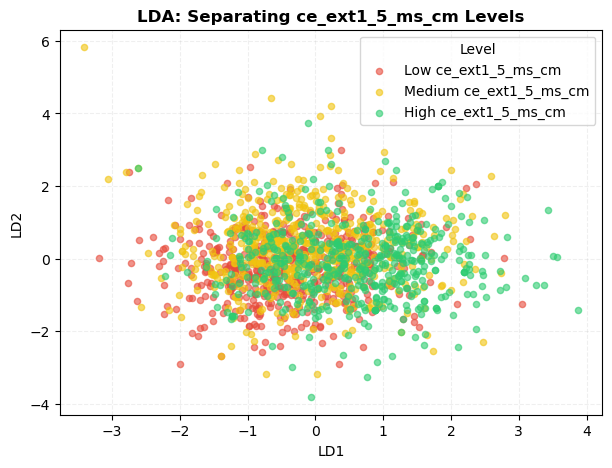

--- Top 5 Predictors for ce_ext1_5_ms_cm ---
         Importance
B7_q90     3.283897
B8A_q90    2.226331
B6_q50     2.198586
B5_q90     2.190742
B8_q90     1.901006




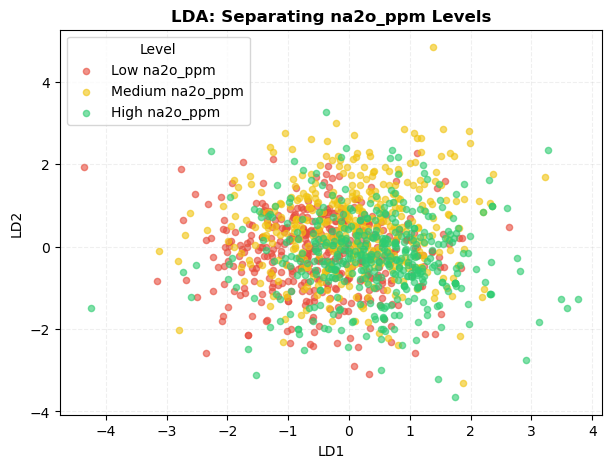

--- Top 5 Predictors for na2o_ppm ---
         Importance
B7_q90     3.344870
B4_q90     3.211277
B8A_q50    2.673402
B5_q90     2.589146
B7_q10     2.322161




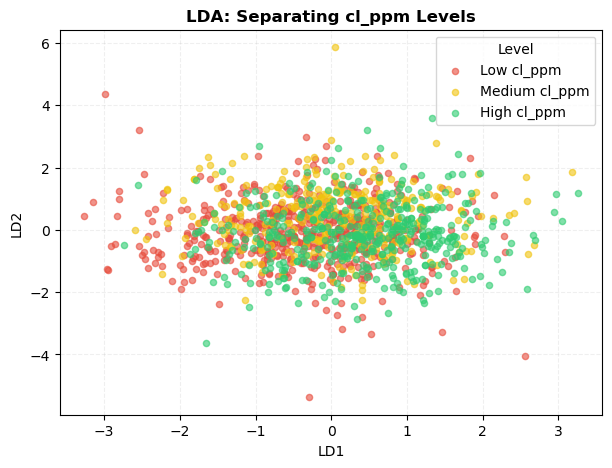

--- Top 5 Predictors for cl_ppm ---
        Importance
B6_q50    3.078557
B7_q50    2.820098
B6_q90    2.635841
B6_q25    2.523792
B6_q75    2.501397




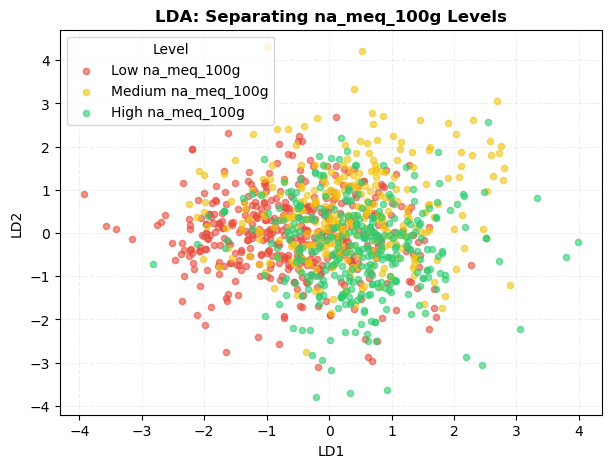

--- Top 5 Predictors for na_meq_100g ---
        Importance
B7_q90    3.626419
B5_q90    2.927289
B6_q75    2.803015
B6_q25    2.759641
B4_q90    2.728730




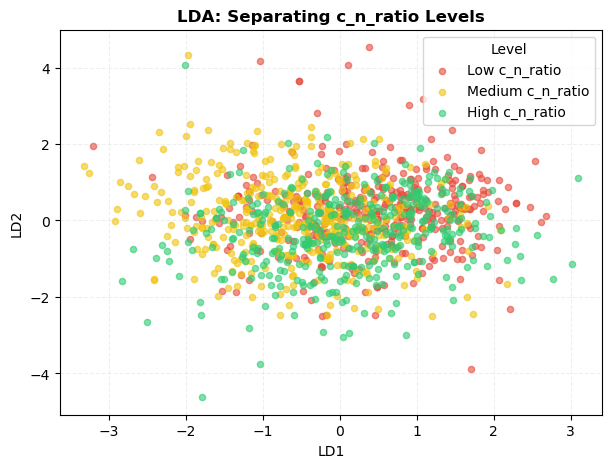

--- Top 5 Predictors for c_n_ratio ---
         Importance
B7_q10     3.040175
B7_q50     2.980424
B8_q50     2.920846
B8A_q50    2.614549
B8A_q10    2.177747




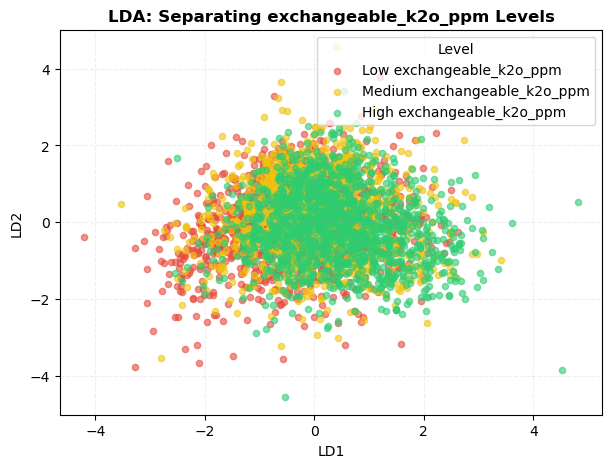

--- Top 5 Predictors for exchangeable_k2o_ppm ---
         Importance
B7_q10     1.933307
B4_q50     1.407959
B8A_q10    1.250709
B6_q50     1.244397
B7_q75     1.206469




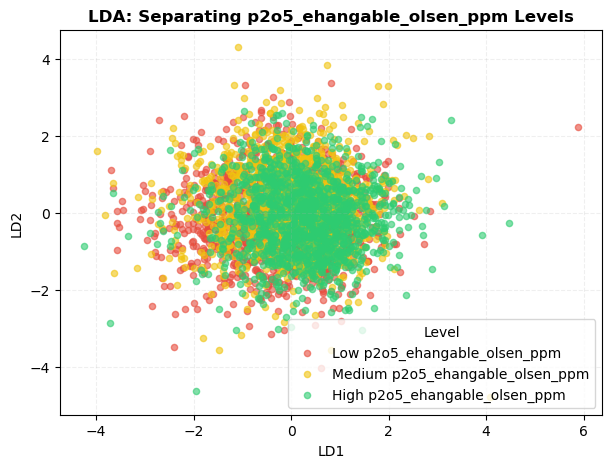

--- Top 5 Predictors for p2o5_ehangable_olsen_ppm ---
        Importance
B6_q50    2.519086
B7_q50    2.211456
B7_q90    1.686594
B5_q50    1.310754
B7_q25    1.206806




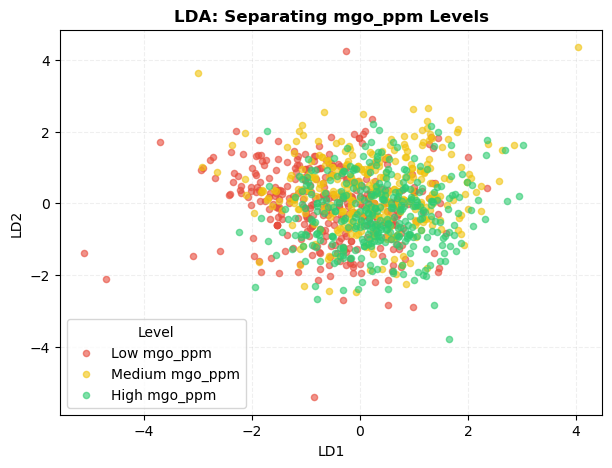

--- Top 5 Predictors for mgo_ppm ---
         Importance
B8A_q50    1.948220
B4_q50     1.794708
B8A_q10    1.756850
B6_q50     1.725214
B4_q25     1.608527




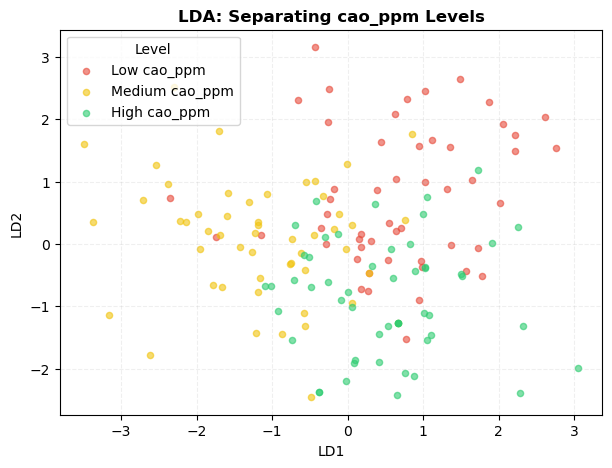

--- Top 5 Predictors for cao_ppm ---
         Importance
B7_q50    15.023754
B8A_q50   13.030486
B8A_q90    8.616241
B7_q10     7.516563
B8_q50     7.087636




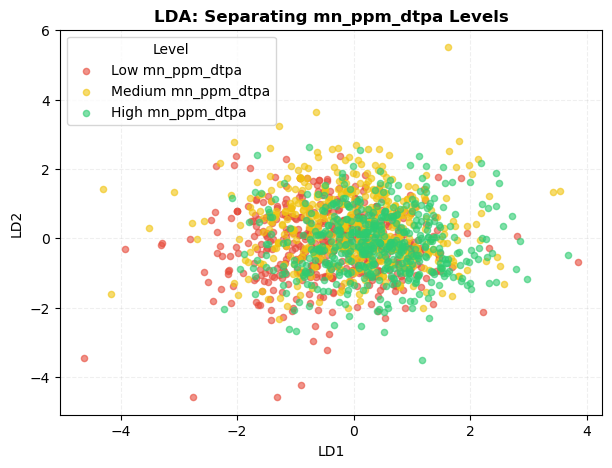

--- Top 5 Predictors for mn_ppm_dtpa ---
         Importance
B4_q50     1.905453
B8_q90     1.787408
B8A_q90    1.740669
B7_q10     1.687860
B5_q50     1.509541




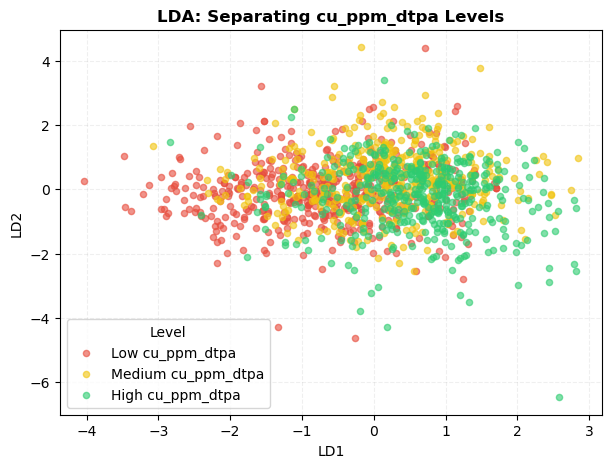

--- Top 5 Predictors for cu_ppm_dtpa ---
         Importance
B7_q50     4.194741
B8A_q50    3.210073
B6_q50     3.153085
B7_q90     2.460163
B5_q50     2.263043




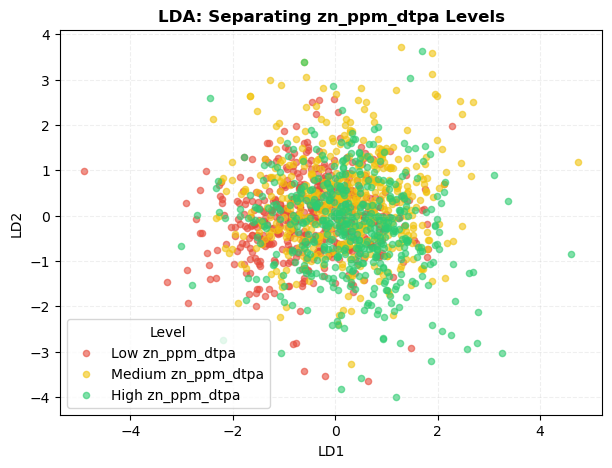

--- Top 5 Predictors for zn_ppm_dtpa ---
         Importance
B6_q50     2.725880
B8A_q10    2.371687
B7_q50     1.956894
B7_q75     1.931521
B7_q25     1.718985




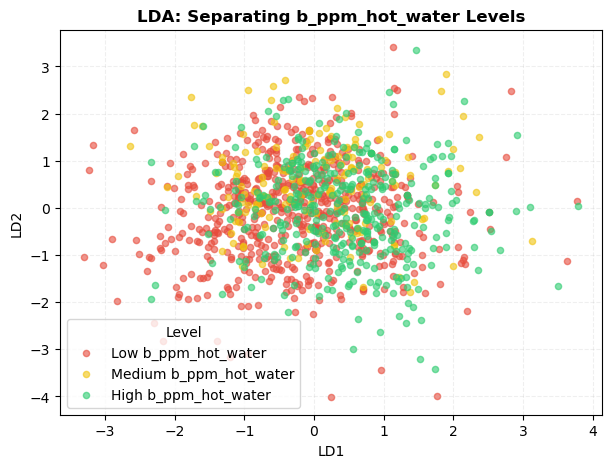

--- Top 5 Predictors for b_ppm_hot_water ---
         Importance
B8A_q50    3.584308
B8_q50     3.386664
B7_q10     3.234869
B5_q50     2.331021
B8_q10     1.709269




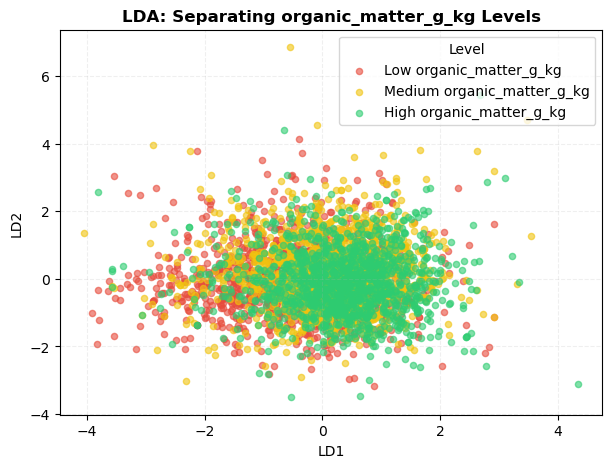

--- Top 5 Predictors for organic_matter_g_kg ---
         Importance
B7_q50     3.601613
B8A_q50    1.933779
B6_q50     1.546213
B6_q25     1.518633
B7_q10     1.466813




In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')
df = df[df['ph_water'] > 6].copy()
# List of all targets to loop over
targets_to_loop = [
    'total_silt_pct', 'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 
    'sand_pct', 'clay_pct', 
    # 'caco3_active_pct', 
    # 'caco3_pct_total',
    # 'ph_water', 
    # 'iron_ppm_dtpa',
    'c_e_c_meq_100g', 'ce_ext1_5_ms_cm', 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 
    'c_n_ratio', 'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 
    'mgo_ppm', 'cao_ppm', 'mn_ppm_dtpa', 'cu_ppm_dtpa',   
    'zn_ppm_dtpa', 'b_ppm_hot_water', 'organic_matter_g_kg'
]

# 1. Define the features (spectral & environmental)
feature_cols = [c for c in df.columns if '_q' in c] + [c for c in df.columns if '_iqr' in c]

# 3. Define colors for consistency
colors_map = {'Low': '#e74c3c', 'Medium': '#f1c40f', 'High': '#2ecc71'}

for target in targets_to_loop:
    # Prepare temporary data
    analysis_df = df[feature_cols + [target]].dropna()
    
    # Check if we have enough samples
    if len(analysis_df) < 20:
        print(f"Skipping {target}: Not enough data.")
        continue
        
    # Bin the continuous values into 3 levels
    try:
        analysis_df['binned'] = pd.qcut(analysis_df[target], q=3, labels=["Low", "Medium", "High"])
    except ValueError:
        # Handle cases with too many identical values (common in some soil data)
        print(f"Skipping {target}: Could not create equal-sized bins.")
        continue

    # Standardize Features
    X_scaled = StandardScaler().fit_transform(analysis_df[feature_cols])
    y = analysis_df['binned']

    # Run LDA (n_components=2 for 3 categories)
    lda = LinearDiscriminantAnalysis(n_components=2)
    lda_res = lda.fit_transform(X_scaled, y)

    # Visualization
    plt.figure(figsize=(7, 5))
    for level in ["Low", "Medium", "High"]:
        mask = (y == level)
        plt.scatter(
            lda_res[mask, 0], 
            lda_res[mask, 1], 
            label=f"{level} {target}", 
            alpha=0.6, 
            s=20, 
            c=colors_map[level]
        )

    plt.title(f'LDA: Separating {target} Levels', fontsize=12, fontweight='bold')
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.legend(title="Level", loc='best')
    plt.grid(alpha=0.2, linestyle='--')
    plt.show()

    # Feature Importance
    importance = pd.DataFrame(
        np.abs(lda.coef_).mean(axis=0), 
        index=feature_cols, 
        columns=['Importance']
    ).sort_values('Importance', ascending=False).head(5)
    
    print(f"--- Top 5 Predictors for {target} ---")
    print(importance)
    print("\n" + "="*40 + "\n")

In [81]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

# 1. Define the grouping column and target soil property columns
df = pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')
df = df[df['ph_water'] > 6].copy()
df['SU_WRB1_PH'] = df['SU_WRB1_PH'].astype(str).str[:2].str.upper().map(soil_map)
df = df[df['SU_WRB1_PH'].isin(['Kastanozem', 'Luvisol', 'Planosol', 'Vertisol', 'Calcisol', 'Leptosol'])].copy()
group_col = 'SU_WRB1_PH'
# 2. Loop through properties and run Tukey
tukey_summary = []
group_col = 'SU_WRB1_PH'

for prop in soil_properties:
    clean = df[[prop, group_col]].dropna()
    
    # Only run if ANOVA is significant (p < 0.05)
    groups = [g[prop].values for n, g in clean.groupby(group_col)]
    if len(groups) < 2: continue
    _, p_anova = stats.f_oneway(*groups)
    
    if p_anova < 0.05:
        tukey = pairwise_tukeyhsd(endog=clean[prop], groups=clean[group_col], alpha=0.05)
        # Convert Tukey results to a DataFrame
        res_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        res_df['Property'] = prop
        tukey_summary.append(res_df)

# 3. Combine and filter for significant differences only
if tukey_summary:
    all_results = pd.concat(tukey_summary)
    significant_results = all_results[all_results['reject'] == True]
    to_print = significant_results[['Property', 'group1', 'group2', 'meandiff', 'p-adj']].sort_values(by=['Property', 'p-adj'])
    print("Significant Pairwise Differences:")
    print(to_print.head(20)) # Show top 20 significant differences

Significant Pairwise Differences:
            Property      group1      group2  meandiff   p-adj
0     c_e_c_meq_100g    Calcisol  Kastanozem   11.0094  0.0000
4     c_e_c_meq_100g    Calcisol    Vertisol   28.6896  0.0000
5     c_e_c_meq_100g  Kastanozem    Leptosol  -13.2746  0.0000
8     c_e_c_meq_100g  Kastanozem    Vertisol   17.6802  0.0000
11    c_e_c_meq_100g    Leptosol    Vertisol   30.9548  0.0000
13    c_e_c_meq_100g     Luvisol    Vertisol   23.1133  0.0000
14    c_e_c_meq_100g    Planosol    Vertisol   24.1992  0.0000
9     c_e_c_meq_100g    Leptosol     Luvisol    7.8416  0.0042
2     c_e_c_meq_100g    Calcisol     Luvisol    5.5764  0.0126
6     c_e_c_meq_100g  Kastanozem     Luvisol   -5.4331  0.0268
1   caco3_active_pct    Calcisol    Leptosol    2.7904  0.0000
2   caco3_active_pct    Calcisol     Luvisol   -2.0170  0.0000
4   caco3_active_pct    Calcisol    Vertisol   -2.8349  0.0000
5   caco3_active_pct  Kastanozem    Leptosol    3.9513  0.0000
8   caco3_active_pct 

In [1]:
import pandas as pd
df_ok= pd.read_csv('/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/Morocco_roadsafe_6k_with_ts_features.csv')

In [6]:
df_ok_pre2017 = df_ok.copy()
df_ok_pre2017['date'] = pd.to_datetime(df_ok_pre2017['date'], format='%Y/%m/%d', errors='coerce')
df_ok_pre2017 = df_ok_pre2017[df_ok_pre2017['date'] < pd.Timestamp('2017-01-01')].copy()

print(df_ok_pre2017.shape)
df_ok_pre2017['date'].count()

(2561, 97)


np.int64(2561)

In [7]:
target_cols = [
    'total_silt_pct', 'fine_silt_pct', 'coarse_silt_pct', 'coarse_element_pct', 
    'sand_pct', 'clay_pct', 
    'caco3_active_pct', 
    'caco3_pct_total',
    'ph_water', 
    'iron_ppm_dtpa',
    'c_e_c_meq_100g', 'ce_ext1_5_ms_cm', 'na2o_ppm', 'cl_ppm', 'na_meq_100g', 
    'c_n_ratio', 'exchangeable_k2o_ppm', 'p2o5_ehangable_olsen_ppm', 
    'mgo_ppm', 'cao_ppm', 'mn_ppm_dtpa', 'cu_ppm_dtpa',   
    'zn_ppm_dtpa', 'b_ppm_hot_water', 'organic_matter_g_kg'
]

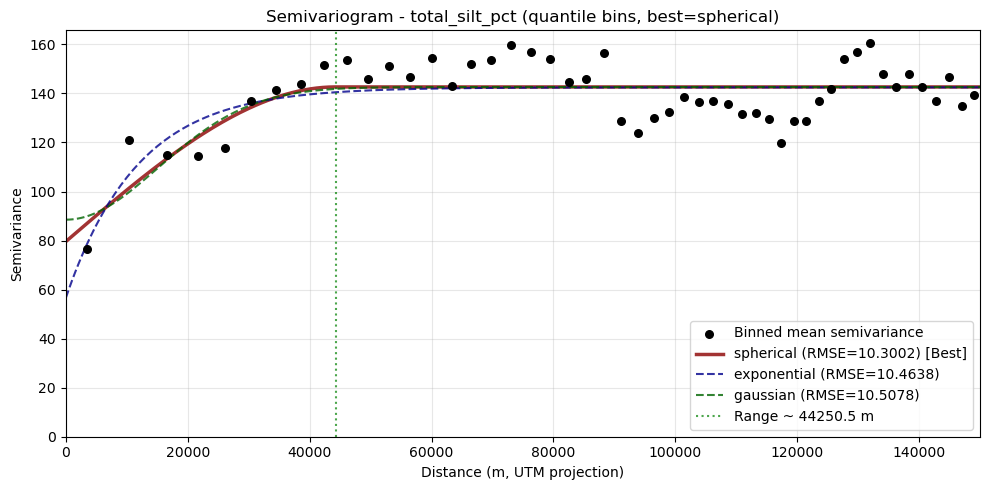

[total_silt_pct] n=1378 | CRS=EPSG:32629 | model=spherical | nugget=79.6231, sill=142.6562, range=44250.5 m | fit_RMSE=10.3002, krig_RMSE=1.9460, R2=0.9736


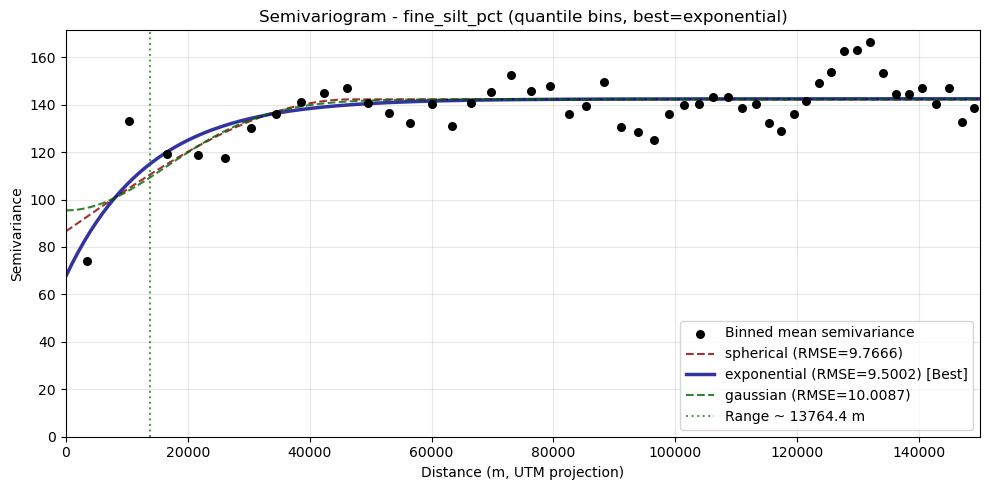

[fine_silt_pct] n=1378 | CRS=EPSG:32629 | model=exponential | nugget=67.6883, sill=142.4807, range=13764.4 m | fit_RMSE=9.5002, krig_RMSE=1.4545, R2=0.9848


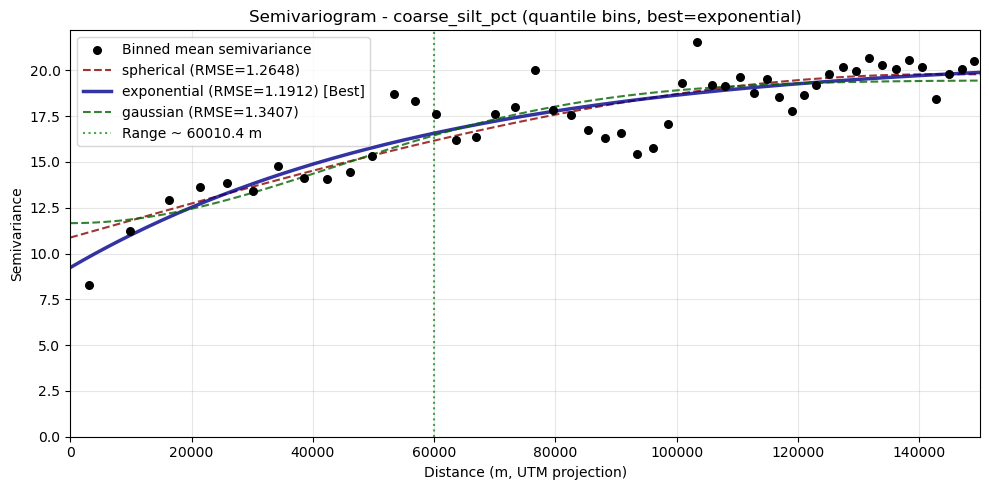

[coarse_silt_pct] n=1226 | CRS=EPSG:32629 | model=exponential | nugget=9.2332, sill=20.8395, range=60010.4 m | fit_RMSE=1.1912, krig_RMSE=0.3658, R2=0.9934


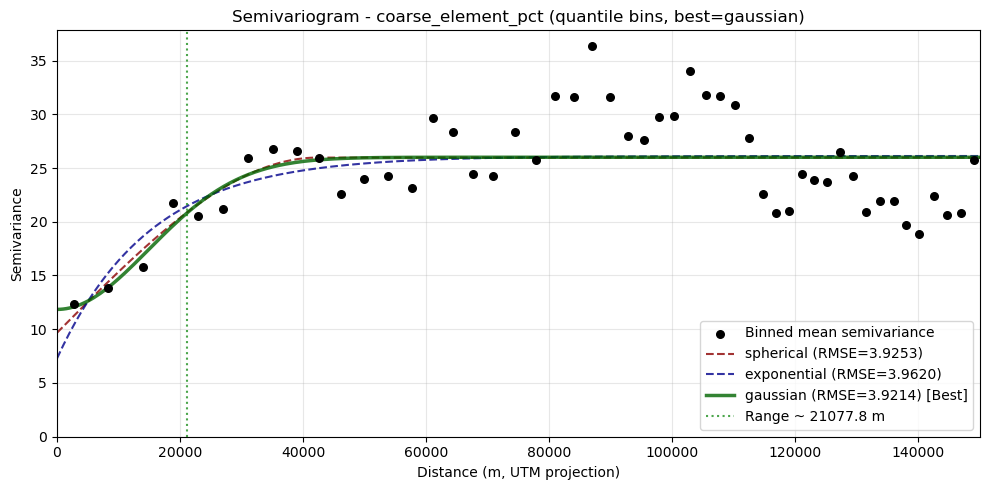

[coarse_element_pct] n=950 | CRS=EPSG:32629 | model=gaussian | nugget=11.8456, sill=26.0010, range=21077.8 m | fit_RMSE=3.9214, krig_RMSE=1.0155, R2=0.9544


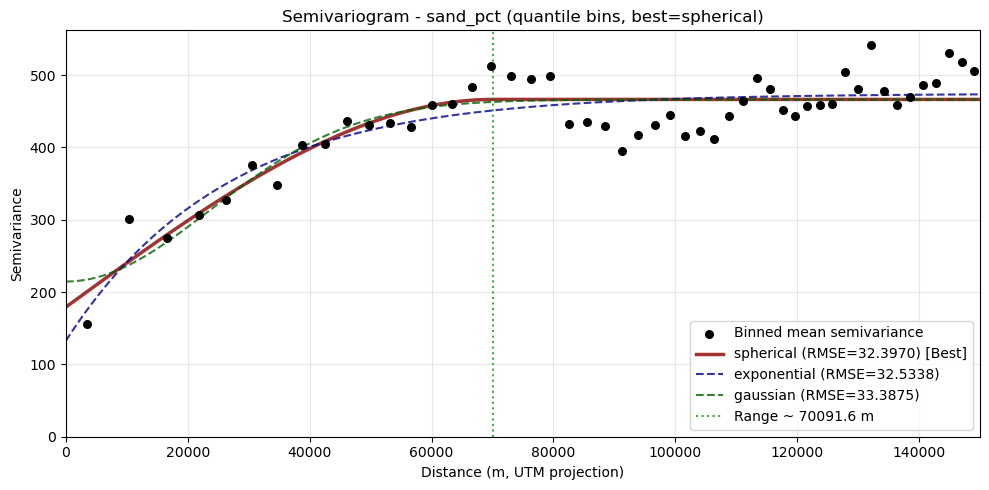

[sand_pct] n=1355 | CRS=EPSG:32629 | model=spherical | nugget=179.2478, sill=466.2454, range=70091.6 m | fit_RMSE=32.3970, krig_RMSE=2.5680, R2=0.9891


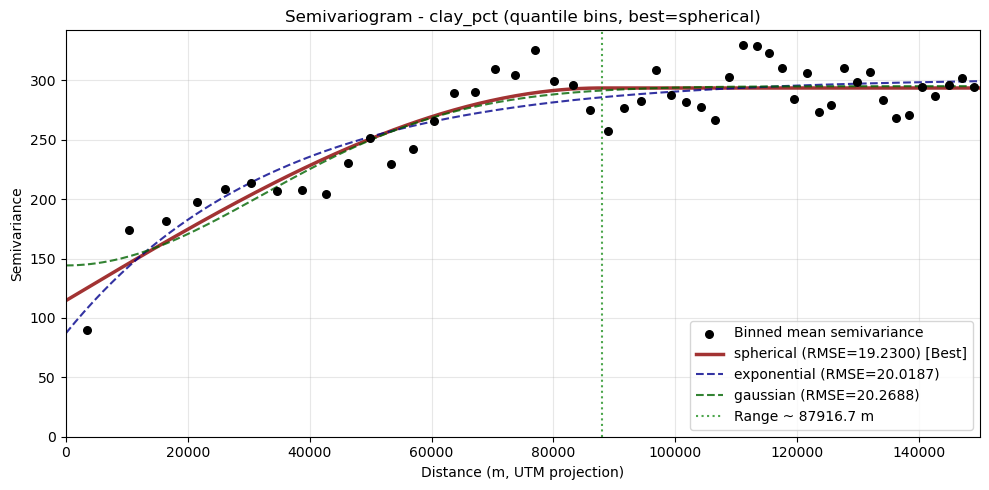

[clay_pct] n=1351 | CRS=EPSG:32629 | model=spherical | nugget=114.6367, sill=293.6599, range=87916.7 m | fit_RMSE=19.2300, krig_RMSE=2.1075, R2=0.9865


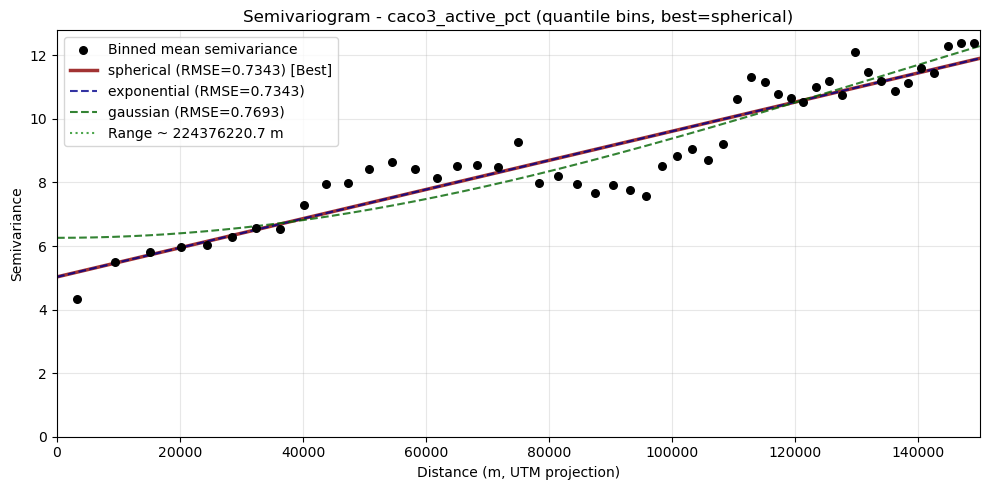

[caco3_active_pct] n=1209 | CRS=EPSG:32629 | model=spherical | nugget=5.0296, sill=6864.2235, range=224376220.7 m | fit_RMSE=0.7343, krig_RMSE=0.4484, R2=0.9840


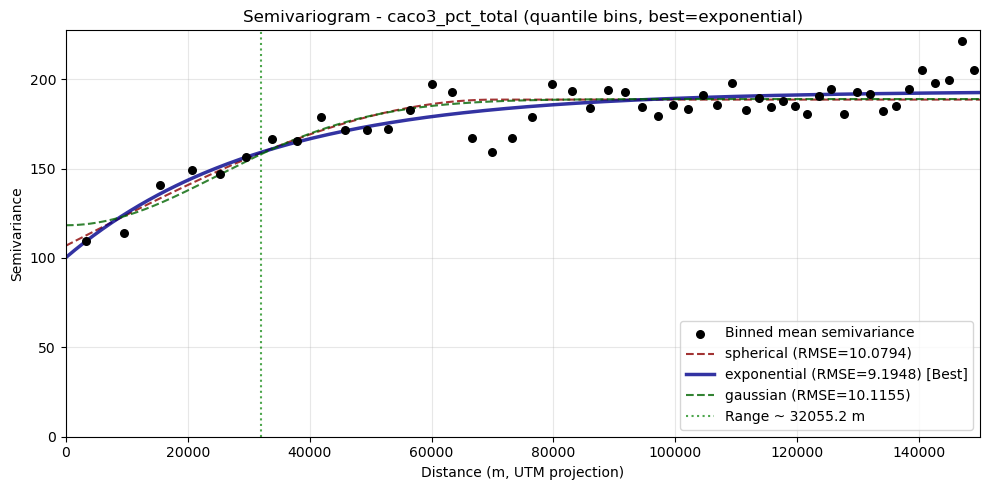

[caco3_pct_total] n=1482 | CRS=EPSG:32629 | model=exponential | nugget=100.2485, sill=193.3571, range=32055.2 m | fit_RMSE=9.1948, krig_RMSE=1.4127, R2=0.9894


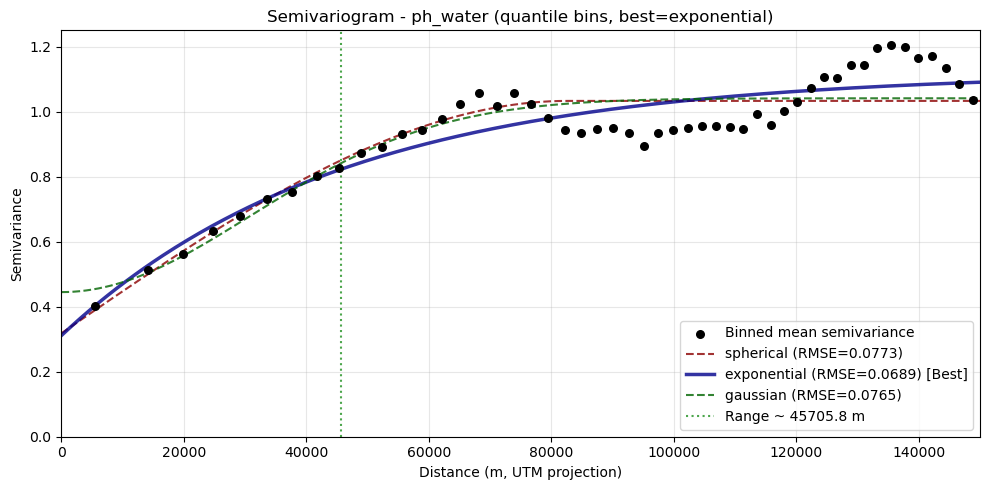

[ph_water] n=4206 | CRS=EPSG:32629 | model=exponential | nugget=0.3112, sill=1.1206, range=45705.8 m | fit_RMSE=0.0689, krig_RMSE=0.0452, R2=0.9977


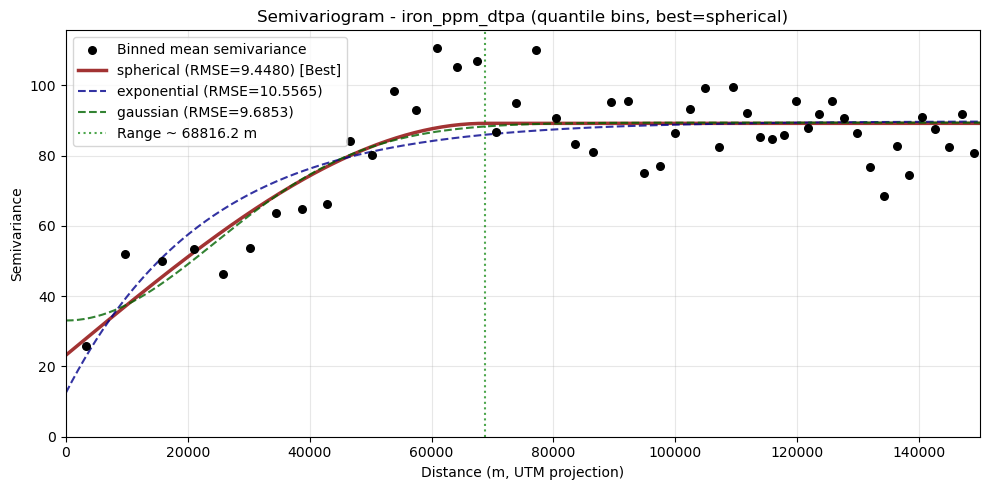

[iron_ppm_dtpa] n=1502 | CRS=EPSG:32629 | model=spherical | nugget=23.1967, sill=89.1488, range=68816.2 m | fit_RMSE=9.4480, krig_RMSE=0.4965, R2=0.9973


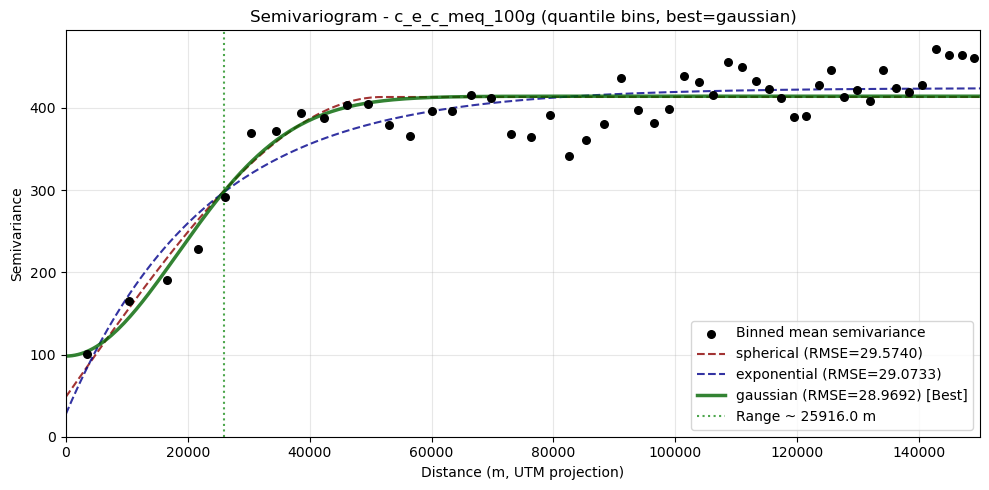

[c_e_c_meq_100g] n=1381 | CRS=EPSG:32629 | model=gaussian | nugget=98.1234, sill=414.1566, range=25916.0 m | fit_RMSE=28.9692, krig_RMSE=2.4615, R2=0.9838


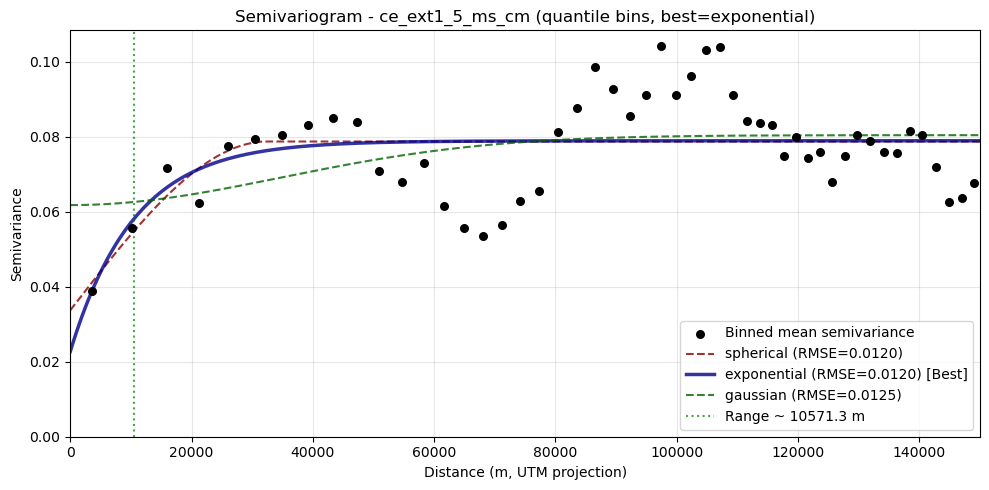

[ce_ext1_5_ms_cm] n=1649 | CRS=EPSG:32629 | model=exponential | nugget=0.0227, sill=0.0789, range=10571.3 m | fit_RMSE=0.0120, krig_RMSE=0.0657, R2=0.9570


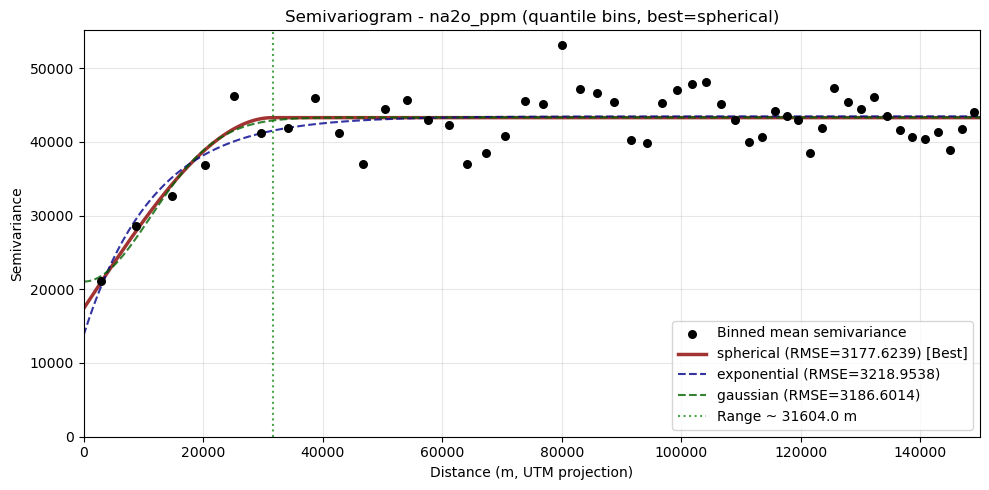

[na2o_ppm] n=1261 | CRS=EPSG:32629 | model=spherical | nugget=17386.6379, sill=43276.9562, range=31604.0 m | fit_RMSE=3177.6239, krig_RMSE=18.5130, R2=0.9920


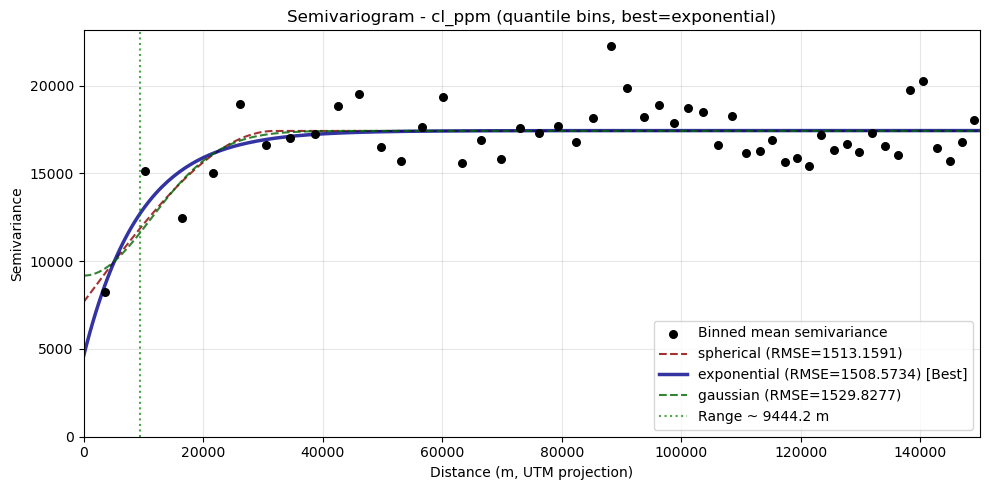

[cl_ppm] n=1360 | CRS=EPSG:32629 | model=exponential | nugget=4601.2951, sill=17439.1920, range=9444.2 m | fit_RMSE=1508.5734, krig_RMSE=18.9551, R2=0.9817


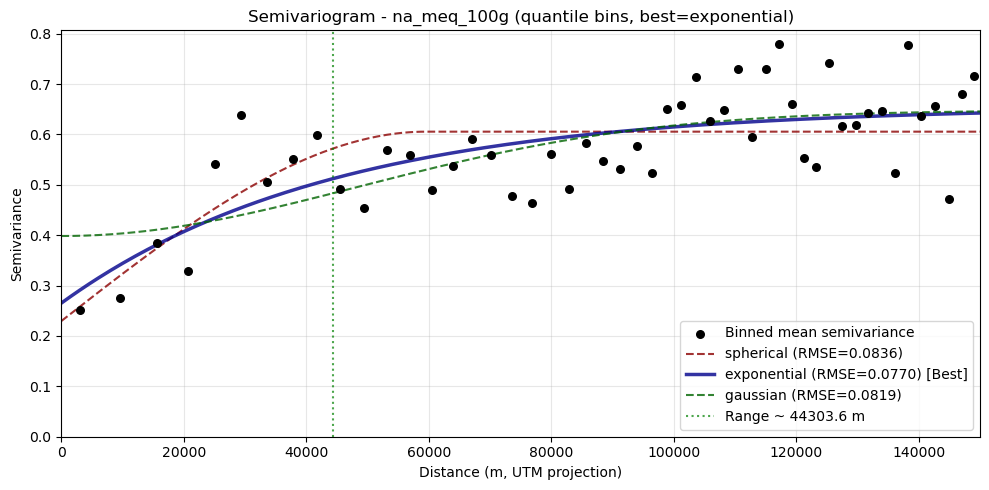

[na_meq_100g] n=1072 | CRS=EPSG:32629 | model=exponential | nugget=0.2653, sill=0.6557, range=44303.6 m | fit_RMSE=0.0770, krig_RMSE=0.0728, R2=0.9937


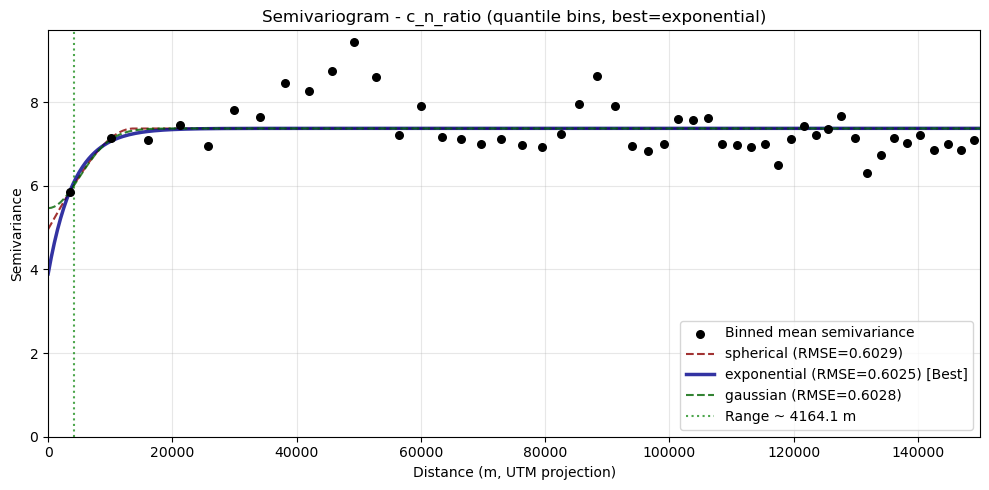

[c_n_ratio] n=1211 | CRS=EPSG:32629 | model=exponential | nugget=3.8932, sill=7.3715, range=4164.1 m | fit_RMSE=0.6025, krig_RMSE=0.4418, R2=0.9763


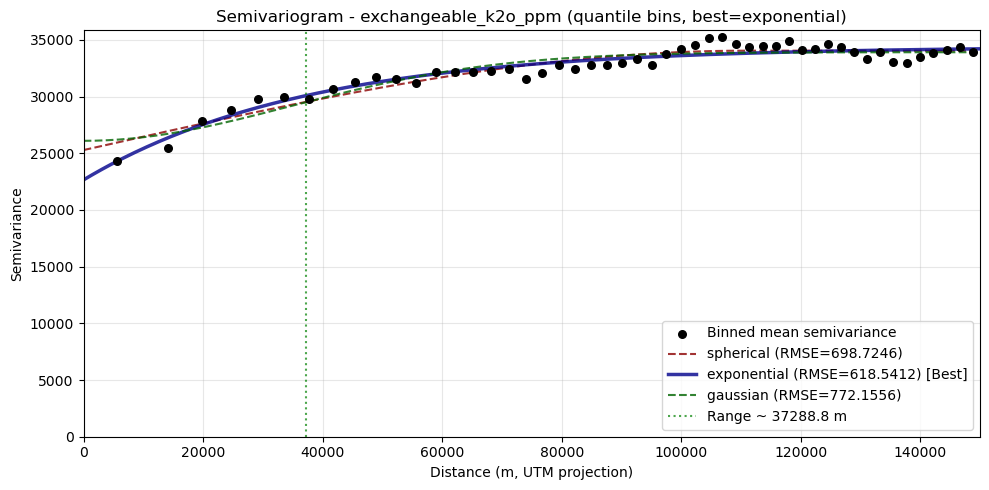

[exchangeable_k2o_ppm] n=4191 | CRS=EPSG:32629 | model=exponential | nugget=22653.6792, sill=34415.3645, range=37288.8 m | fit_RMSE=618.5412, krig_RMSE=22.8014, R2=0.9856


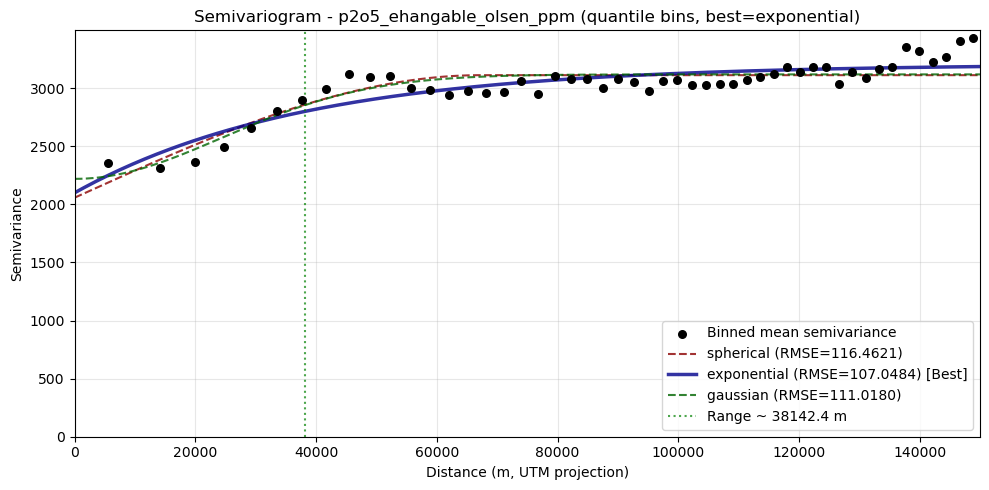

[p2o5_ehangable_olsen_ppm] n=4205 | CRS=EPSG:32629 | model=exponential | nugget=2099.5579, sill=3206.6465, range=38142.4 m | fit_RMSE=107.0484, krig_RMSE=7.2727, R2=0.9850


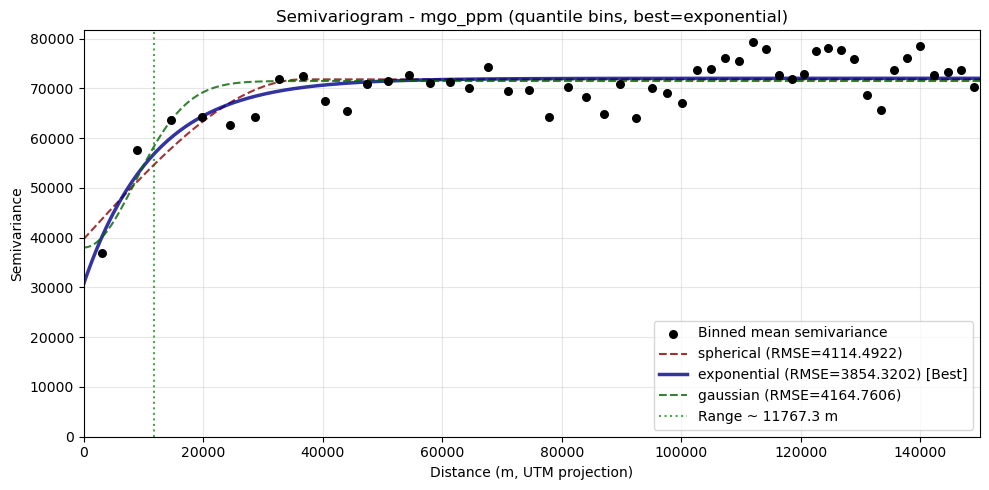

[mgo_ppm] n=1043 | CRS=EPSG:32629 | model=exponential | nugget=30691.3445, sill=72028.2709, range=11767.3 m | fit_RMSE=3854.3202, krig_RMSE=27.3996, R2=0.9897


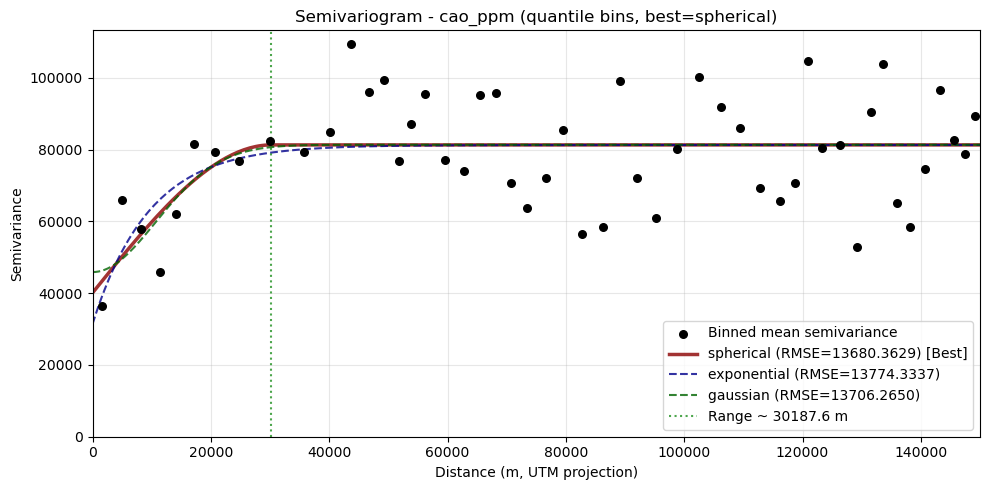

[cao_ppm] n=165 | CRS=EPSG:32629 | model=spherical | nugget=40095.3083, sill=81333.5637, range=30187.6 m | fit_RMSE=13680.3629, krig_RMSE=55.5182, R2=0.9584


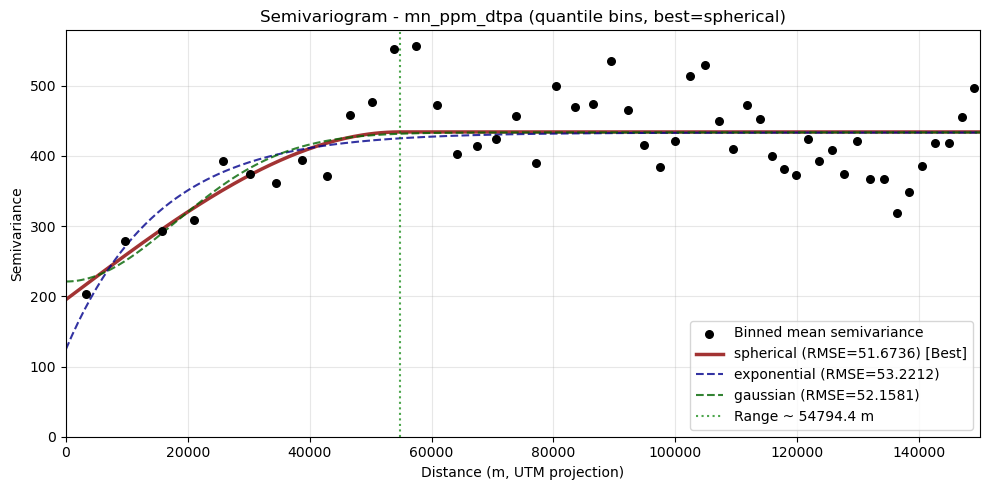

[mn_ppm_dtpa] n=1502 | CRS=EPSG:32629 | model=spherical | nugget=195.2658, sill=434.0581, range=54794.4 m | fit_RMSE=51.6736, krig_RMSE=1.4578, R2=0.9954


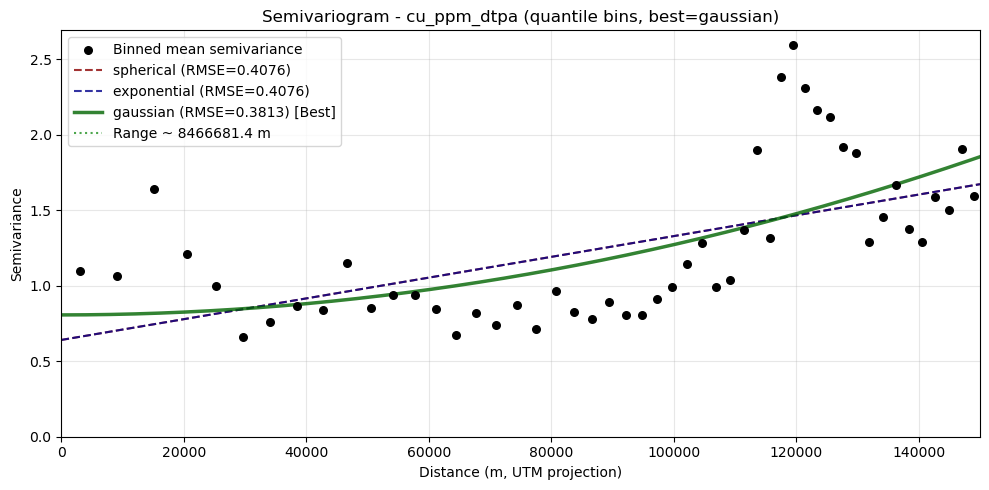

[cu_ppm_dtpa] n=1363 | CRS=EPSG:32629 | model=gaussian | nugget=0.8065, sill=3337.3035, range=8466681.4 m | fit_RMSE=0.3813, krig_RMSE=0.3021, R2=0.9527


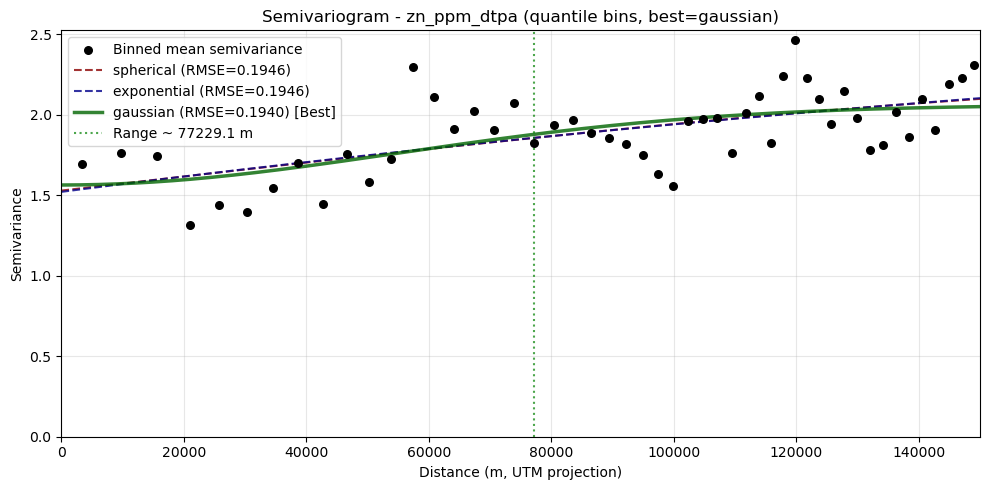

[zn_ppm_dtpa] n=1502 | CRS=EPSG:32629 | model=gaussian | nugget=1.5640, sill=2.0624, range=77229.1 m | fit_RMSE=0.1940, krig_RMSE=0.1381, R2=0.9911


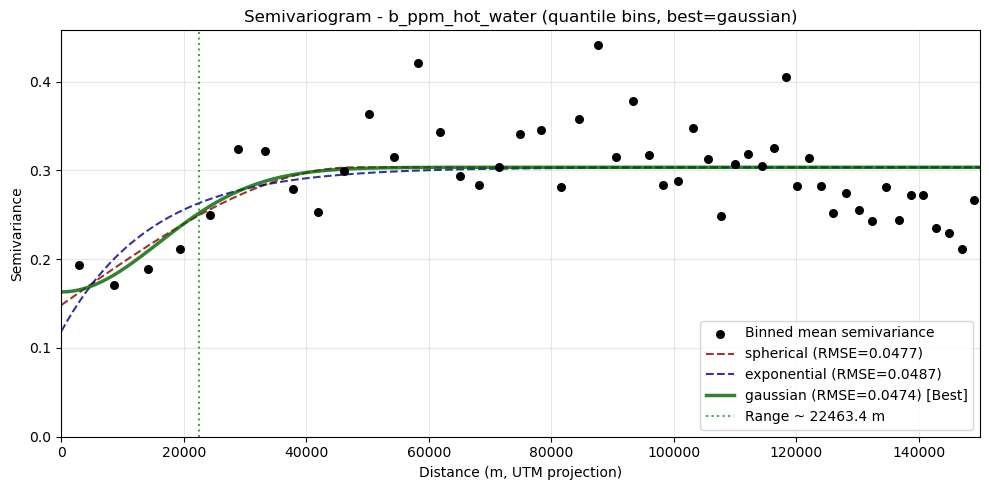

[b_ppm_hot_water] n=1184 | CRS=EPSG:32629 | model=gaussian | nugget=0.1631, sill=0.3035, range=22463.4 m | fit_RMSE=0.0474, krig_RMSE=0.1051, R2=0.9713


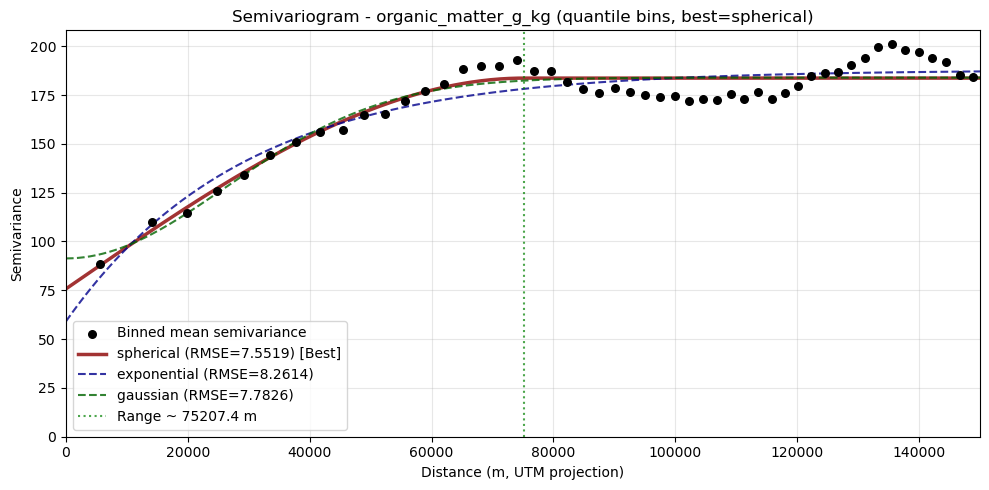

[organic_matter_g_kg] n=4206 | CRS=EPSG:32629 | model=spherical | nugget=75.7193, sill=183.6629, range=75207.4 m | fit_RMSE=7.5519, krig_RMSE=1.0146, R2=0.9939

Kriging summary across targets:


,target,n_samples,utm_crs,selected_model,nugget,sill,range_m,weighted_rmse,variogram_binning,min_pairs_per_bin,n_variogram_bins,pair_count_used,in_sample_rmse,in_sample_r2
8,ph_water,4206,EPSG:32629,exponential,0.311196,1.120620,4.570582e+04,0.068900,quantile,5,50,2640410,0.045152,0.997650
9,iron_ppm_dtpa,1502,EPSG:32629,spherical,23.196650,89.148804,6.881619e+04,9.448026,quantile,5,50,304710,0.496451,0.997285
20,mn_ppm_dtpa,1502,EPSG:32629,spherical,195.265834,434.058067,5.479443e+04,51.673593,quantile,5,50,304710,1.457758,0.995437
24,organic_matter_g_kg,4206,EPSG:32629,spherical,75.719269,183.662897,7.520745e+04,7.551942,quantile,5,50,2640410,1.014619,0.993877
14,na_meq_100g,1072,EPSG:32629,exponential,0.265319,0.655745,4.430357e+04,0.077014,quantile,5,50,156219,0.072836,0.993660
2,coarse_silt_pct,1226,EPSG:32629,exponential,9.233206,20.839483,6.001036e+04,1.191250,quantile,5,50,194620,0.365815,0.993396
12,na2o_ppm,1261,EPSG:32629,spherical,17386.637875,43276.956244,3.160404e+04,3177.623918,quantile,5,50,213787,18.512987,0.992001
22,zn_ppm_dtpa,1502,EPSG:32629,gaussian,1.564049,2.062446,7.722911e+04,0.194008,quantile,5,50,304710,0.138121,0.991125
18,mgo_ppm,1043,EPSG:32629,exponential,30691.344525,72028.270859,1.176728e+04,3854.320248,quantile,5,50,159657,27.399628,0.989748
7,caco3_pct_total,1482,EPSG:32629,exponential,100.248491,193.357117,3.205523e+04,9.194809,quantile,5,50,294778,1.412710,0.989410


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic
from sklearn.metrics import mean_squared_error, r2_score
from pyproj import CRS, Transformer

try:
    from pykrige.ok import OrdinaryKriging
except ImportError as exc:
    raise ImportError(
        "pykrige is required for Ordinary Kriging. Install it with: pip install pykrige"
    ) from exc

# -----------------------------------------------------------------------------
# Ordinary Kriging for every target in target_cols using df_ok_pre2017
# NOTE: lat/lon are geographic coordinates (degrees), so we project to metric
# UTM coordinates before semivariogram fitting and kriging.
# -----------------------------------------------------------------------------

if 'df_ok_pre2017' not in globals():
    raise NameError("df_ok_pre2017 not found. Please run the cell that creates it first.")
if 'target_cols' not in globals():
    raise NameError("target_cols not found. Please run the cell that defines it first.")

required_cols = {'lat', 'lon'}
missing_required = required_cols - set(df_ok_pre2017.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")


def utm_crs_from_lon_lat(lon, lat):
    zone = int((lon + 180.0) // 6.0) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)



def project_to_utm(latitudes, longitudes, forced_crs=None):
    latitudes = np.asarray(latitudes, dtype=float)
    longitudes = np.asarray(longitudes, dtype=float)
    center_lat = float(np.nanmedian(latitudes))
    center_lon = float(np.nanmedian(longitudes))
    utm_crs = forced_crs if forced_crs is not None else utm_crs_from_lon_lat(center_lon, center_lat)
    transformer = Transformer.from_crs('EPSG:4326', utm_crs, always_xy=True)
    x_m, y_m = transformer.transform(longitudes, latitudes)
    return np.column_stack([x_m, y_m]), utm_crs



def spherical_variogram(h, nugget, sill, rng):
    h = np.asarray(h, dtype=float)
    hr = h / np.maximum(rng, 1e-9)
    return np.where(
        h <= rng,
        nugget + (sill - nugget) * (1.5 * hr - 0.5 * hr**3),
        sill
    )



def exponential_variogram(h, nugget, sill, rng):
    h = np.asarray(h, dtype=float)
    return nugget + (sill - nugget) * (1.0 - np.exp(-h / np.maximum(rng, 1e-9)))



def gaussian_variogram(h, nugget, sill, rng):
    h = np.asarray(h, dtype=float)
    return nugget + (sill - nugget) * (1.0 - np.exp(-(h ** 2) / np.maximum(rng, 1e-9) ** 2))



def build_empirical_variogram(coords_m, values, n_bins=30, max_distance_m=200000, binning='quantile', min_pairs_per_bin=5):
    pair_dist = pdist(coords_m, metric='euclidean')
    pair_semivar = 0.5 * (pdist(values.reshape(-1, 1), metric='euclidean') ** 2)

    if len(pair_dist) == 0:
        raise ValueError('Not enough points to compute pairwise distances.')

    keep = pair_dist <= max_distance_m
    pair_dist = pair_dist[keep]
    pair_semivar = pair_semivar[keep]

    if len(pair_dist) == 0:
        raise ValueError(f'No point pairs found within {max_distance_m} m.')

    if binning == 'quantile':
        quantile_edges = np.quantile(pair_dist, np.linspace(0.0, 1.0, n_bins + 1))
        bin_edges = np.unique(quantile_edges)
        if len(bin_edges) < 4:
            bin_edges = np.linspace(0.0, max_distance_m, n_bins + 1)
        else:
            if bin_edges[0] > 0.0:
                bin_edges = np.insert(bin_edges, 0, 0.0)
            if bin_edges[-1] < max_distance_m:
                bin_edges = np.append(bin_edges, max_distance_m)
    else:
        bin_edges = np.linspace(0.0, max_distance_m, n_bins + 1)

    bin_means, bin_edges, _ = binned_statistic(
        pair_dist, pair_semivar, statistic='mean', bins=bin_edges
    )
    bin_counts, _, _ = binned_statistic(
        pair_dist, pair_semivar, statistic='count', bins=bin_edges
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    valid = np.isfinite(bin_means) & (bin_counts >= min_pairs_per_bin)
    if valid.sum() < 4:
        raise ValueError(f'Not enough bins with at least {min_pairs_per_bin} pairs.')

    return {
        'pair_dist': pair_dist,
        'pair_semivar': pair_semivar,
        'bin_centers': bin_centers[valid],
        'bin_means': bin_means[valid],
        'bin_counts': bin_counts[valid],
        'max_distance_m': max_distance_m,
        'binning': binning,
        'n_bins_requested': n_bins,
        'min_pairs_per_bin': int(min_pairs_per_bin)
    }



def fit_variogram_model(bin_centers, bin_means, bin_counts, model_name='spherical'):
    if len(bin_centers) < 4:
        raise ValueError('Not enough valid bins to fit variogram.')

    nugget0 = max(0.0, float(np.nanmin(bin_means)))
    sill0 = float(np.nanmax(bin_means))
    range0 = float(max(np.nanmax(bin_centers) / 3.0, 1.0))
    weights = np.sqrt(np.asarray(bin_counts, dtype=float))
    sigma = 1.0 / np.maximum(weights, 1e-6)

    lower = [0.0, 0.0, 1e-6]
    upper = [np.inf, np.inf, np.inf]

    if model_name == 'spherical':
        model_fn = spherical_variogram
    elif model_name == 'exponential':
        model_fn = exponential_variogram
    elif model_name == 'gaussian':
        model_fn = gaussian_variogram
    else:
        raise ValueError(f'Unsupported model_name: {model_name}')

    popt, _ = curve_fit(
        model_fn,
        bin_centers,
        bin_means,
        p0=[nugget0, max(sill0, nugget0 + 1e-6), range0],
        bounds=(lower, upper),
        sigma=sigma,
        absolute_sigma=False,
        maxfev=20000
    )

    nugget, sill, rng = map(float, popt)
    fitted = model_fn(bin_centers, nugget, sill, rng)
    weighted_rmse = float(np.sqrt(np.average((bin_means - fitted) ** 2, weights=np.maximum(weights, 1e-6))))
    return model_fn, {'nugget': nugget, 'sill': sill, 'range': rng, 'weighted_rmse': weighted_rmse}


variogram_models_to_try = ['spherical', 'exponential', 'gaussian']
summary_rows = []
plot_max_distance_m = 150000
variogram_n_bins = 50
variogram_binning = 'quantile'
variogram_min_pairs_per_bin = 5

for target in target_cols:
    if target not in df_ok_pre2017.columns:
        print(f"Skipping {target}: not in df_ok_pre2017")
        continue

    work = df_ok_pre2017[['lat', 'lon', target]].copy()
    work[target] = pd.to_numeric(work[target], errors='coerce')
    work = work.dropna(subset=['lat', 'lon', target]).copy()

    if len(work) < 20:
        print(f"Skipping {target}: insufficient valid samples ({len(work)})")
        continue

    values = work[target].to_numpy(dtype=float)
    coords_m, utm_crs = project_to_utm(work['lat'].to_numpy(), work['lon'].to_numpy())

    try:
        emp = build_empirical_variogram(
            coords_m,
            values,
            n_bins=variogram_n_bins,
            max_distance_m=plot_max_distance_m,
            binning=variogram_binning,
            min_pairs_per_bin=variogram_min_pairs_per_bin
        )
    except Exception as err:
        print(f"Skipping {target}: empirical variogram failed -> {err}")
        continue

    # Fit and compare spherical, exponential, and gaussian models using bin-count weights.
    model_fits = []
    fit_errors = {}
    for model_name in variogram_models_to_try:
        try:
            model_fn, params = fit_variogram_model(
                emp['bin_centers'],
                emp['bin_means'],
                emp['bin_counts'],
                model_name=model_name
            )
            model_fits.append((model_name, model_fn, params))
            fit_errors[model_name] = params['weighted_rmse']
        except Exception as err:
            print(f"[{target}] {model_name} fit failed: {err}")

    if not model_fits:
        print(f"Skipping {target}: all variogram fits failed")
        continue

    selected_model_name, model_fn, params = min(model_fits, key=lambda item: item[2]['weighted_rmse'])

    h_plot = np.linspace(0.0, plot_max_distance_m, 300)
    
    # Define colors for each model
    colors = {'spherical': 'darkred', 'exponential': 'darkblue', 'gaussian': 'darkgreen'}
    
    plt.figure(figsize=(10, 5))
    plt.scatter(
        emp['bin_centers'],
        emp['bin_means'],
        # s=np.clip(emp['bin_counts'] * 4, 20, 140),
        color='black',
        s=30,
        label='Binned mean semivariance',
        zorder=5
    )
    
    # Plot all three fitted models
    for model_name, model_fn_temp, params_temp in model_fits:
        gamma_plot_temp = model_fn_temp(h_plot, params_temp['nugget'], params_temp['sill'], params_temp['range'])
        color = colors.get(model_name, 'gray')
        linestyle = '-' if model_name == selected_model_name else '--'
        linewidth = 2.5 if model_name == selected_model_name else 1.5
        label = f'{model_name} (RMSE={params_temp["weighted_rmse"]:.4f})'
        if model_name == selected_model_name:
            label += ' [Best]'
        plt.plot(h_plot, gamma_plot_temp, color=color, linewidth=linewidth, linestyle=linestyle, label=label, alpha=0.8)
    
    plt.axvline(
        params['range'],
        color='green',
        linestyle=':',
        linewidth=1.5,
        label=f"Range ~ {params['range']:.1f} m",
        alpha=0.7
    )
    plt.xlim(0, plot_max_distance_m)
    plt.ylim(bottom=0)
    plt.title(f"Semivariogram - {target} ({variogram_binning} bins, best={selected_model_name})")
    plt.xlabel('Distance (m, UTM projection)')
    plt.ylabel('Semivariance')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    try:
        ok = OrdinaryKriging(
            coords_m[:, 0],
            coords_m[:, 1],
            values,
            variogram_model=selected_model_name,
            variogram_parameters={
                'sill': params['sill'],
                'range': params['range'],
                'nugget': params['nugget']
            },
            verbose=False,
            enable_plotting=False,
            coordinates_type='euclidean'
        )

        pred, var = ok.execute('points', coords_m[:, 0], coords_m[:, 1])
        pred = np.asarray(pred, dtype=float)

        rmse = float(np.sqrt(mean_squared_error(values, pred)))
        r2 = float(r2_score(values, pred))
    except Exception as err:
        print(f"Kriging failed for {target}: {err}")
        continue

    summary_rows.append({
        'target': target,
        'n_samples': int(len(work)),
        'utm_crs': utm_crs.to_string(),
        'selected_model': selected_model_name,
        'nugget': params['nugget'],
        'sill': params['sill'],
        'range_m': params['range'],
        'weighted_rmse': params['weighted_rmse'],
        'variogram_binning': variogram_binning,
        'min_pairs_per_bin': variogram_min_pairs_per_bin,
        'n_variogram_bins': int(len(emp['bin_centers'])),
        'pair_count_used': int(len(emp['pair_dist'])),
        'in_sample_rmse': rmse,
        'in_sample_r2': r2
    })

    print(
        f"[{target}] n={len(work)} | CRS={utm_crs.to_string()} | model={selected_model_name} | "
        f"nugget={params['nugget']:.4f}, sill={params['sill']:.4f}, range={params['range']:.1f} m | "
        f"fit_RMSE={params['weighted_rmse']:.4f}, krig_RMSE={rmse:.4f}, R2={r2:.4f}"
    )

kriging_summary_df = pd.DataFrame(summary_rows).sort_values('in_sample_r2', ascending=False)
print("\nKriging summary across targets:")
display(kriging_summary_df)

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pyproj import CRS, Transformer

try:
    from pykrige.ok import OrdinaryKriging
except ImportError as exc:
    raise ImportError("pykrige is required for kriging priors. Install it with: pip install pykrige") from exc


class SoilFusionDatasetKriging(Dataset):
    def __init__(
        self,
        static_df,
        ts_df,
        target_col='organic_matter_pct',
        seq_len=103,
        variogram_model='spherical',
        use_kriging_prior=True,
        prior_subsample_frac=0.30,
        prior_subsample_size=None,
        prior_random_state=42,
    ):
        self.seq_len = seq_len
        self.use_kriging_prior = use_kriging_prior

        static_df = static_df.replace([np.inf, -np.inf], np.nan).copy()
        ts_df = ts_df.replace([np.inf, -np.inf], np.nan).copy()

        static_df = static_df.drop_duplicates(subset=['uuid'])
        common_uuids_set = set(static_df['uuid']).intersection(set(ts_df['uuid']))
        common_uuids = [uid for uid in static_df['uuid'] if uid in common_uuids_set]

        static_df = static_df[static_df['uuid'].isin(common_uuids)].set_index('uuid').loc[common_uuids]
        ts_df = ts_df[ts_df['uuid'].isin(common_uuids)].copy()

        self.cat_col = 'SU_WRB1_PH'
        self.static_num_feats = [
            'caco3_pct_total', 'caco3_active_pct', 'ph_water', 'iron_ppm_dtpa',
            'Elevation', 'Slope', 'TWI', 'Aridity_Index',
            'B11_q10', 'B11_q25', 'B11_q50', 'B11_q75', 'B11_q90',
            'B12_q10', 'B12_q25', 'B12_q50', 'B12_q75', 'B12_q90',
            'B2_q10', 'B2_q25', 'B2_q50', 'B2_q75', 'B2_q90',
            'B3_q10', 'B3_q25', 'B3_q50', 'B3_q75', 'B3_q90',
            'B4_q10', 'B4_q25', 'B4_q50', 'B4_q75', 'B4_q90',
            'B5_q10', 'B5_q25', 'B5_q50', 'B5_q75', 'B5_q90',
            'B6_q10', 'B6_q25', 'B6_q50', 'B6_q75', 'B6_q90',
            'B7_q10', 'B7_q25', 'B7_q50', 'B7_q75', 'B7_q90',
            'B8_q10', 'B8_q25', 'B8_q50', 'B8_q75', 'B8_q90',
            'B8A_q10', 'B8A_q25', 'B8A_q50', 'B8A_q75', 'B8A_q90',
            'B11_iqr', 'B12_iqr', 'B2_iqr', 'B3_iqr', 'B4_iqr',
            'B5_iqr', 'B6_iqr', 'B7_iqr', 'B8_iqr', 'B8A_iqr'
        ]
        self.ts_feats = ['GPP_monthly', 'VH', 'VV', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'NDVI', 'SOCI', 'NBR2', 'VH/VV']

        static_df[target_col] = pd.to_numeric(static_df[target_col], errors='coerce')

        def _utm_crs_from_lon_lat(lon, lat):
            zone = int((lon + 180.0) // 6.0) + 1
            epsg = 32600 + zone if lat >= 0 else 32700 + zone
            return CRS.from_epsg(epsg)

        def _project_to_utm(latitudes, longitudes, forced_crs=None):
            latitudes = np.asarray(latitudes, dtype=float)
            longitudes = np.asarray(longitudes, dtype=float)
            center_lat = float(np.nanmedian(latitudes))
            center_lon = float(np.nanmedian(longitudes))
            utm_crs = forced_crs if forced_crs is not None else _utm_crs_from_lon_lat(center_lon, center_lat)
            transformer = Transformer.from_crs('EPSG:4326', utm_crs, always_xy=True)
            x_m, y_m = transformer.transform(longitudes, latitudes)
            return np.column_stack([x_m, y_m]), utm_crs

        # Workflow requested:
        # 1) build kriged product from a spatial random subsample
        # 2) inject kriging prior into full dataset
        # 3) then split train/val/test later in pipeline
        global_median = float(static_df[target_col].median())
        kriging_prior = np.full(len(static_df), global_median, dtype=float)
        self.kriging_semivariogram = None

        def _spatial_random_subsample(points_df, frac, random_state):
            points_df = points_df.copy()
            if len(points_df) <= 3:
                return points_df

            target_n = int(max(3, min(len(points_df), round(len(points_df) * float(frac)))))
            if target_n >= len(points_df):
                return points_df

            try:
                lat_bins = pd.qcut(points_df['lat'], q=min(10, points_df['lat'].nunique()), duplicates='drop')
                lon_bins = pd.qcut(points_df['lon'], q=min(10, points_df['lon'].nunique()), duplicates='drop')
                points_df['_cell'] = lat_bins.astype(str) + '|' + lon_bins.astype(str)
            except Exception:
                return points_df.sample(n=target_n, random_state=random_state)

            cell_counts = points_df['_cell'].value_counts().sort_index()
            alloc = np.floor(cell_counts.to_numpy(dtype=float) * float(frac)).astype(int)
            alloc = np.clip(alloc, 0, cell_counts.to_numpy(dtype=int))

            remainder = int(target_n - alloc.sum())
            capacity = cell_counts.to_numpy(dtype=int) - alloc
            if remainder > 0 and capacity.sum() > 0:
                order = np.argsort(-capacity)
                k = 0
                while remainder > 0 and np.any(capacity > 0):
                    idx = order[k % len(order)]
                    if capacity[idx] > 0:
                        alloc[idx] += 1
                        capacity[idx] -= 1
                        remainder -= 1
                    k += 1

            rng = np.random.default_rng(random_state)
            sampled_parts = []
            for i, cell in enumerate(cell_counts.index):
                n_take = int(alloc[i])
                if n_take <= 0:
                    continue
                group = points_df[points_df['_cell'] == cell]
                n_take = min(n_take, len(group))
                sampled_parts.append(group.sample(n=n_take, random_state=int(rng.integers(0, 2**31 - 1))))

            if not sampled_parts:
                return points_df.sample(n=target_n, random_state=random_state)

            sampled = pd.concat(sampled_parts, axis=0).drop(columns=['_cell'], errors='ignore')
            if len(sampled) > target_n:
                sampled = sampled.sample(n=target_n, random_state=random_state)
            elif len(sampled) < target_n:
                remaining = points_df.drop(index=sampled.index, errors='ignore').drop(columns=['_cell'], errors='ignore')
                if len(remaining) > 0:
                    sampled = pd.concat([sampled, remaining.sample(n=min(target_n - len(sampled), len(remaining)), random_state=random_state)], axis=0)
            return sampled

        if use_kriging_prior and {'lat', 'lon'}.issubset(static_df.columns):
            fit_pool = static_df[['lat', 'lon', target_col]].dropna(subset=['lat', 'lon', target_col]).copy()
            query_points = static_df[['lat', 'lon']].copy()
            valid_query_mask = query_points.notna().all(axis=1).to_numpy()

            if len(fit_pool) > 2 and valid_query_mask.sum() > 0:
                if prior_subsample_size is not None:
                    n_sub = int(max(3, min(prior_subsample_size, len(fit_pool))))
                else:
                    n_sub = int(max(3, np.floor(len(fit_pool) * float(prior_subsample_frac))))
                    n_sub = min(n_sub, len(fit_pool))

                fit_points = _spatial_random_subsample(fit_pool, frac=n_sub / len(fit_pool), random_state=prior_random_state)

                try:
                    fit_coords_m, utm_crs = _project_to_utm(
                        fit_points['lat'].to_numpy(),
                        fit_points['lon'].to_numpy(),
                    )
                    query_coords_m, _ = _project_to_utm(
                        query_points.loc[valid_query_mask, 'lat'].to_numpy(),
                        query_points.loc[valid_query_mask, 'lon'].to_numpy(),
                        forced_crs=utm_crs,
                    )

                    ok = OrdinaryKriging(
                        fit_coords_m[:, 0],
                        fit_coords_m[:, 1],
                        fit_points[target_col].to_numpy(dtype=float),
                        variogram_model=variogram_model,
                        verbose=False,
                        enable_plotting=False,
                        coordinates_type='euclidean',
                        exact_values=False,
                    )

                    if hasattr(ok, 'lags') and hasattr(ok, 'semivariance'):
                        self.kriging_semivariogram = {
                            'lags': np.asarray(ok.lags, dtype=float),
                            'semivariance': np.asarray(ok.semivariance, dtype=float),
                            'variogram_model': variogram_model,
                            'variogram_parameters': getattr(ok, 'variogram_model_parameters', None),
                        }

                    pred_prior, _ = ok.execute('points', query_coords_m[:, 0], query_coords_m[:, 1])
                    kriging_prior[valid_query_mask] = np.asarray(pred_prior, dtype=float)
                    print(f'Kriging prior built from spatial random subsample: {len(fit_points)}/{len(fit_pool)} points.')
                except Exception as err:
                    print(f'Kriging prior failed for {target_col}: {err}')

        self.kriging_prior_raw = kriging_prior.astype(float)

        static_scaler = StandardScaler()
        ts_scaler = StandardScaler()
        prior_scaler = StandardScaler()

        static_num_scaled = static_scaler.fit_transform(static_df[self.static_num_feats].fillna(0))
        ts_df[self.ts_feats] = ts_scaler.fit_transform(ts_df[self.ts_feats].fillna(0))
        prior_scaled = prior_scaler.fit_transform(self.kriging_prior_raw.reshape(-1, 1)).reshape(-1)

        soil_series = static_df[self.cat_col].fillna('UNK').astype(str)
        soil_categories = pd.Categorical(soil_series)
        soil_codes = soil_categories.codes.astype(np.int64)

        self.soil_classes = list(soil_categories.categories)
        self.num_soil_classes = len(self.soil_classes)
        self.static_num_dim = len(self.static_num_feats)
        self.ts_dim = len(self.ts_feats)
        one_hot = np.eye(self.num_soil_classes, dtype=np.float32)[soil_codes]

        self.data = []
        self.uuids = common_uuids
        grouped = ts_df.sort_values('observation_date').groupby('uuid')

        prior_text = 'with kriging prior' if use_kriging_prior else 'without prior'
        print(f'Pre-processing sequences {prior_text}... please wait a moment.')
        for i, uid in enumerate(common_uuids):
            s_num_val = torch.tensor(static_num_scaled[i], dtype=torch.float32)
            s_cat_val = torch.tensor(one_hot[i], dtype=torch.float32)
            prior_val = torch.tensor([prior_scaled[i]], dtype=torch.float32)

            group = grouped.get_group(uid)[self.ts_feats].values
            if len(group) > self.seq_len:
                group = group[-self.seq_len:]
            else:
                pad = np.zeros((self.seq_len - len(group), len(self.ts_feats)))
                group = np.vstack([pad, group])

            t_val = torch.tensor(group, dtype=torch.float32)
            y_val = torch.tensor(static_df.loc[uid, target_col], dtype=torch.float32).view(1)
            self.data.append((s_cat_val, s_num_val, prior_val, t_val, y_val))

        print(f'Finished pre-processing {len(self.data)} samples.')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


class MultimodalSoilNetKriging(nn.Module):
    def __init__(self, static_num_dim, ts_dim, num_soil_classes, hidden_dim=128, lstm_layers=1):
        super().__init__()
        ts_channels = max(32, min(64, ts_dim * 2))
        self.ts_cnn = nn.Sequential(
            nn.Conv1d(ts_dim, ts_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(ts_channels),
        )
        self.lstm = nn.LSTM(
            ts_channels,
            hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else 0.2,
        )
        self.residual_proj = nn.Linear(ts_channels, hidden_dim * 2)

        static_in_dim = static_num_dim + num_soil_classes
        self.static_branch = nn.Sequential(
            nn.Linear(static_in_dim, max(64, static_in_dim // 2)),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(max(64, static_in_dim // 2), max(32, static_in_dim // 4)),
            nn.ReLU(),
        )

        self.kriging_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim * 2),
            nn.ReLU(),
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2 + max(32, static_in_dim // 4), max(64, hidden_dim)),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(max(64, hidden_dim), max(32, hidden_dim // 2)),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(max(32, hidden_dim // 2), 1),
        )

    def forward(self, static_cat_oh, static_num_x, kriging_prior_x, ts_x):
        static_in = torch.cat((static_num_x, static_cat_oh), dim=1)

        ts_feat = self.ts_cnn(ts_x.transpose(1, 2)).transpose(1, 2)
        res_shortcut = self.residual_proj(ts_feat.mean(dim=1))
        _, (h_n, _) = self.lstm(ts_feat)
        ts_out = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        ts_out = ts_out + res_shortcut

        ts_fused_with_kriging = self.kriging_fusion(torch.cat((ts_out, kriging_prior_x), dim=1))

        static_out = self.static_branch(static_in)
        fused = torch.cat((ts_fused_with_kriging, static_out), dim=1)
        return self.regressor(fused)


def train_and_evaluate(dataset, train_idx, val_idx, test_idx, label, device):
    batch_size = 32 if dataset.static_num_dim >= 48 else 64
    train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=batch_size)
    test_loader = DataLoader(torch.utils.data.Subset(dataset, test_idx), batch_size=batch_size)

    model = MultimodalSoilNetKriging(
        static_num_dim=dataset.static_num_dim,
        ts_dim=dataset.ts_dim,
        num_soil_classes=dataset.num_soil_classes,
        hidden_dim=128,
        lstm_layers=1,
    ).to(device)

    criterion = nn.HuberLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience = 25
    trigger_times = 0

    for epoch in range(200):
        model.train()
        running_train_loss = 0.0
        for s_cat_oh, s_x, k_prior, t_x, y in train_loader:
            s_cat_oh = s_cat_oh.to(device)
            s_x, k_prior, t_x, y = s_x.to(device), k_prior.to(device), t_x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(s_cat_oh, s_x, k_prior, t_x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for s_cat_oh, s_x, k_prior, t_x, y in val_loader:
                s_cat_oh = s_cat_oh.to(device)
                s_x, k_prior, t_x, y = s_x.to(device), k_prior.to(device), t_x.to(device), y.to(device)
                pred = model(s_cat_oh, s_x, k_prior, t_x)
                running_val_loss += criterion(pred, y).item()
        avg_val_loss = running_val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'[{label}] Early stopping at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'[{label}] Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    model.load_state_dict(best_model_wts)

    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for s_cat_oh, s_x, k_prior, t_x, y in test_loader:
            s_cat_oh = s_cat_oh.to(device)
            s_x, k_prior, t_x = s_x.to(device), k_prior.to(device), t_x.to(device)
            preds = model(s_cat_oh, s_x, k_prior, t_x)
            y_true.extend(y.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)

    print(f'[{label}] RMSE={rmse:.4f}, R2={r2:.4f}, Bias={bias:.4f}')

    return {
        'model': model,
        'history': history,
        'y_true': y_true,
        'y_pred': y_pred,
        'rmse': rmse,
        'r2': r2,
        'bias': bias,
    }


def run_kriging_prior_comparison(df_static, df_ts):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'--- Training on device: {device} ---')

    target_col = 'organic_matter_g_kg' if 'organic_matter_g_kg' in df_static.columns else 'organic_matter_pct'
    base_static = df_static.dropna(subset=[target_col]).copy()

    prior_subsample_frac = 0.50
    prior_seed = 42

    ds_with_prior = SoilFusionDatasetKriging(
        base_static,
        df_ts,
        target_col=target_col,
        seq_len=103,
        use_kriging_prior=True,
        prior_subsample_frac=prior_subsample_frac,
        prior_random_state=prior_seed,
    )
    ds_without_prior = SoilFusionDatasetKriging(
        base_static,
        df_ts,
        target_col=target_col,
        seq_len=103,
        use_kriging_prior=False,
        prior_subsample_frac=prior_subsample_frac,
        prior_random_state=prior_seed,
    )

    # Split after prior injection, as requested
    all_idx = list(range(len(ds_with_prior)))
    train_val_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=42)

    res_with = train_and_evaluate(ds_with_prior, train_idx, val_idx, test_idx, 'With Kriging Prior', device)
    res_without = train_and_evaluate(ds_without_prior, train_idx, val_idx, test_idx, 'Without Prior', device)

    # Semivariogram used by kriging prior
    semivar = ds_with_prior.kriging_semivariogram
    if semivar is not None and len(semivar['lags']) > 0:
        plt.figure(figsize=(7, 5))
        plt.scatter(semivar['lags'], semivar['semivariance'], color='black', s=35, label='Empirical semivariogram')
        plt.xlabel('Lag distance (m)')
        plt.ylabel('Semivariance')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Kriging product alone on TEST set
    y_true_krig = np.array([ds_with_prior[i][4].item() for i in test_idx], dtype=float)
    y_pred_krig = ds_with_prior.kriging_prior_raw[np.array(test_idx, dtype=int)]
    krig_rmse = np.sqrt(mean_squared_error(y_true_krig, y_pred_krig))
    krig_r2 = r2_score(y_true_krig, y_pred_krig)
    krig_bias = float(np.mean(y_pred_krig - y_true_krig))

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true_krig, y_pred_krig, alpha=0.5, color='seagreen', label='Kriging-only predictions')
    axis_max_krig = max(np.max(y_true_krig), np.max(y_pred_krig))
    plt.plot([0, axis_max_krig], [0, axis_max_krig], 'r--', label='1:1')
    m_k, c_k = np.polyfit(y_true_krig, y_pred_krig, 1)
    plt.plot(y_true_krig, m_k * y_true_krig + c_k, color='darkorange', label=f'Fit: y={m_k:.2f}x+{c_k:.2f}')
    plt.title('Test Scatter: Kriging Product Alone')
    plt.xlabel('Observed')
    plt.ylabel('Kriging prior prediction')
    plt.grid(alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(res_with['history']['train_loss'], color='teal', label='Train (With Prior)')
    plt.plot(res_with['history']['val_loss'], color='teal', linestyle='--', label='Val (With Prior)')
    plt.plot(res_without['history']['train_loss'], color='darkorange', label='Train (Without Prior)')
    plt.plot(res_without['history']['val_loss'], color='darkorange', linestyle='--', label='Val (Without Prior)')
    plt.title('Training vs Validation Loss: With and Without Prior')
    plt.xlabel('Epoch')
    plt.ylabel('Huber Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_true = res_with['y_true']
    y_pred_with = res_with['y_pred']
    y_pred_without = res_without['y_pred']
    axis_max = max(np.max(y_true), np.max(y_pred_with), np.max(y_pred_without))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    m1, c1 = np.polyfit(y_true, y_pred_with, 1)
    axes[0].scatter(y_true, y_pred_with, alpha=0.5, color='teal', label='Predictions')
    axes[0].plot([0, axis_max], [0, axis_max], 'r--', label='1:1')
    axes[0].plot(y_true, m1 * y_true + c1, color='darkorange', label=f'Fit: y={m1:.2f}x+{c1:.2f}')
    axes[0].set_title('With Kriging Prior')
    axes[0].set_xlabel('Observed')
    axes[0].set_ylabel('Predicted')
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc='lower right')
    axes[0].text(
        0.05,
        0.95,
        f"RMSE: {res_with['rmse']:.3f}\nR²: {res_with['r2']:.3f}\nBias: {res_with['bias']:.3f}",
        transform=axes[0].transAxes,
        va='top',
        bbox=dict(facecolor='white', alpha=0.8),
    )

    m2, c2 = np.polyfit(y_true, y_pred_without, 1)
    axes[1].scatter(y_true, y_pred_without, alpha=0.5, color='slateblue', label='Predictions')
    axes[1].plot([0, axis_max], [0, axis_max], 'r--', label='1:1')
    axes[1].plot(y_true, m2 * y_true + c2, color='darkorange', label=f'Fit: y={m2:.2f}x+{c2:.2f}')
    axes[1].set_title('Without Prior')
    axes[1].set_xlabel('Observed')
    axes[1].set_ylabel('Predicted')
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='lower right')
    axes[1].text(
        0.05,
        0.95,
        f"RMSE: {res_without['rmse']:.3f}\nR²: {res_without['r2']:.3f}\nBias: {res_without['bias']:.3f}",
        transform=axes[1].transAxes,
        va='top',
        bbox=dict(facecolor='white', alpha=0.8),
    )

    plt.suptitle('Test Scatter Comparison: With Prior vs Without Prior')
    plt.tight_layout()
    plt.show()

    return {
        'with_prior': res_with,
        'without_prior': res_without,
    }


comparison_results = run_kriging_prior_comparison(df_static, df_ts)
trained_model_kriging = comparison_results['with_prior']['model']

--- Training on device: cuda ---
Kriging prior built from spatial random subsample: 2041/4083 points.
Pre-processing sequences with kriging prior... please wait a moment.
